In [1]:
from autogluon.tabular import TabularPredictor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl 
import gc

In [114]:
label_codes = {4: 'necroptosis inducer',
                        1: 'autophagy inducer',
                        2: 'ferroptosis inducer',
                        3: 'immunogenic cell death',
                        0: 'apoptosis',
                        5: 'pyroptosis inducer'}

# Load predictors

In [2]:
#models too large to save, but reproduce training using scripts in repo
predictor_CP = TabularPredictor.load("/home/jovyan/share/data/analyses/benjamin/Single_cell_supervised/Autogluon_celldeath_CP_revision") 
predictor_DINO = TabularPredictor.load("/home/jovyan/share/data/analyses/benjamin/Single_cell_supervised/Autogluon_celldeath_DINO_revision")
predictor_DP = TabularPredictor.load("/home/jovyan/share/data/analyses/benjamin/Single_cell_supervised/Autogluon_celldeath_DP_revision")
predictor_agg_DINO = TabularPredictor.load("/home/jovyan/share/data/analyses/benjamin/Single_cell_supervised/Autogluon_celldeath_DINO_aggregated_revision")
predictor_agg_DP = TabularPredictor.load("/home/jovyan/share/data/analyses/benjamin/Single_cell_supervised/Autogluon_celldeath_DP_aggregated")
predictor_agg_CP = TabularPredictor.load("/home/jovyan/share/data/analyses/benjamin/Single_cell_supervised/Autogluon_celldeath_CP_aggregated")

# Prep test data

## Load DP

In [74]:
test_set_DP = pl.read_parquet("classification_splits/celldeath_test_DP_singlecell.parquet")

In [139]:
test_set_DP_agg = pl.read_csv("classification_splits/celldeath_moa_test_DP_aggregated.csv")

In [ ]:
def norm_test_feats(df, extractor, mode = "standard"):
    df = df.to_pandas()
    if mode == "standard":
        df_train_DP = pl.read_csv(f"/home/jovyan/share/data/analyses/benjamin/DINO/CELLDEATH/datasets_paper/classification_splits/celldeath_moa_train_{extractor}.csv").to_pandas()
        X_train_DP = df_train_DP.drop(['label'], axis=1).values
        scaler_DP = StandardScaler()
        X_train_DP_scaled = scaler_DP.fit_transform(X_train_DP)
        X_test_DP = df.drop("label", axis=1).values
        X_test_scaled_DP = scaler_DP.transform(X_test_DP)
        test_data_DP = pd.DataFrame(X_test_scaled_DP, columns=[f'feature_{i}' for i in range(X_test_DP.shape[1])])
        test_data_DP_join = pd.concat([test_data_DP, df["label"]], axis=1)
        return test_data_DP_join

    elif mode == "majority":
        if extractor == "DP":
            dp_profiles = pl.read_parquet("/home/jovyan/share/data/analyses/benjamin/DINO/CELLDEATH/datasets_paper/sc_profiles_DP_adjusted.parquet").drop("label")
            feature_columns_df1 = [col for col in dp_profiles.columns if "Feature" in col]
            feature_columns_df2 = [col for col in test_set_DP.columns if "Feature" in col]
        elif extractor == "DINO":
            dp_profiles = pl.read_parquet("/home/jovyan/share/data/analyses/benjamin/DINO/CELLDEATH/datasets_paper/sc_profiles_DINO.parquet").drop("label")
            feature_columns_df1 = [col for col in dp_profiles.columns if "Feature" in col]
            feature_columns_df2 = [col for col in test_set_DP.columns if "Feature" in col]
        elif extractor == "CP":
            dp_profiles = pl.read_parquet("/home/jovyan/share/data/analyses/benjamin/DINO/CELLDEATH/datasets_paper/sc_profiles_CP_full.parquet").drop("label")
            feature_columns_df1 = [col for col in test_set_CP.columns if "label" not in col]
            feature_columns_df2 = [col for col in cp_profiles.columns if col in feature_columns_df1 and "label" not in col]

        # Convert columns to `f32` type in both dataframes
        dp_profiles = dp_profiles.with_columns([pl.col(col).cast(pl.Float32) for col in feature_columns_df1])
        df = df.with_columns([pl.col(col).cast(pl.Float32) for col in feature_columns_df2])

        # Step 3: Perform the inner join on all matching "Feature" columns
        test_set_DP_join = dp_profiles.join(df, on=feature_columns_df1, how="inner")
        test_set_DP_join = test_set_DP_join.to_pandas()
        df_train_DP = pl.read_csv(f"/home/jovyan/share/data/analyses/benjamin/DINO/CELLDEATH/datasets_paper/classification_splits/celldeath_moa_train_{extractor}_adjusted.csv").to_pandas()
        X_train_DP = df_train_DP.drop(["label"], axis=1).values
        scaler_DP = StandardScaler()
        X_train_DP_scaled = scaler_DP.fit_transform(X_train_DP)
        X_test_DP = test_set_DP_join.drop(meta_feats_DP, axis=1).values
        X_test_scaled_DP = scaler_DP.transform(X_test_DP)
        test_data_DP = pd.DataFrame(X_test_scaled_DP, columns=[f'feature_{i}' for i in range(X_test_DP.shape[1])])
        test_data_DP_join = pd.concat([test_data_DP, test_set_DP_join[meta_feats_DP]], axis=1)

        return test_data_DP_join

In [5]:
def norm_test_feats_revision(df, extractor, path, mode = "standard"):
    df = df.to_pandas()
    if mode == "standard":
        df_train_DP = pl.read_parquet(path).to_pandas()
        X_train_DP = df_train_DP.drop(['moa'], axis=1).values
        scaler_DP = StandardScaler()
        X_train_DP_scaled = scaler_DP.fit_transform(X_train_DP)
        X_test_DP = df.drop("moa", axis=1).values
        X_test_scaled_DP = scaler_DP.transform(X_test_DP)
        test_data_DP = pd.DataFrame(X_test_scaled_DP, columns=[f'feature_{i}' for i in range(X_test_DP.shape[1])])
        test_data_DP_join = pd.concat([test_data_DP, df["moa"]], axis=1)
        return test_data_DP_join

    elif mode == "majority":
        if extractor == "DP":
            dp_profiles = pl.read_parquet("/home/jovyan/share/data/analyses/benjamin/DINO/CELLDEATH/datasets_paper/sc_profiles_DP_adjusted.parquet").drop("moa")
            feature_columns_df1 = [col for col in dp_profiles.columns if "Feature" in col]
            feature_columns_df2 = [col for col in test_set_DP.columns if "Feature" in col]
        elif extractor == "DINO":
            dp_profiles = pl.read_parquet("/home/jovyan/share/data/analyses/benjamin/DINO/CELLDEATH/datasets_paper/sc_profiles_DINO.parquet").drop("moa")
            feature_columns_df1 = [col for col in dp_profiles.columns if "Feature" in col]
            feature_columns_df2 = [col for col in test_set_DP.columns if "Feature" in col]
        elif extractor == "CP":
            dp_profiles = pl.read_parquet("/home/jovyan/share/data/analyses/benjamin/DINO/CELLDEATH/datasets_paper/sc_profiles_CP_full.parquet").drop("moa")
            feature_columns_df1 = [col for col in test_set_CP.columns if "moa" not in col]
            feature_columns_df2 = [col for col in cp_profiles.columns if col in feature_columns_df1 and "moa" not in col]

        # Convert columns to `f32` type in both dataframes
        dp_profiles = dp_profiles.with_columns([pl.col(col).cast(pl.Float32) for col in feature_columns_df1])
        df = df.with_columns([pl.col(col).cast(pl.Float32) for col in feature_columns_df2])

        # Step 3: Perform the inner join on all matching "Feature" columns
        test_set_DP_join = dp_profiles.join(df, on=feature_columns_df1, how="inner")
        test_set_DP_join = test_set_DP_join.to_pandas()
        df_train_DP = pl.read_csv(f"/home/jovyan/share/data/analyses/benjamin/DINO/CELLDEATH/datasets_paper/classification_splits/celldeath_moa_train_{extractor}_adjusted.csv").to_pandas()
        X_train_DP = df_train_DP.drop(["moa"], axis=1).values
        scaler_DP = StandardScaler()
        X_train_DP_scaled = scaler_DP.fit_transform(X_train_DP)
        X_test_DP = test_set_DP_join.drop(meta_feats_DP, axis=1).values
        X_test_scaled_DP = scaler_DP.transform(X_test_DP)
        test_data_DP = pd.DataFrame(X_test_scaled_DP, columns=[f'feature_{i}' for i in range(X_test_DP.shape[1])])
        test_data_DP_join = pd.concat([test_data_DP, test_set_DP_join[meta_feats_DP]], axis=1)

        return test_data_DP_join

In [9]:
test_data_DP = norm_test_feats(test_set_DP, "DINO")

In [11]:
meta_feats_DP = [feat for feat in test_data_DP.columns if "Feature" not in feat]

In [11]:
df_train_DP = pl.read_csv("/home/jovyan/share/data/analyses/benjamin/DINO/CELLDEATH/datasets_paper/classification_splits/celldeath_moa_train_DP_adjusted.csv").to_pandas()
X_train_DP = df_train_DP.drop(["label"], axis=1).values
scaler_DP = StandardScaler()
X_train_DP_scaled = scaler_DP.fit_transform(X_train_DP)
X_test_DP = test_set_DP_join.drop(meta_feats_DP, axis=1).values
X_test_scaled_DP = scaler_DP.transform(X_test_DP)
test_data_DP = pd.DataFrame(X_test_scaled_DP, columns=[f'feature_{i}' for i in range(X_test_DP.shape[1])])
test_data_DP_join = pd.concat([test_data_DP, test_set_DP_join[meta_feats_DP]], axis=1)

## Load DINO

In [64]:
test_set_DINO = pl.read_parquet("classification_splits/celldeath_test_DINO_singlecell.parquet")


In [131]:
test_set_DINO_agg = pl.read_parquet("classification_splits/celldeath_test_DINO_aggregated.parquet")

In [ ]:
meta_feats_DINO = [feat for feat in test_set_DINO.columns if "feature" not in feat]

## Load CP

In [78]:
test_set_CP = pl.read_parquet("classification_splits/celldeath_test_CP_singlecell.parquet")
cp_profiles = pl.read_parquet("features/single_cell_features_CellProfiler.parquet").drop("label")

In [134]:
test_set_CP_agg = pl.read_csv("classification_splits/celldeath_moa_test_CP_aggregated.csv")

In [36]:
feature_columns_df1 = [col for col in test_set_CP.columns if "moa" not in col]
feature_columns_df2 = [col for col in cp_profiles.columns if col in feature_columns_df1 and "moa" not in col]

In [130]:
# Convert columns to `f32` type in both dataframes
cp_profiles = cp_profiles.with_columns([pl.col(col).cast(pl.Float32) for col in feature_columns_df2])
test_set_CP = test_set_CP.with_columns([pl.col(col).cast(pl.Float32) for col in feature_columns_df1])

# Step 3: Perform the inner join on all matching "Feature" columns
test_set_CP_join = cp_profiles.join(test_set_CP, on=feature_columns_df1, how="inner")

In [38]:
test_set_CP_join = test_set_CP_join.to_pandas()
meta_feats_CP = [feat for feat in test_set_CP_join.columns if feat not in feature_columns_df1]

In [41]:
df_train_CP = pl.read_parquet("/home/jovyan/share/data/analyses/benjamin/DINO/CELLDEATH/scripts/paper_code/data_revision/classification_splits/celldeath_train_CP_singlecell.parquet").to_pandas()
X_train_CP = df_train_CP.drop(['moa'], axis=1).values
scaler_CP = StandardScaler()
X_train_CP_scaled = scaler_CP.fit_transform(X_train_CP)

In [42]:
X_test_CP = test_set_CP_join.drop(meta_feats_CP, axis=1).values
X_test_scaled_CP = scaler_CP.transform(X_test_CP)
test_data_CP = pd.DataFrame(X_test_scaled_CP, columns=[f'feature_{i}' for i in range(X_test_CP.shape[1])])
test_data_CP_join = pd.concat([test_data_CP, test_set_CP_join[meta_feats_CP]], axis=1)

## Leaderboard test set

In [9]:
predictor_agg_DINO.leaderboard(test_set_DINO_agg.to_pandas(), silent = True, extra_metrics = ["accuracy", "f1_macro", "f1_micro", "recall_macro", "precision_macro"])

/home/jovyan/share/data/analyses/benjamin/Single_cell_supervised/autogluon_analysis/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,model,score_test,accuracy,f1_macro,f1_micro,recall_macro,precision_macro,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT_BAG_L2_FULL,0.869151,0.869151,0.885076,0.869151,0.885378,0.887070,NaN,accuracy,14.416568,NaN,1962.806564,0.392574,NaN,12.515748,2,True,131
1,NeuralNetTorch_r14_BAG_L2_FULL,0.868284,0.868284,0.889342,0.868284,0.880248,0.899419,NaN,accuracy,14.291610,NaN,1955.768130,0.267616,NaN,5.477314,2,True,166
2,LightGBM_r188_BAG_L2_FULL,0.865685,0.865685,0.881701,0.865685,0.881819,0.883924,NaN,accuracy,14.147512,NaN,1989.062608,0.123518,NaN,38.771792,2,True,154
3,NeuralNetFastAI_r143_BAG_L2_FULL,0.864818,0.864818,0.878894,0.864818,0.878924,0.881247,NaN,accuracy,14.147596,NaN,1953.925590,0.123602,NaN,3.634774,2,True,168
4,NeuralNetFastAI_r145_BAG_L2_FULL,0.864818,0.864818,0.876798,0.864818,0.874702,0.887396,NaN,accuracy,14.418354,NaN,1958.719620,0.394360,NaN,8.428804,2,True,155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,XGBoost_r33_BAG_L1,NaN,NaN,NaN,NaN,NaN,NaN,0.893981,accuracy,NaN,2.139331,667.702350,NaN,2.139331,667.702350,1,False,19
168,LightGBM_r161_BAG_L1,NaN,NaN,NaN,NaN,NaN,NaN,0.891898,accuracy,NaN,2.786495,465.607888,NaN,2.786495,465.607888,1,False,38
169,LightGBMLarge_BAG_L1,NaN,NaN,NaN,NaN,NaN,NaN,0.889120,accuracy,NaN,1.881238,405.327104,NaN,1.881238,405.327104,1,False,11
170,CatBoost_r70_BAG_L1,NaN,NaN,NaN,NaN,NaN,NaN,0.855556,accuracy,NaN,0.146554,75.321313,NaN,0.146554,75.321313,1,False,40


In [10]:
predictor_DINO.leaderboard(test_set_DINO.to_pandas(), silent = True, extra_metrics = ["accuracy", "f1_macro", "f1_micro", "recall_macro", "precision_macro"])

,model,score_test,accuracy,f1_macro,f1_micro,recall_macro,precision_macro,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3_FULL,0.802434,0.802434,0.803536,0.802434,0.802885,0.805215,NaN,accuracy,249.884251,NaN,14508.809416,0.014922,NaN,9.425372,3,True,58
1,NeuralNetTorch_r22_BAG_L2_FULL,0.802184,0.802184,0.799145,0.802184,0.794173,0.805944,NaN,accuracy,227.294595,NaN,12689.114676,3.762613,NaN,567.081647,2,True,54
2,NeuralNetFastAI_BAG_L2_FULL,0.800105,0.800105,0.800352,0.800105,0.798666,0.804275,NaN,accuracy,229.788146,NaN,12361.552148,6.256164,NaN,239.519118,2,True,37
3,LightGBMXT_BAG_L2_FULL,0.798603,0.798603,0.800141,0.798603,0.799272,0.803221,NaN,accuracy,224.032283,NaN,12261.533918,0.500301,NaN,139.500888,2,True,38
4,ExtraTreesEntr_BAG_L2_FULL,0.798553,0.798553,0.802097,0.798553,0.796730,0.810418,NaN,accuracy,225.720403,NaN,12162.820098,2.188421,24.937213,40.787069,2,True,44
5,XGBoost_BAG_L2_FULL,0.798527,0.798527,0.800527,0.798527,0.800017,0.803519,NaN,accuracy,224.226139,NaN,12142.946241,0.694157,NaN,20.913211,2,True,45
6,ExtraTreesGini_BAG_L2_FULL,0.798452,0.798452,0.802373,0.798452,0.796949,0.810665,NaN,accuracy,225.604806,NaN,12158.168099,2.072824,21.929992,36.135069,2,True,43
7,LightGBM_BAG_L2_FULL,0.798327,0.798327,0.800567,0.798327,0.799489,0.804487,NaN,accuracy,223.933964,NaN,12200.071082,0.401982,NaN,78.038053,2,True,39
8,LightGBM_r131_BAG_L2_FULL,0.798052,0.798052,0.800455,0.798052,0.796796,0.807158,NaN,accuracy,224.155361,NaN,12293.960428,0.623379,NaN,171.927398,2,True,50
9,WeightedEnsemble_L2_FULL,0.797826,0.797826,0.799981,0.797826,0.796637,0.806948,NaN,accuracy,223.500772,NaN,12077.702346,0.010272,NaN,2.543612,2,True,36


In [11]:
predictor_CP.leaderboard(test_set_CP.to_pandas(), silent = True, extra_metrics = ["accuracy", "f1_macro", "f1_micro", "recall_macro", "precision_macro"])

,model,score_test,accuracy,f1_macro,f1_micro,recall_macro,precision_macro,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2_FULL,0.777436,0.777436,0.779910,0.777436,0.781897,0.784355,NaN,accuracy,34.605857,NaN,11787.982337,0.006175,NaN,2.419434,2,True,20
1,RandomForestGini_BAG_L2_FULL,0.771705,0.771705,0.774465,0.771705,0.776669,0.778250,NaN,accuracy,49.281931,NaN,14000.679556,1.028783,21.064330,205.061316,2,True,24
2,LightGBMXT_BAG_L1_FULL,0.771630,0.771630,0.773500,0.771630,0.777498,0.775794,NaN,accuracy,23.315143,NaN,8949.568864,23.315143,NaN,8949.568864,1,True,15
3,LightGBM_BAG_L2_FULL,0.767800,0.767800,0.769759,0.767800,0.778908,0.765442,NaN,accuracy,49.056779,NaN,14259.495822,0.803632,NaN,463.877582,2,True,23
4,LightGBMXT_BAG_L2_FULL,0.764697,0.764697,0.768364,0.764697,0.773753,0.766639,NaN,accuracy,50.150901,NaN,15465.728511,1.897754,NaN,1670.110271,2,True,22
5,WeightedEnsemble_L3_FULL,0.764697,0.764697,0.768364,0.764697,0.773753,0.766639,NaN,accuracy,50.154531,NaN,15470.002886,0.003630,NaN,4.274375,3,True,26
6,NeuralNetFastAI_BAG_L2_FULL,0.763020,0.763020,0.764356,0.763020,0.770299,0.765354,NaN,accuracy,60.071841,NaN,15041.127435,11.818693,NaN,1245.509195,2,True,21
7,LightGBM_BAG_L1_FULL,0.749756,0.749756,0.749300,0.749756,0.755125,0.749752,NaN,accuracy,1.578810,NaN,1579.878225,1.578810,NaN,1579.878225,1,True,16
8,CatBoost_BAG_L2_FULL,0.744375,0.744375,0.746027,0.744375,0.744345,0.752794,NaN,accuracy,48.382245,NaN,13812.276939,0.129098,NaN,16.658699,2,True,25
9,NeuralNetFastAI_BAG_L1_FULL,0.733814,0.733814,0.734412,0.733814,0.735697,0.737363,NaN,accuracy,11.284539,NaN,2835.994039,11.284539,NaN,2835.994039,1,True,14


In [15]:
predictor_DP.leaderboard(test_set_DP.to_pandas(), silent = True, extra_metrics = ["accuracy", "f1_macro", "f1_micro", "recall_macro", "precision_macro"])

,model,score_test,accuracy,f1_macro,f1_micro,recall_macro,precision_macro,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetTorch_BAG_L2_FULL,0.668643,0.668643,0.663466,0.668643,0.642220,0.702858,NaN,accuracy,114.508242,NaN,5625.410987,5.663321,NaN,117.617736,2,True,44
1,WeightedEnsemble_L3_FULL,0.667427,0.667427,0.662822,0.667427,0.643938,0.696360,NaN,accuracy,142.668290,NaN,6788.987119,0.110827,NaN,12.258476,3,True,52
2,NeuralNetFastAI_BAG_L2_FULL,0.667080,0.667080,0.662935,0.667080,0.644721,0.701602,NaN,accuracy,116.080950,NaN,5611.202883,7.236028,NaN,103.409632,2,True,35
3,LightGBMLarge_BAG_L2_FULL,0.666807,0.666807,0.662475,0.666807,0.644334,0.693477,NaN,accuracy,109.538004,NaN,5645.232313,0.693083,NaN,137.439063,2,True,45
4,LightGBM_BAG_L2_FULL,0.666485,0.666485,0.661321,0.666485,0.643814,0.691630,NaN,accuracy,109.327998,NaN,5566.567838,0.483077,NaN,58.774587,2,True,37
5,LightGBM_r131_BAG_L2_FULL,0.665740,0.665740,0.661012,0.665740,0.642717,0.692860,NaN,accuracy,109.773332,NaN,5671.210553,0.928411,NaN,163.417302,2,True,48
6,XGBoost_BAG_L2_FULL,0.665517,0.665517,0.661240,0.665517,0.645558,0.687531,NaN,accuracy,110.057673,NaN,5575.389350,1.212752,NaN,67.596099,2,True,43
7,LightGBMXT_BAG_L2_FULL,0.665443,0.665443,0.661249,0.665443,0.643982,0.691608,NaN,accuracy,109.459466,NaN,5606.104463,0.614545,NaN,98.311213,2,True,36
8,NeuralNetFastAI_r191_BAG_L2_FULL,0.665219,0.665219,0.663300,0.665219,0.646075,0.700492,NaN,accuracy,117.421948,NaN,5611.680748,8.577027,NaN,103.887497,2,True,49
9,CatBoost_r177_BAG_L2_FULL,0.665071,0.665071,0.659873,0.665071,0.644016,0.688159,NaN,accuracy,108.909735,NaN,5561.932224,0.064814,NaN,54.138973,2,True,46


In [7]:
def evaluate_models_and_display_summary(test_data, label_column, predictor, top_n=10, model_name = None):
    """
    Evaluates all models on the test set and displays the top 5 models' metrics.

    Parameters:
    - test_data: The test DataFrame.
    - label_column: The name of the label column in test_data.
    - predictor: The trained AutoGluon TabularPredictor object.
    - top_n: Number of top models to display (default is 5).
    """
    y_test = test_data[label_column]
    X_test = test_data.drop(labels=[label_column], axis=1)
    
    # Getting the leaderboard
    
    # Evaluate all models and collect their predictions
    if model_name != None:
        model_names = model_name
    else:
        leaderboard = predictor.leaderboard(test_data, silent=True)
        model_names = leaderboard['model'][:top_n].to_list()
        
    performances = []
    all_reports = []
    #string_labels = [label_codes[label] for label in np.unique(y_test)]
    string_labels = np.unique(y_test)
    for model in model_names:
        y_pred = predictor.predict(X_test, model=model)
        report = classification_report(y_test, y_pred, output_dict=True)
        report_df = pd.DataFrame(report).transpose()
        report_df['model'] = model  # Add a column for the model
        all_reports.append(report_df)
        accuracy = accuracy_score(y_test, y_pred)
        performances.append((model, report, accuracy))

        print(f"Model: {model}, Accuracy: {accuracy:.4f}")
        display(pd.DataFrame(report).transpose())
        
        # Optional: Plot confusion matrix for each model
        cm = confusion_matrix(y_test, y_pred, labels=predictor.class_labels)
        cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Convert to percentage
        
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=string_labels)
        fig, ax = plt.subplots(figsize=(10,7), dpi = 300)
        disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2f')
        plt.title(f'{model}')
        plt.xlabel('Predicted label', fontweight = "bold")
        plt.ylabel('True label', fontweight = "bold")
        #plt.savefig(f"/home/jovyan/share/data/analyses/benjamin/Single_cell_supervised/Autogluon_celldeath_DINO_aggregated/output/Celldeath_confusion_{model}_DINO.png")
        #plt.show()
    all_reports_df = pd.concat(all_reports, axis=0).reset_index().rename(columns={'index': 'metric'})
    #output_path = f'/home/jovyan/share/data/analyses/benjamin/Single_cell_supervised/Autogluon_celldeath_DINO_aggregated/output/classification_report_celldeath_DINO.csv'
    #all_reports_df.to_csv(output_path, index=False)
    return all_reports_df

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Your label mapping
label_codes = {
    4: 'necroptosis inducer',
    1: 'autophagy inducer',
    2: 'ferroptosis inducer',
    3: 'immunogenic cell death',
    0: 'apoptosis',
    5: 'pyroptosis inducer'
}
# Invert the label_codes dictionary: string -> integer
string_to_int = {v: k for k, v in label_codes.items()}

def evaluate_models_and_display_summary(test_data, label_column, predictor, top_n=10, model_name=None):
    """
    Evaluates all models on the test set and displays the top models' metrics.

    Parameters:
    - test_data: The test DataFrame.
    - label_column: The name of the label column in test_data.
    - predictor: The trained AutoGluon TabularPredictor object.
    - top_n: Number of top models to display (default is 10).
    - model_name: Specific list of models to evaluate (optional).
    
    Returns:
    - all_reports_df: DataFrame containing classification reports for all evaluated models.
    """
    y_test = test_data[label_column]
    X_test = test_data.drop(labels=[label_column], axis=1)

    # Map string labels back to integers
    y_test_mapped = y_test.map(string_to_int)

    # Get sorted integer labels
    int_labels = np.sort(y_test_mapped.unique())

    # Select models to evaluate
    if model_name is not None:
        model_names = model_name
    else:
        leaderboard = predictor.leaderboard(test_data, silent=True)
        model_names = leaderboard['model'][:top_n].to_list()

    all_reports = []

    for model in model_names:
        y_pred = predictor.predict(X_test, model=model)
        y_pred_mapped = pd.Series(y_pred).map(string_to_int)

        # Classification report
        report = classification_report(y_test_mapped, y_pred_mapped, output_dict=True)
        report_df = pd.DataFrame(report).transpose()
        report_df['model'] = model
        all_reports.append(report_df)

        # Accuracy
        accuracy = accuracy_score(y_test_mapped, y_pred_mapped)
        print(f"Model: {model}, Accuracy: {accuracy:.4f}")
        display(pd.DataFrame(report).transpose())

        # Confusion matrix
        cm = confusion_matrix(y_test_mapped, y_pred_mapped, labels=int_labels)
        cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

        disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=int_labels)
        fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
        disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2f')
        plt.title(f'{model}')
        plt.xlabel('Predicted label', fontweight="bold")
        plt.ylabel('True label', fontweight="bold")
        plt.show()

    # Combine all reports into a single DataFrame
    all_reports_df = pd.concat(all_reports, axis=0).reset_index().rename(columns={'index': 'metric'})
    return all_reports_df


Model: LightGBMXT_BAG_L2_FULL, Accuracy: 0.8692


,precision,recall,f1-score,support
0,0.844282,0.856790,0.850490,405.000000
1,0.885714,0.961240,0.921933,129.000000
2,0.848276,0.931818,0.888087,132.000000
3,0.760204,0.719807,0.739454,207.000000
4,0.990196,0.901786,0.943925,112.000000
5,0.993750,0.940828,0.966565,169.000000
accuracy,0.869151,0.869151,0.869151,0.869151
macro avg,0.887070,0.885378,0.885076,1154.000000
weighted avg,0.870340,0.869151,0.868927,1154.000000


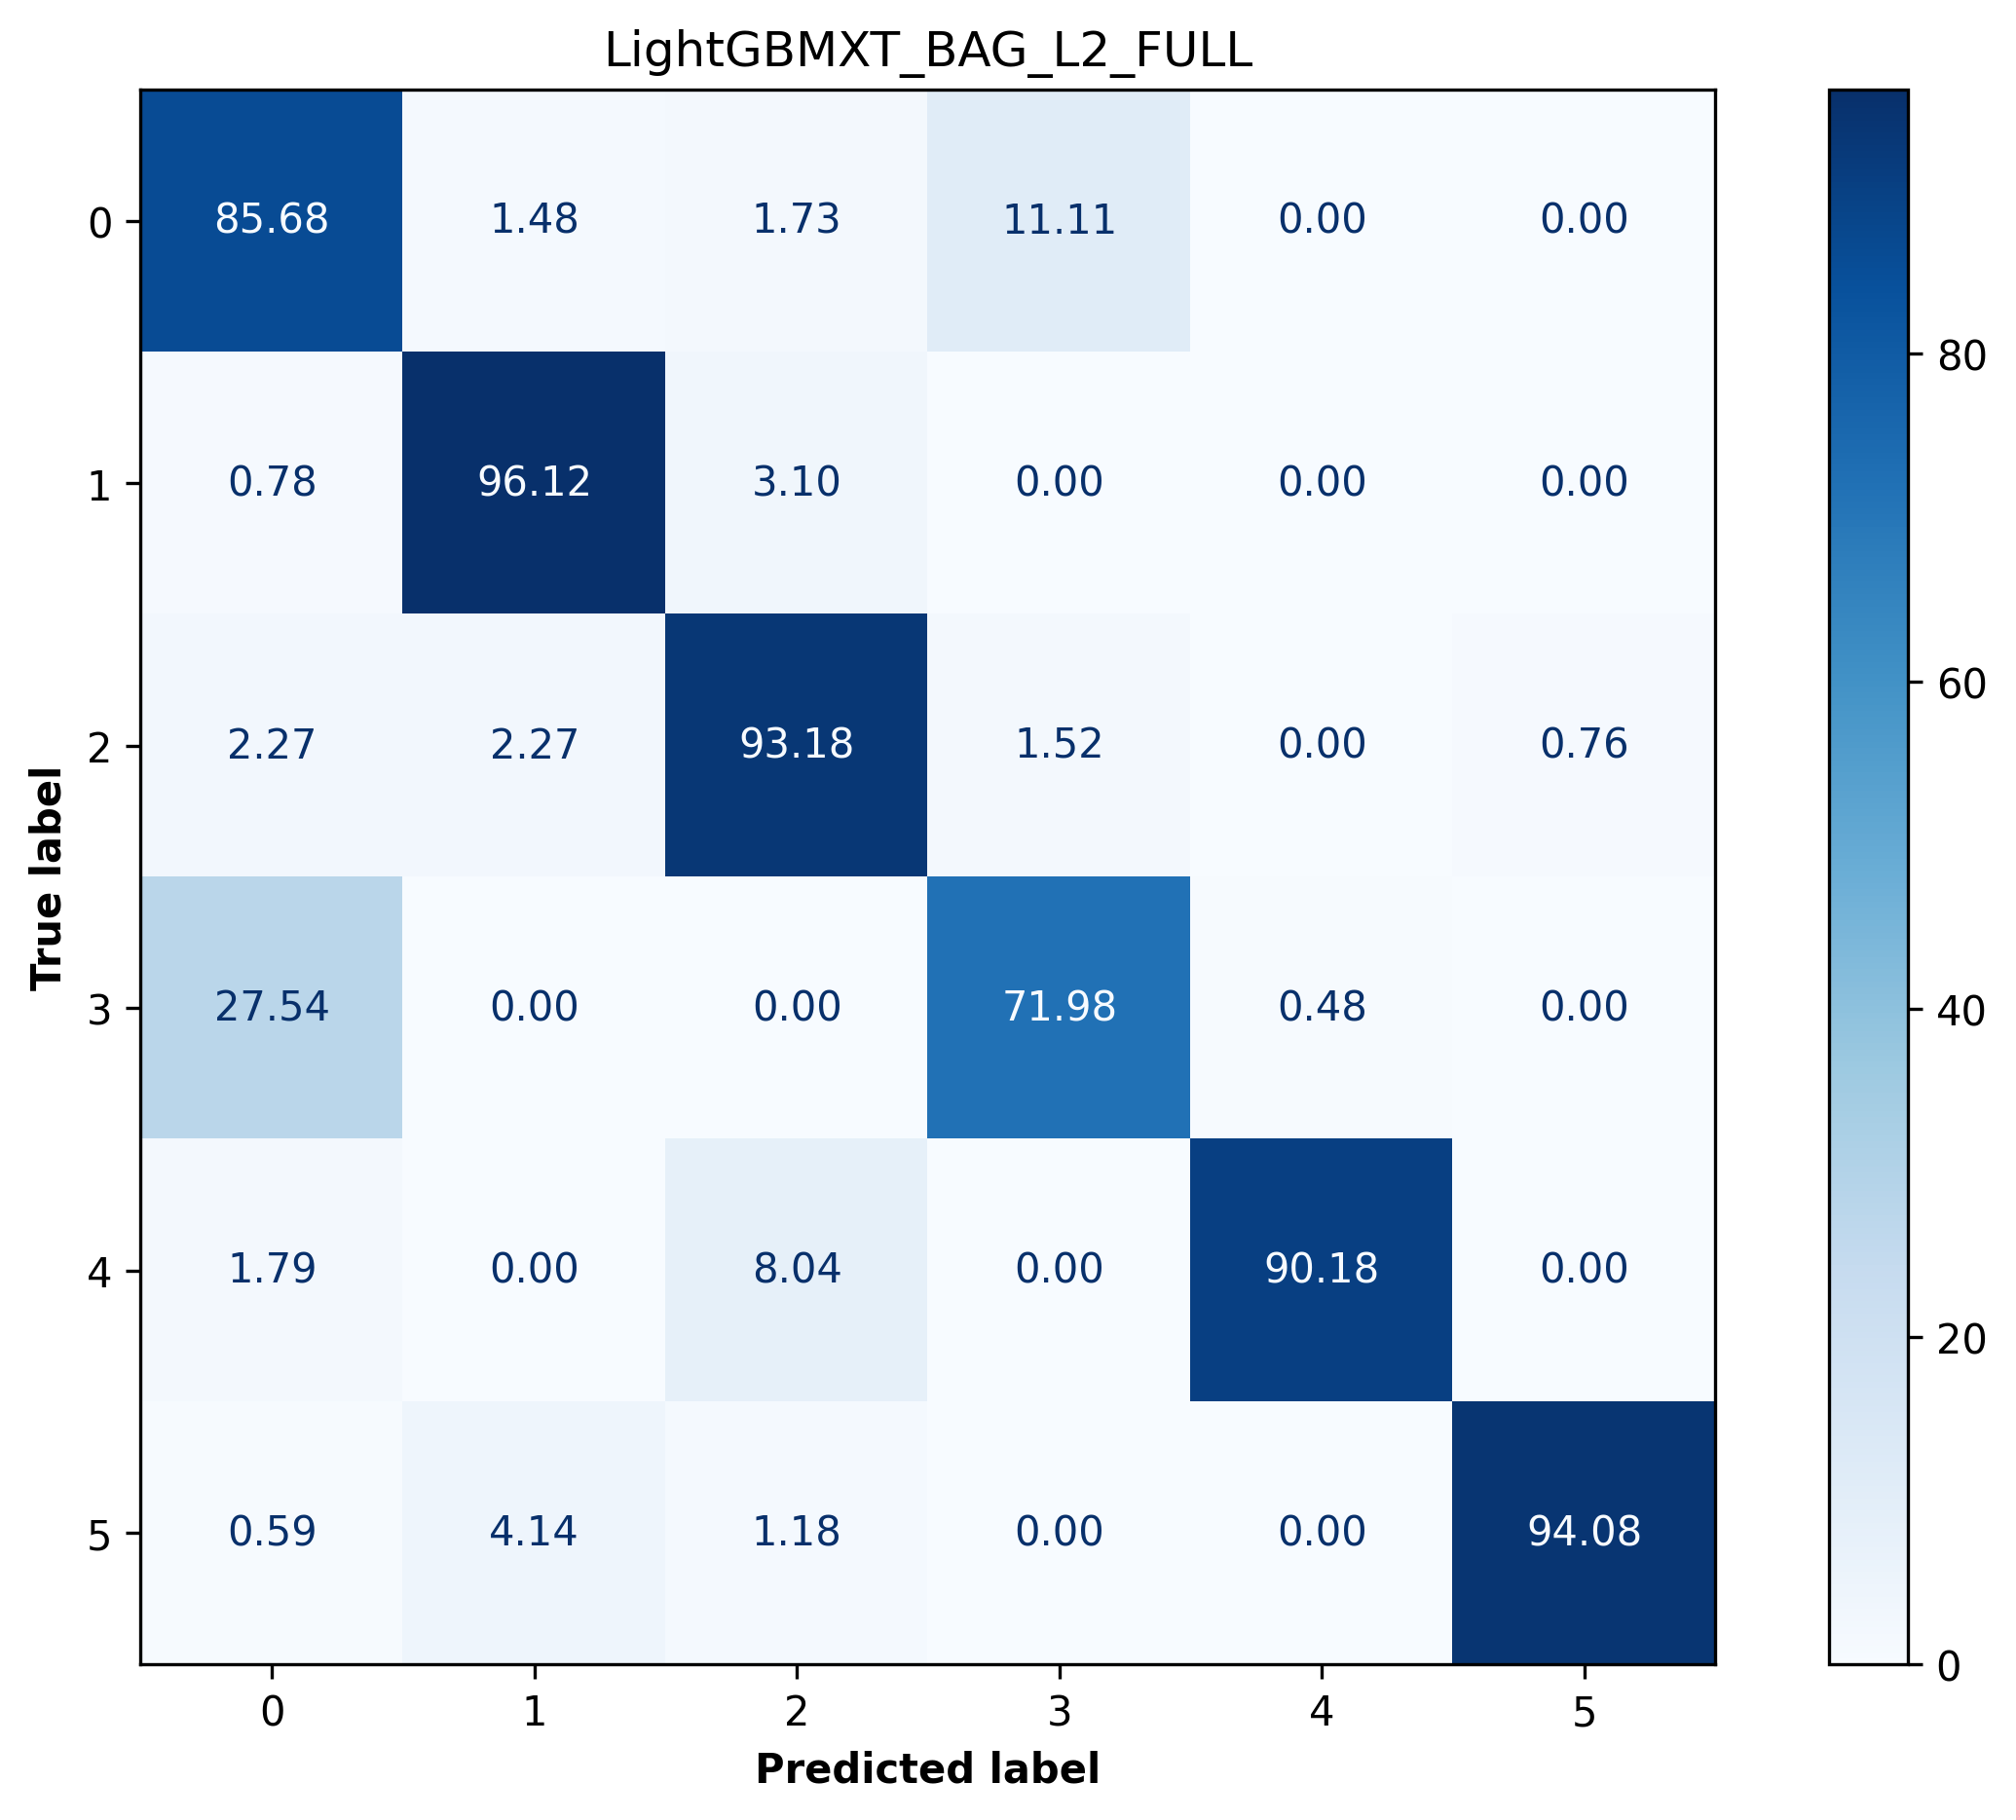

Model: NeuralNetFastAI_r191_BAG_L1_FULL, Accuracy: 0.7964


,precision,recall,f1-score,support
0,0.805634,0.706173,0.752632,405.00000
1,0.837838,0.961240,0.895307,129.00000
2,0.733813,0.772727,0.752768,132.00000
3,0.611321,0.782609,0.686441,207.00000
4,0.988506,0.767857,0.864322,112.00000
5,0.993750,0.940828,0.966565,169.00000
accuracy,0.796360,0.796360,0.796360,0.79636
macro avg,0.828477,0.821906,0.819672,1154.00000
weighted avg,0.811461,0.796360,0.798893,1154.00000


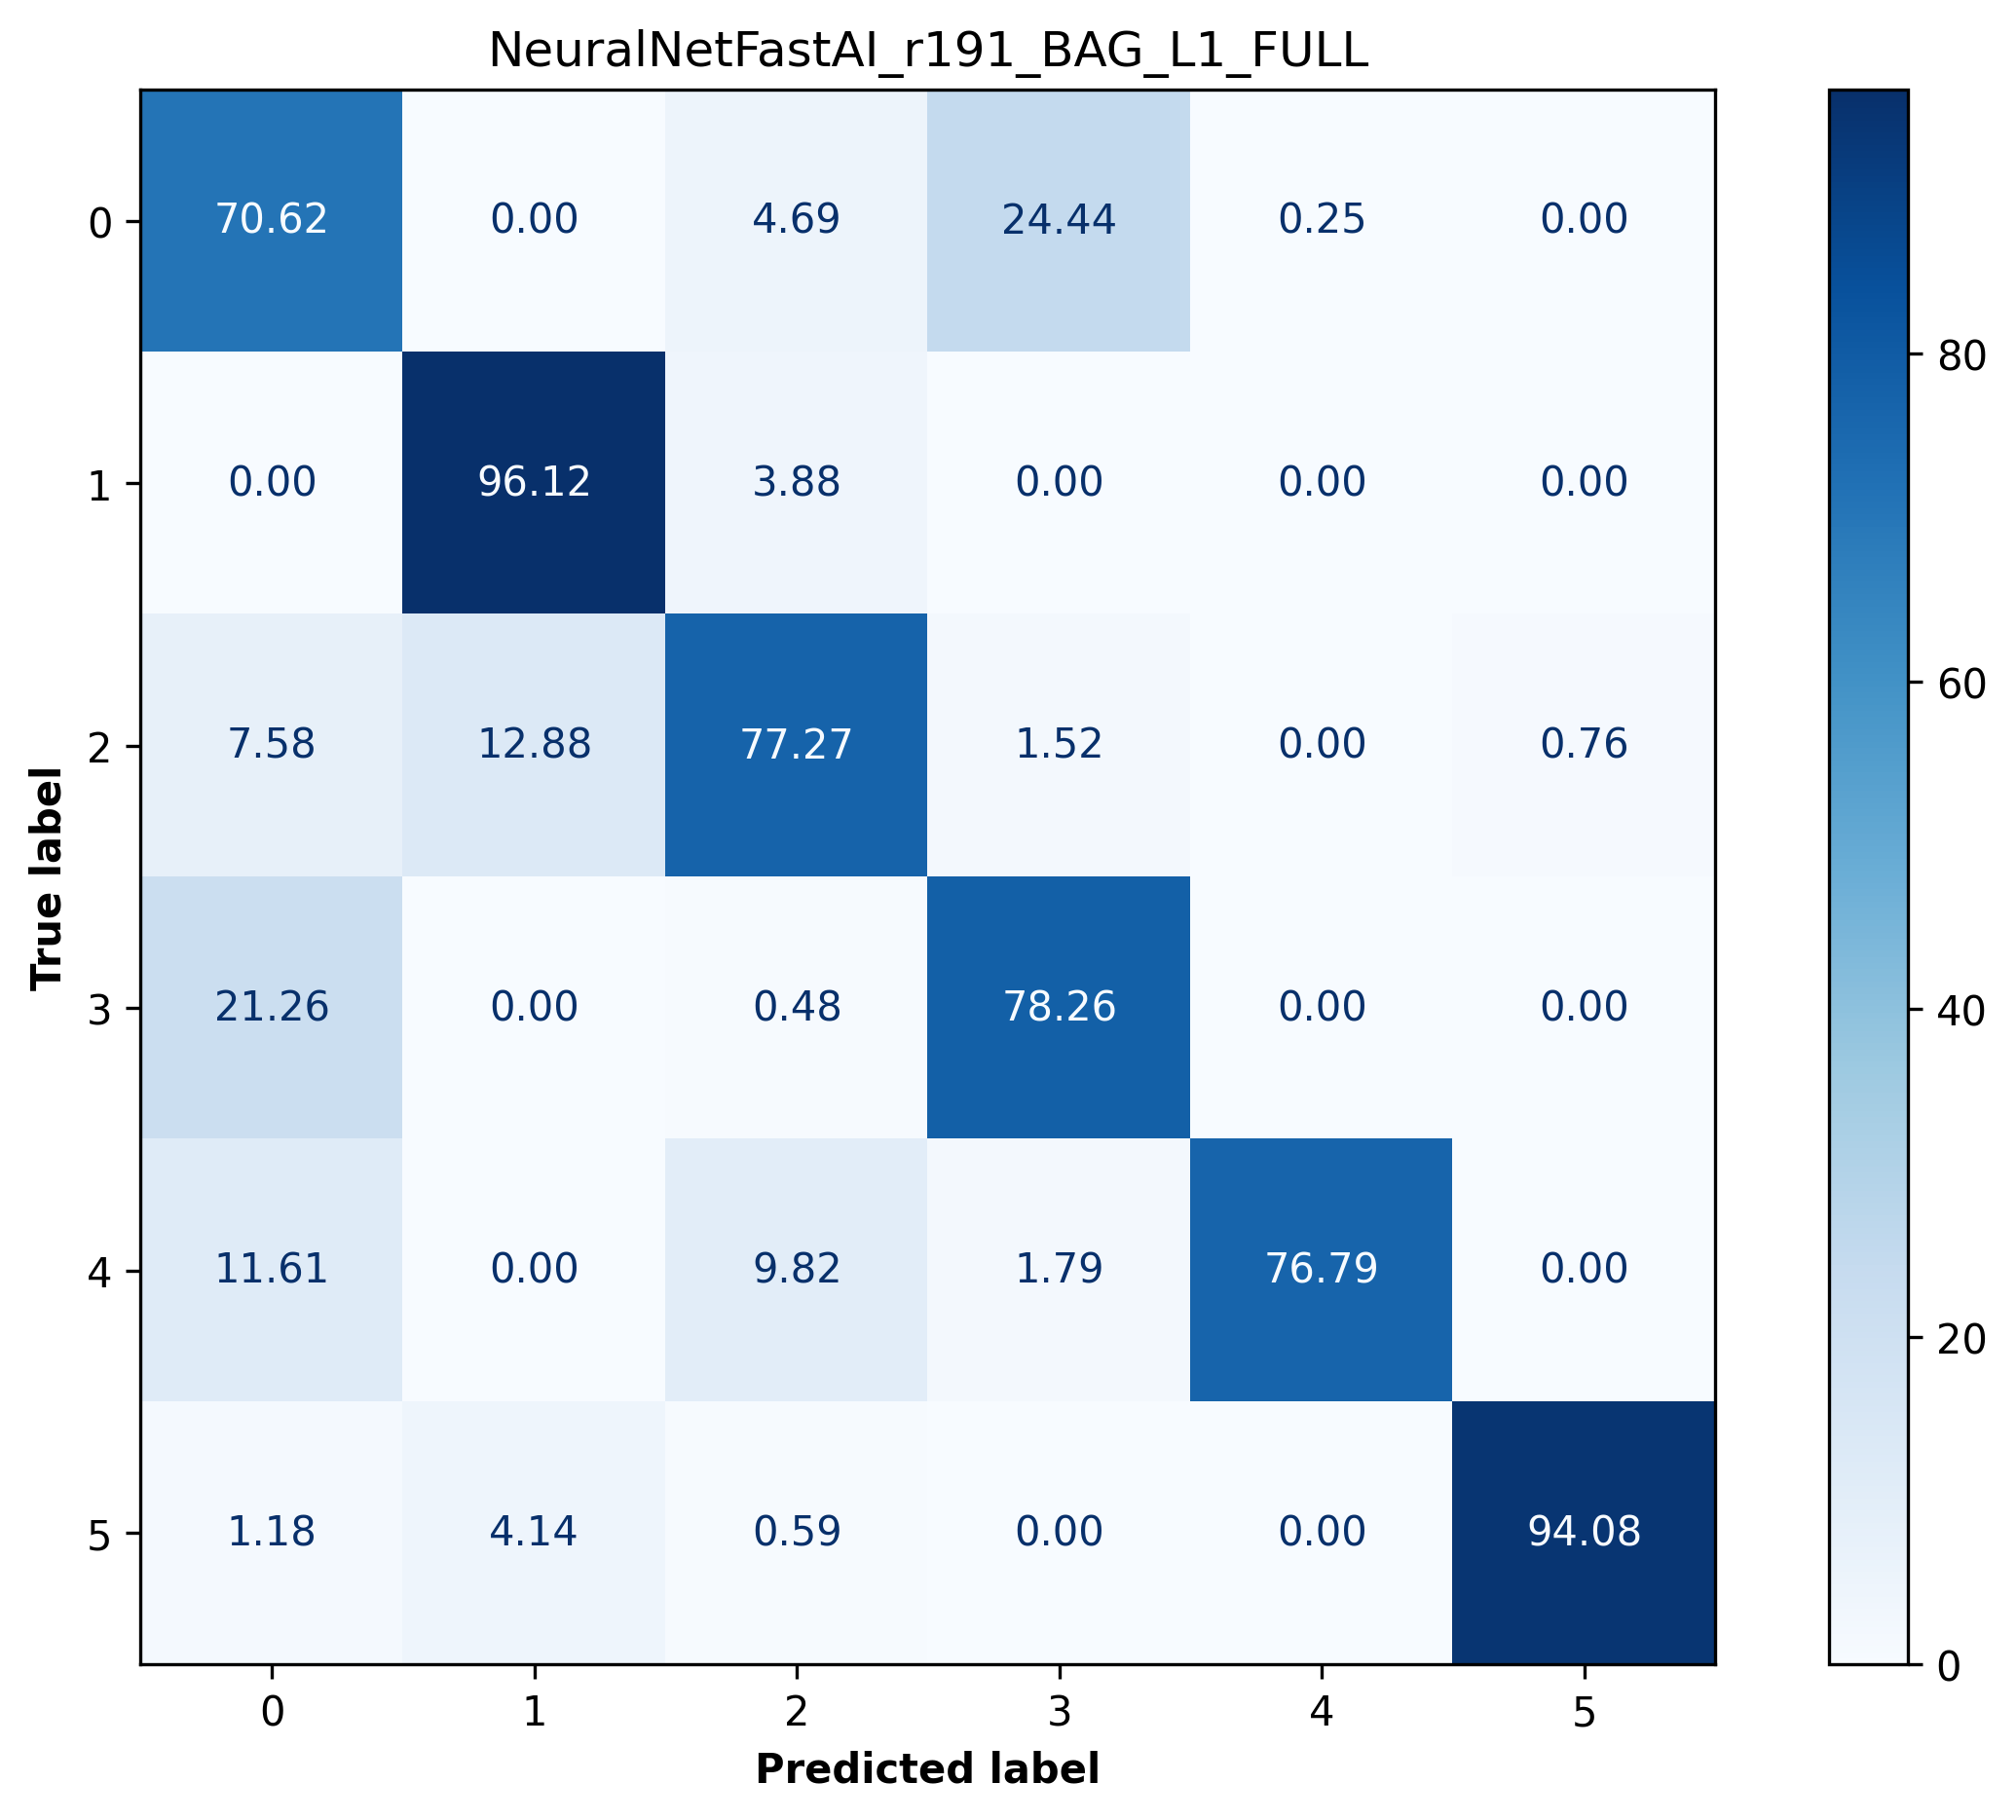

In [28]:
#autogl_res_DP = evaluate_models_and_display_summary(test_set_DINO.to_pandas(), "label", predictor= predictor, model_name = ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"])
autogl_res_DINO_agg = evaluate_models_and_display_summary(test_set_DINO_agg.to_pandas(), "moa", predictor= predictor_agg_DINO, model_name = ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_r191_BAG_L1_FULL"])

Model: LightGBMXT_BAG_L2_FULL, Accuracy: 0.7647


,precision,recall,f1-score,support
0,0.734468,0.744432,0.739417,12752.000000
1,0.809249,0.879871,0.843083,5569.000000
2,0.655801,0.726038,0.689134,5154.000000
3,0.632446,0.501812,0.559606,6347.000000
4,0.811518,0.835354,0.823264,3711.000000
5,0.956352,0.955012,0.955682,6424.000000
accuracy,0.764697,0.764697,0.764697,0.764697
macro avg,0.766639,0.773753,0.768364,39957.000000
weighted avg,0.761367,0.764697,0.761374,39957.000000


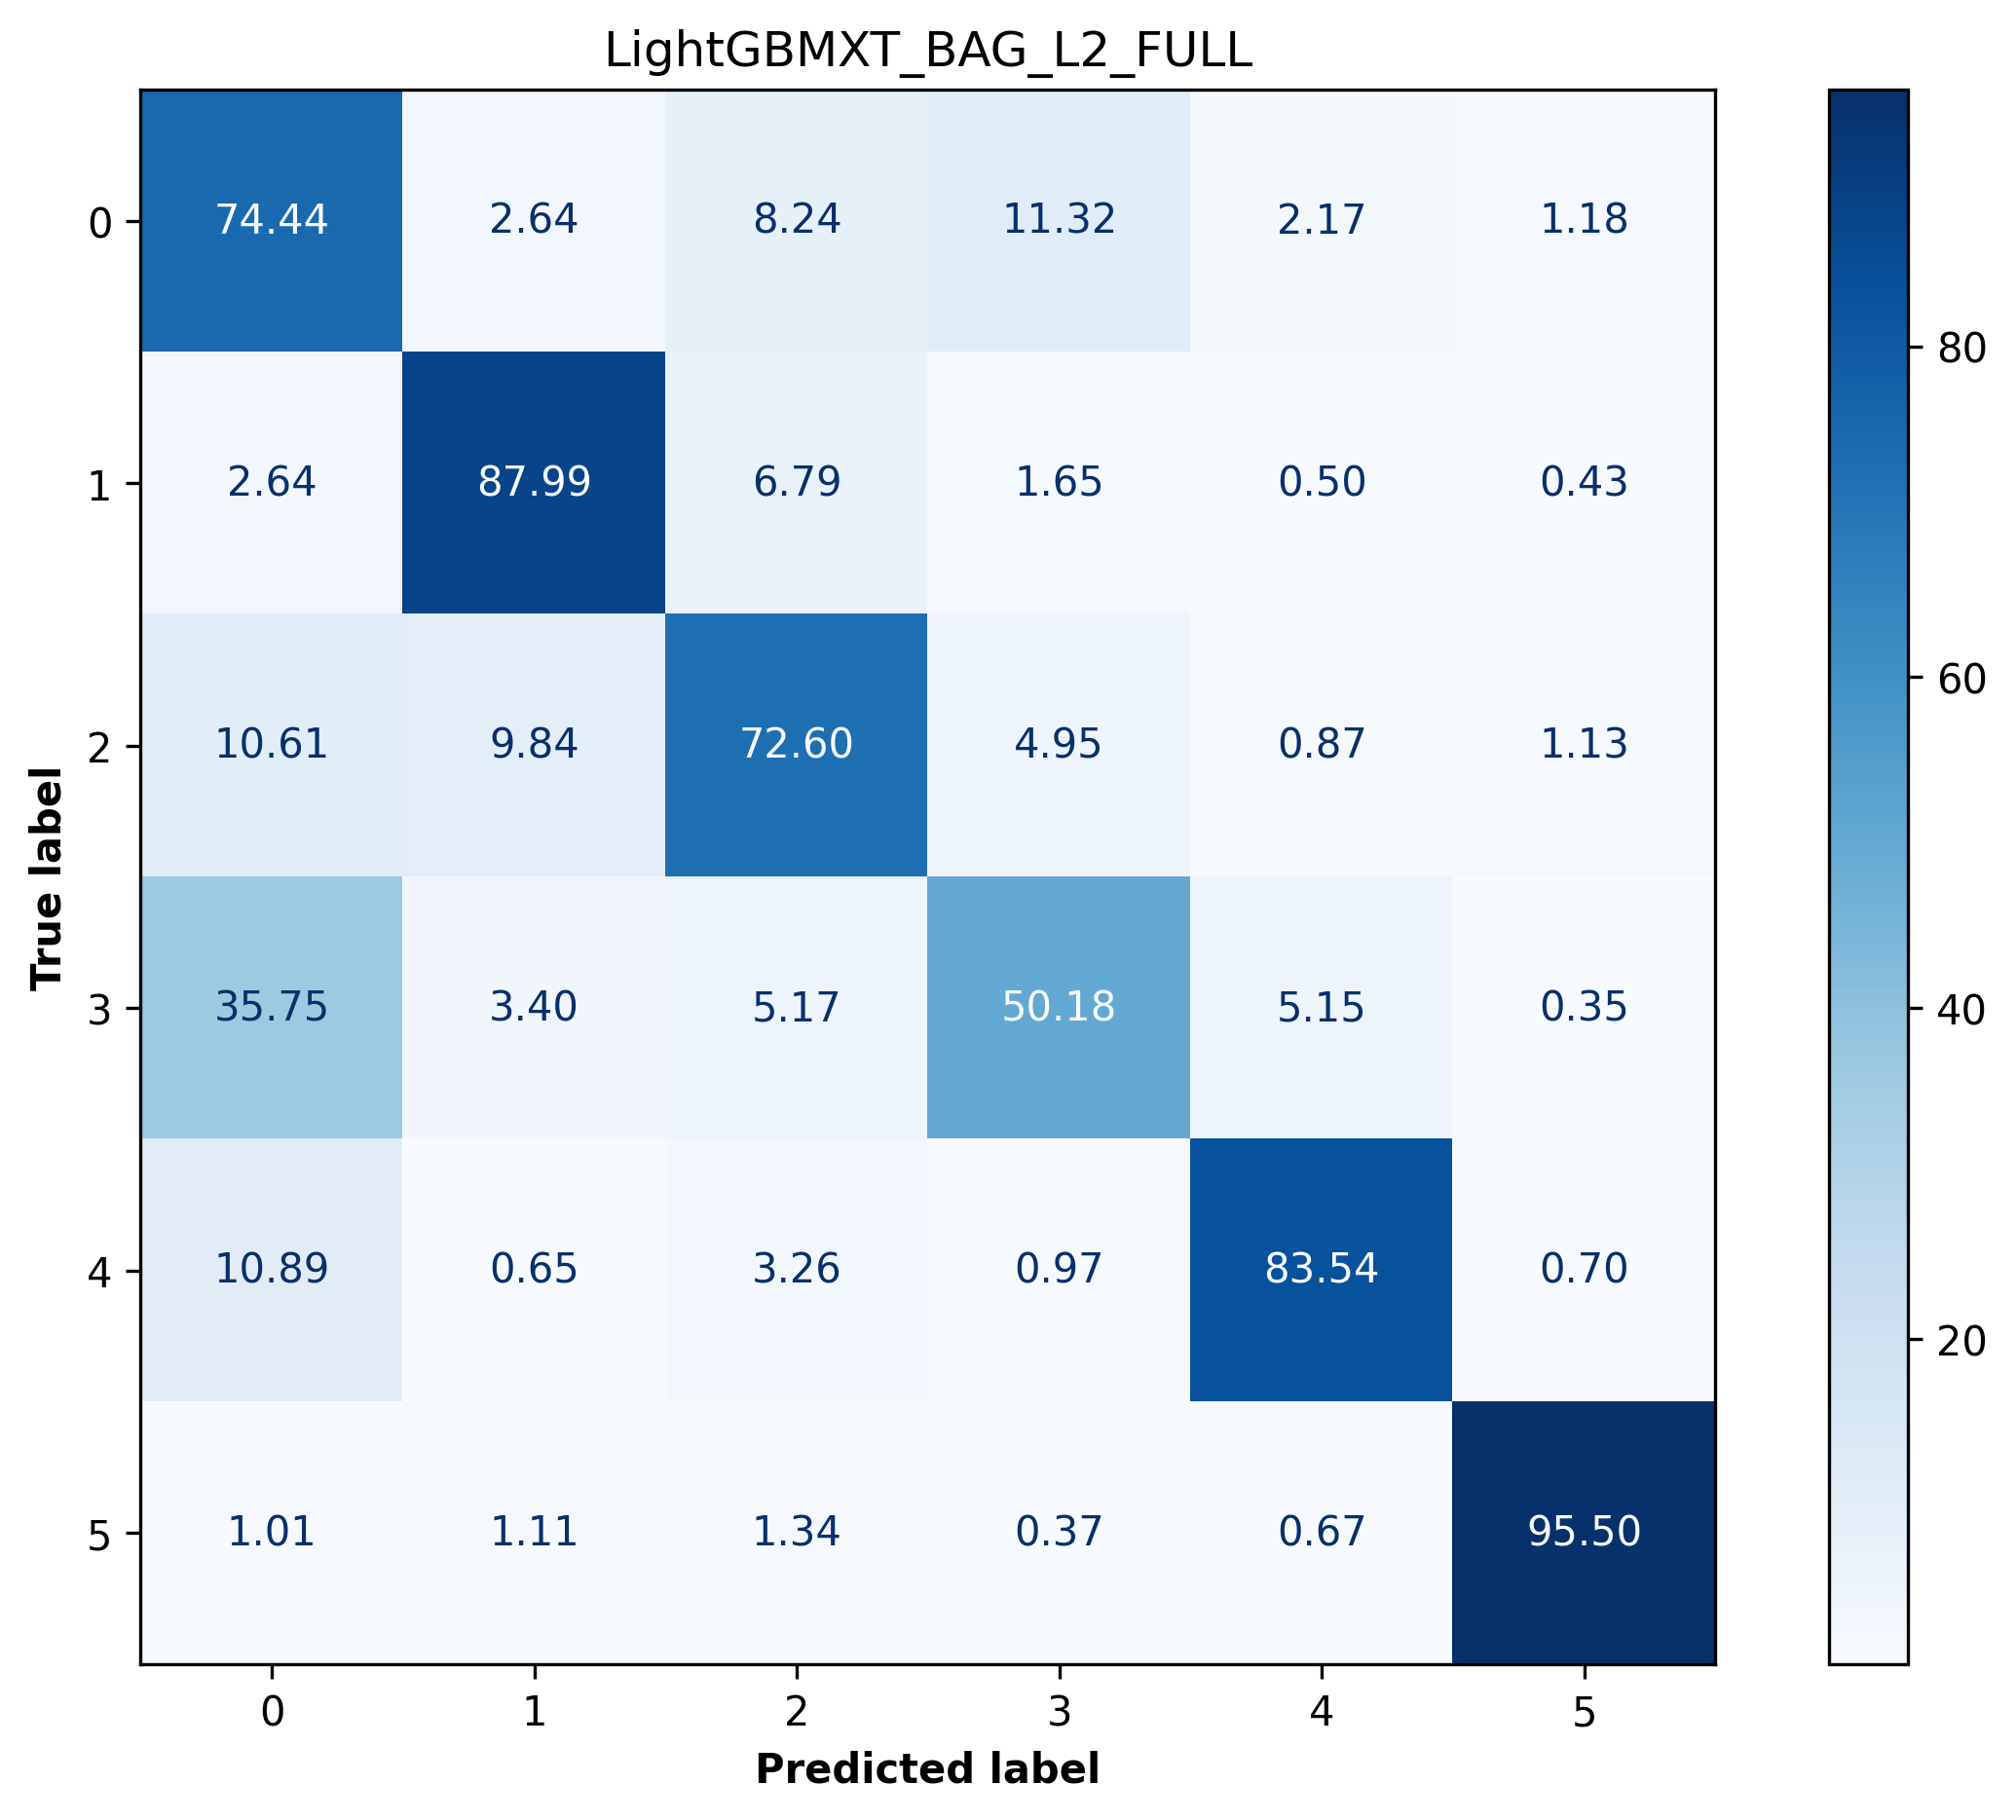

Model: NeuralNetFastAI_BAG_L1_FULL, Accuracy: 0.7338


,precision,recall,f1-score,support
0,0.704030,0.739806,0.721474,12752.000000
1,0.803782,0.770874,0.786984,5569.000000
2,0.580585,0.659100,0.617356,5154.000000
3,0.647631,0.503860,0.566770,6347.000000
4,0.770124,0.804365,0.786872,3711.000000
5,0.918028,0.936177,0.927013,6424.000000
accuracy,0.733814,0.733814,0.733814,0.733814
macro avg,0.737363,0.735697,0.734412,39957.000000
weighted avg,0.733594,0.733814,0.731720,39957.000000


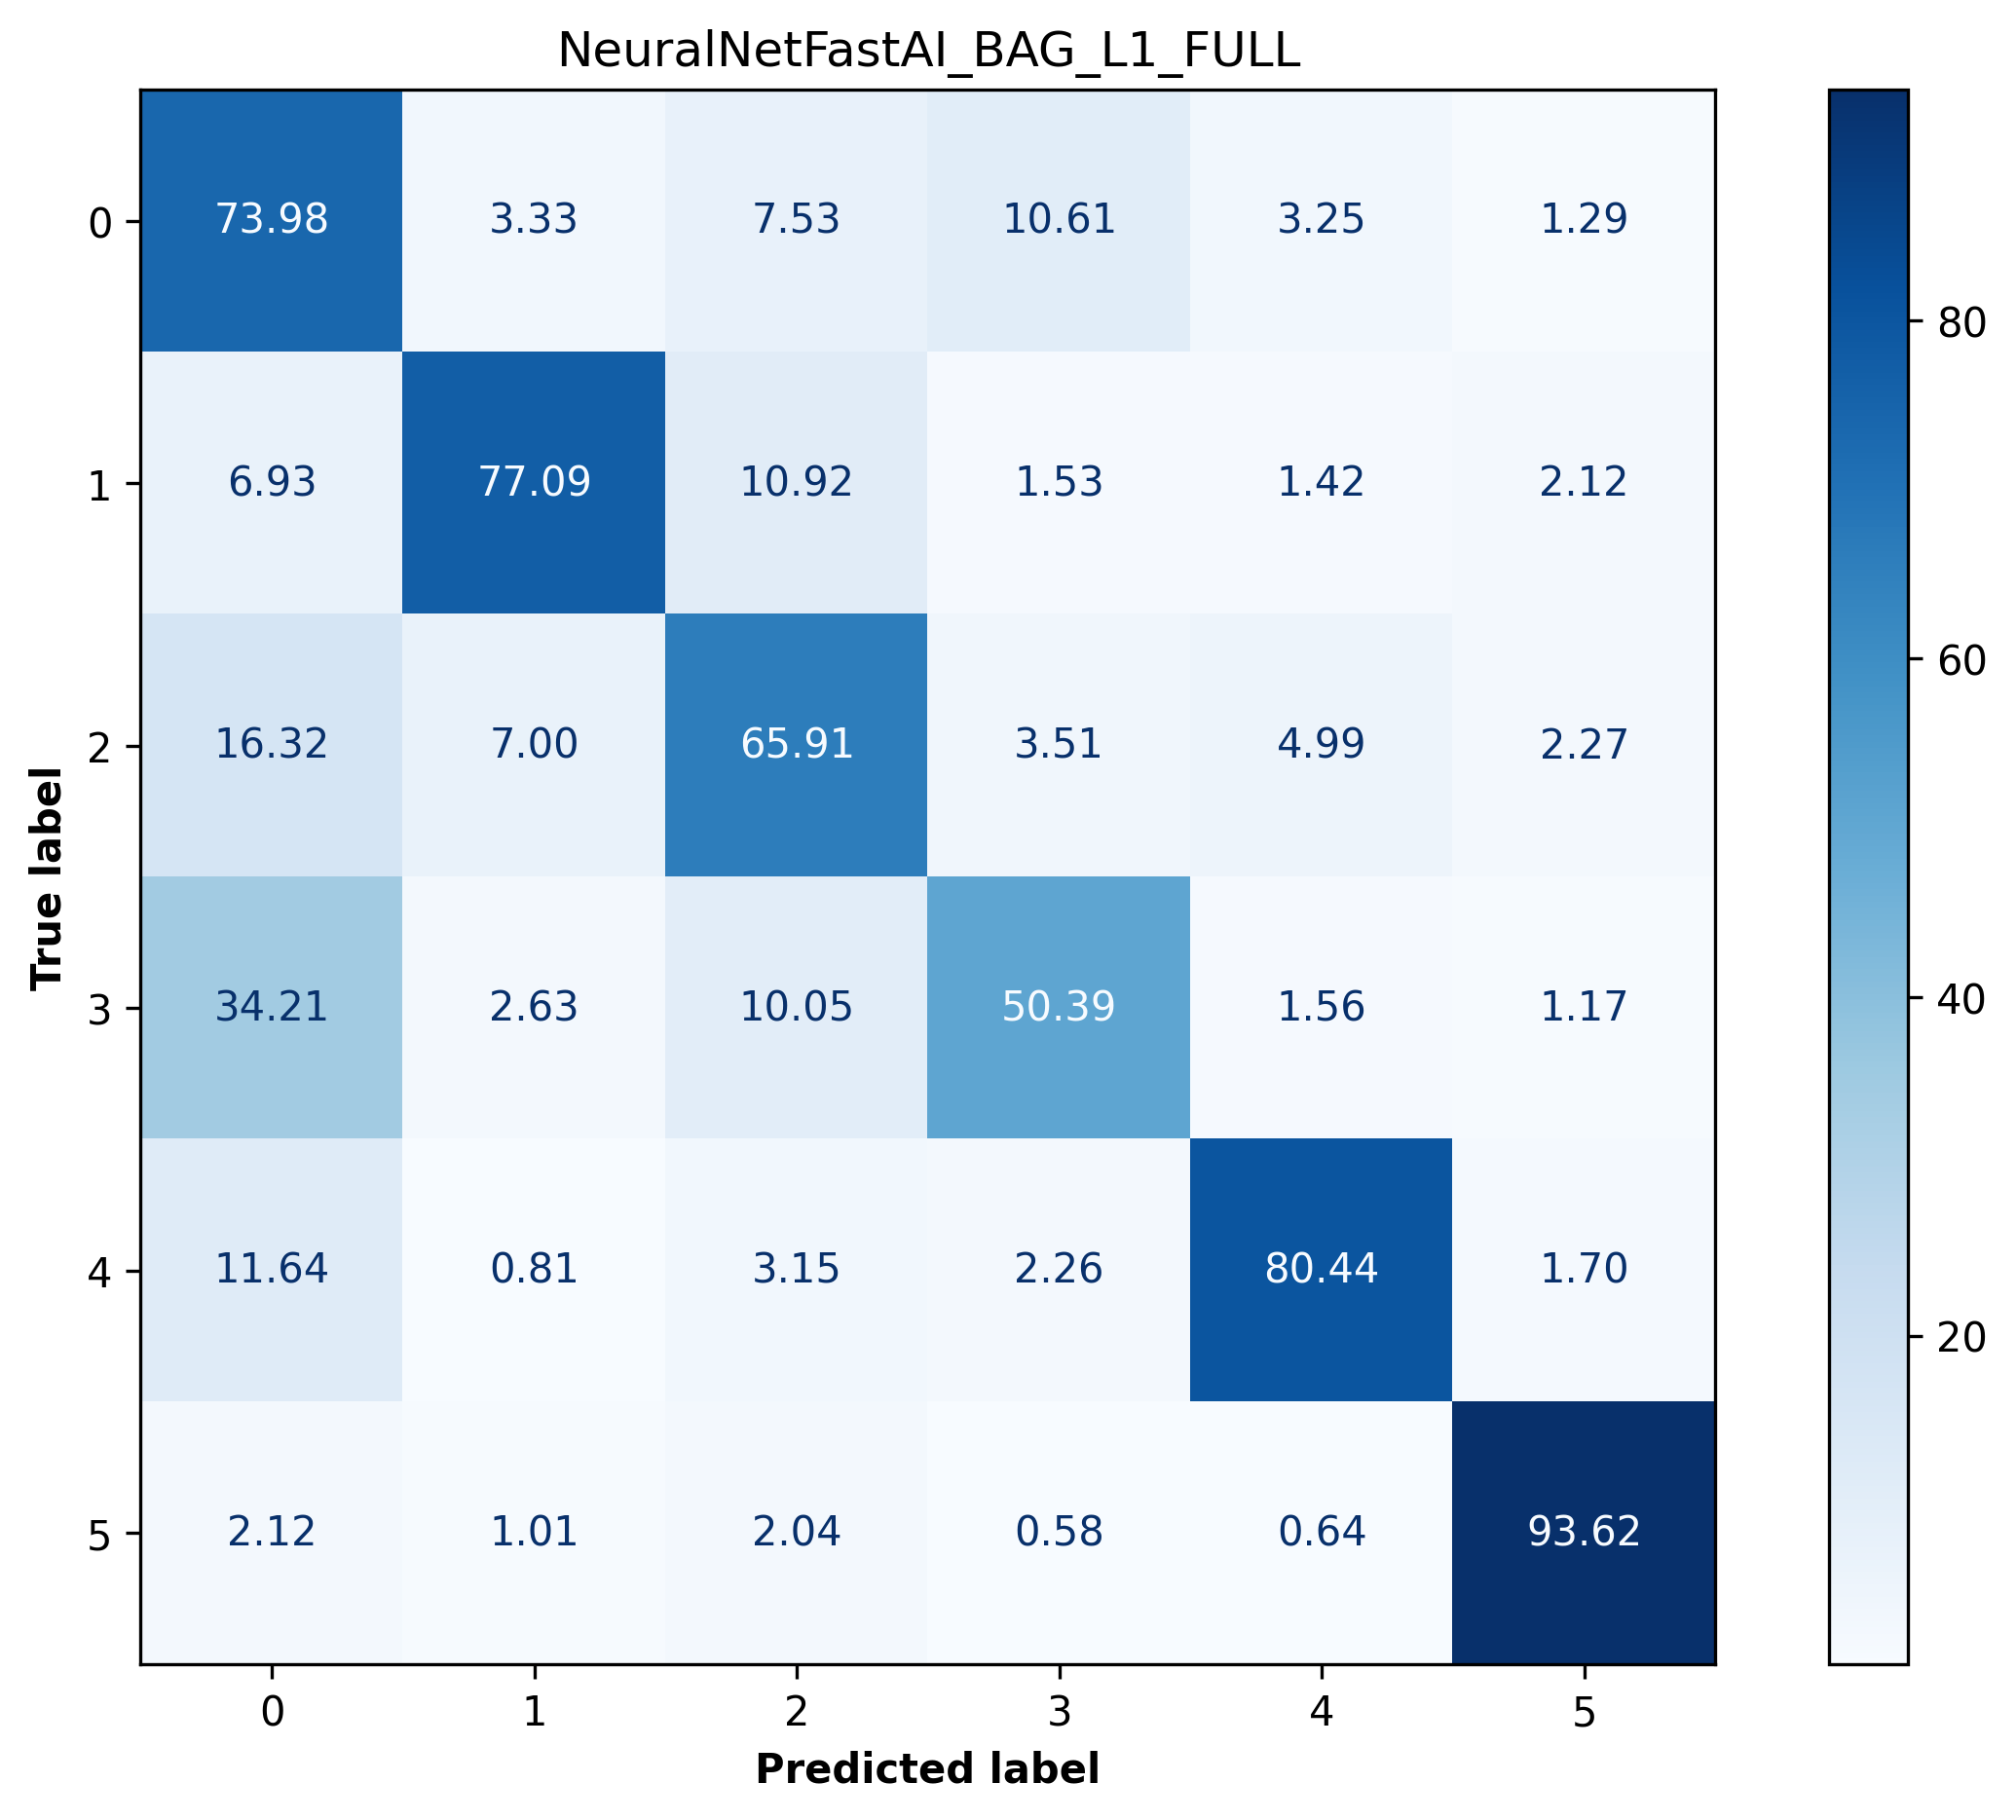

Model: LightGBMXT_BAG_L2_FULL, Accuracy: 0.6654


,precision,recall,f1-score,support
0,0.623327,0.766441,0.687515,12879.000000
1,0.629188,0.724665,0.673560,5753.000000
2,0.589954,0.524555,0.555336,5620.000000
3,0.589842,0.482456,0.530772,6042.000000
4,0.766482,0.648085,0.702329,3839.000000
5,0.950858,0.717687,0.817980,6174.000000
accuracy,0.665443,0.665443,0.665443,0.665443
macro avg,0.691608,0.643982,0.661249,40307.000000
weighted avg,0.678295,0.665443,0.664993,40307.000000


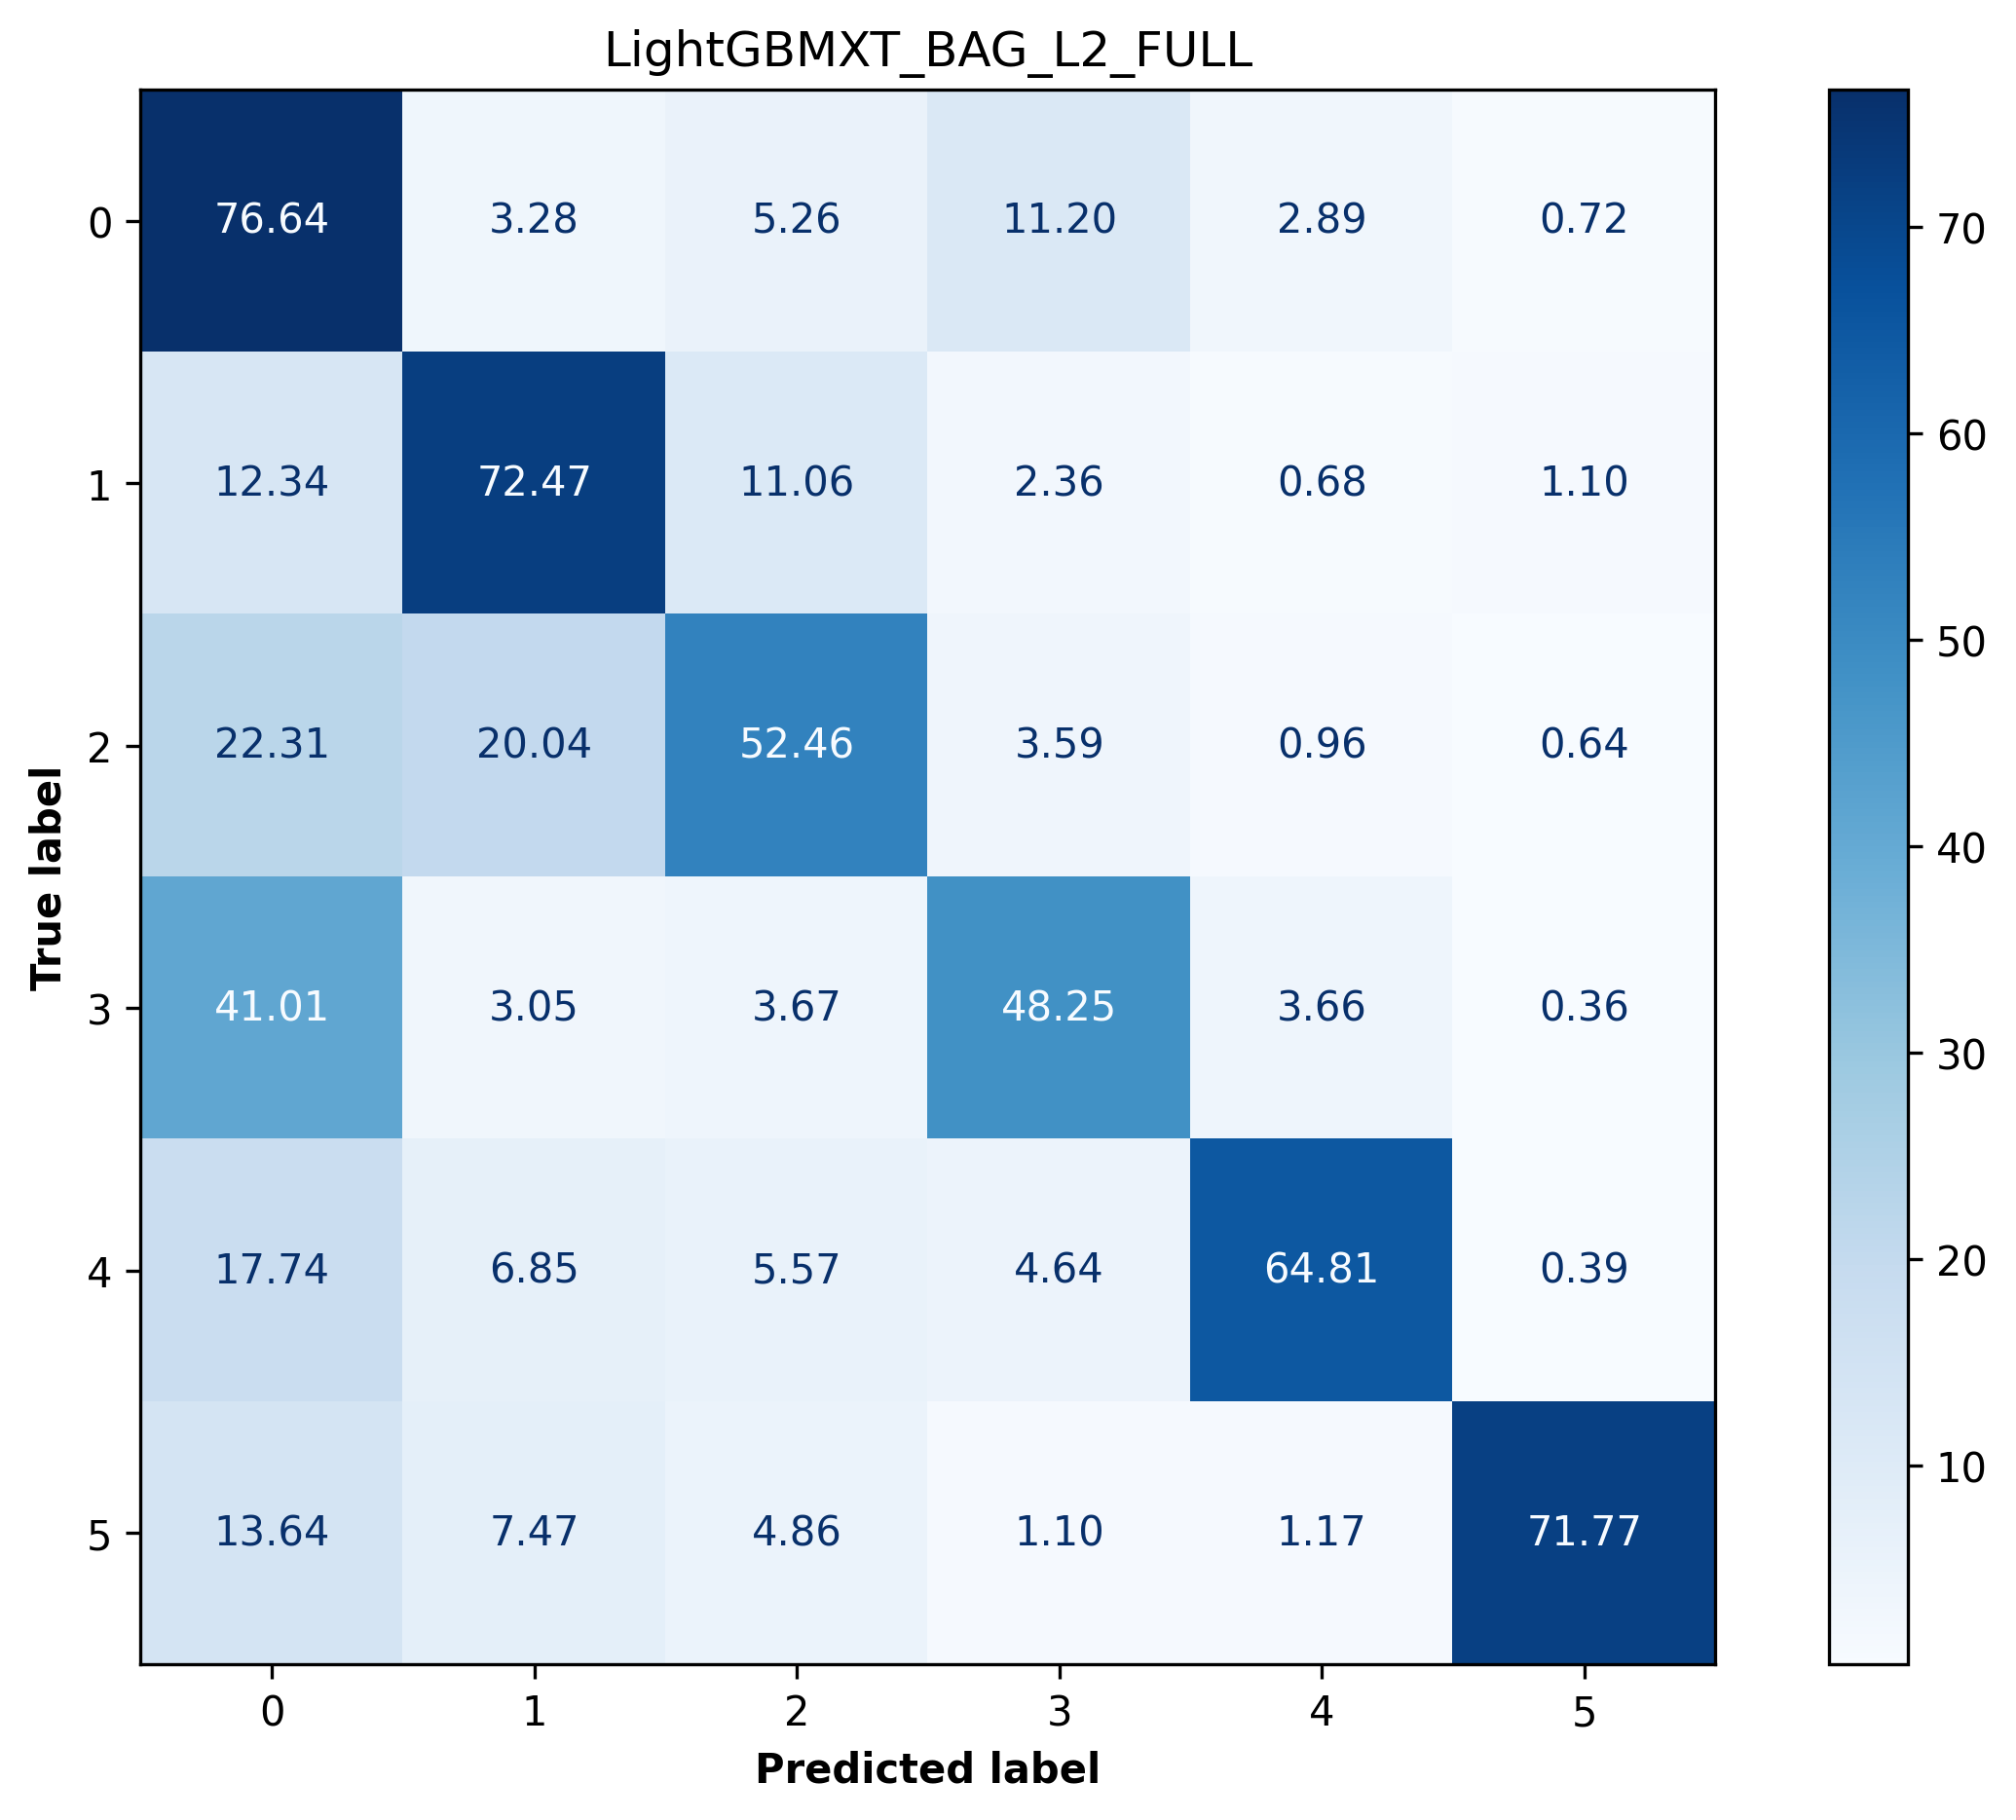

Model: NeuralNetFastAI_BAG_L1_FULL, Accuracy: 0.6510


,precision,recall,f1-score,support
0,0.613109,0.759686,0.678573,12879.000000
1,0.622322,0.701721,0.659641,5753.000000
2,0.551902,0.534520,0.543071,5620.000000
3,0.561270,0.415425,0.477459,6042.000000
4,0.798074,0.647564,0.714984,3839.000000
5,0.914528,0.715743,0.803017,6174.000000
accuracy,0.651004,0.651004,0.651004,0.651004
macro avg,0.676867,0.629110,0.646124,40307.000000
weighted avg,0.661906,0.651004,0.649360,40307.000000


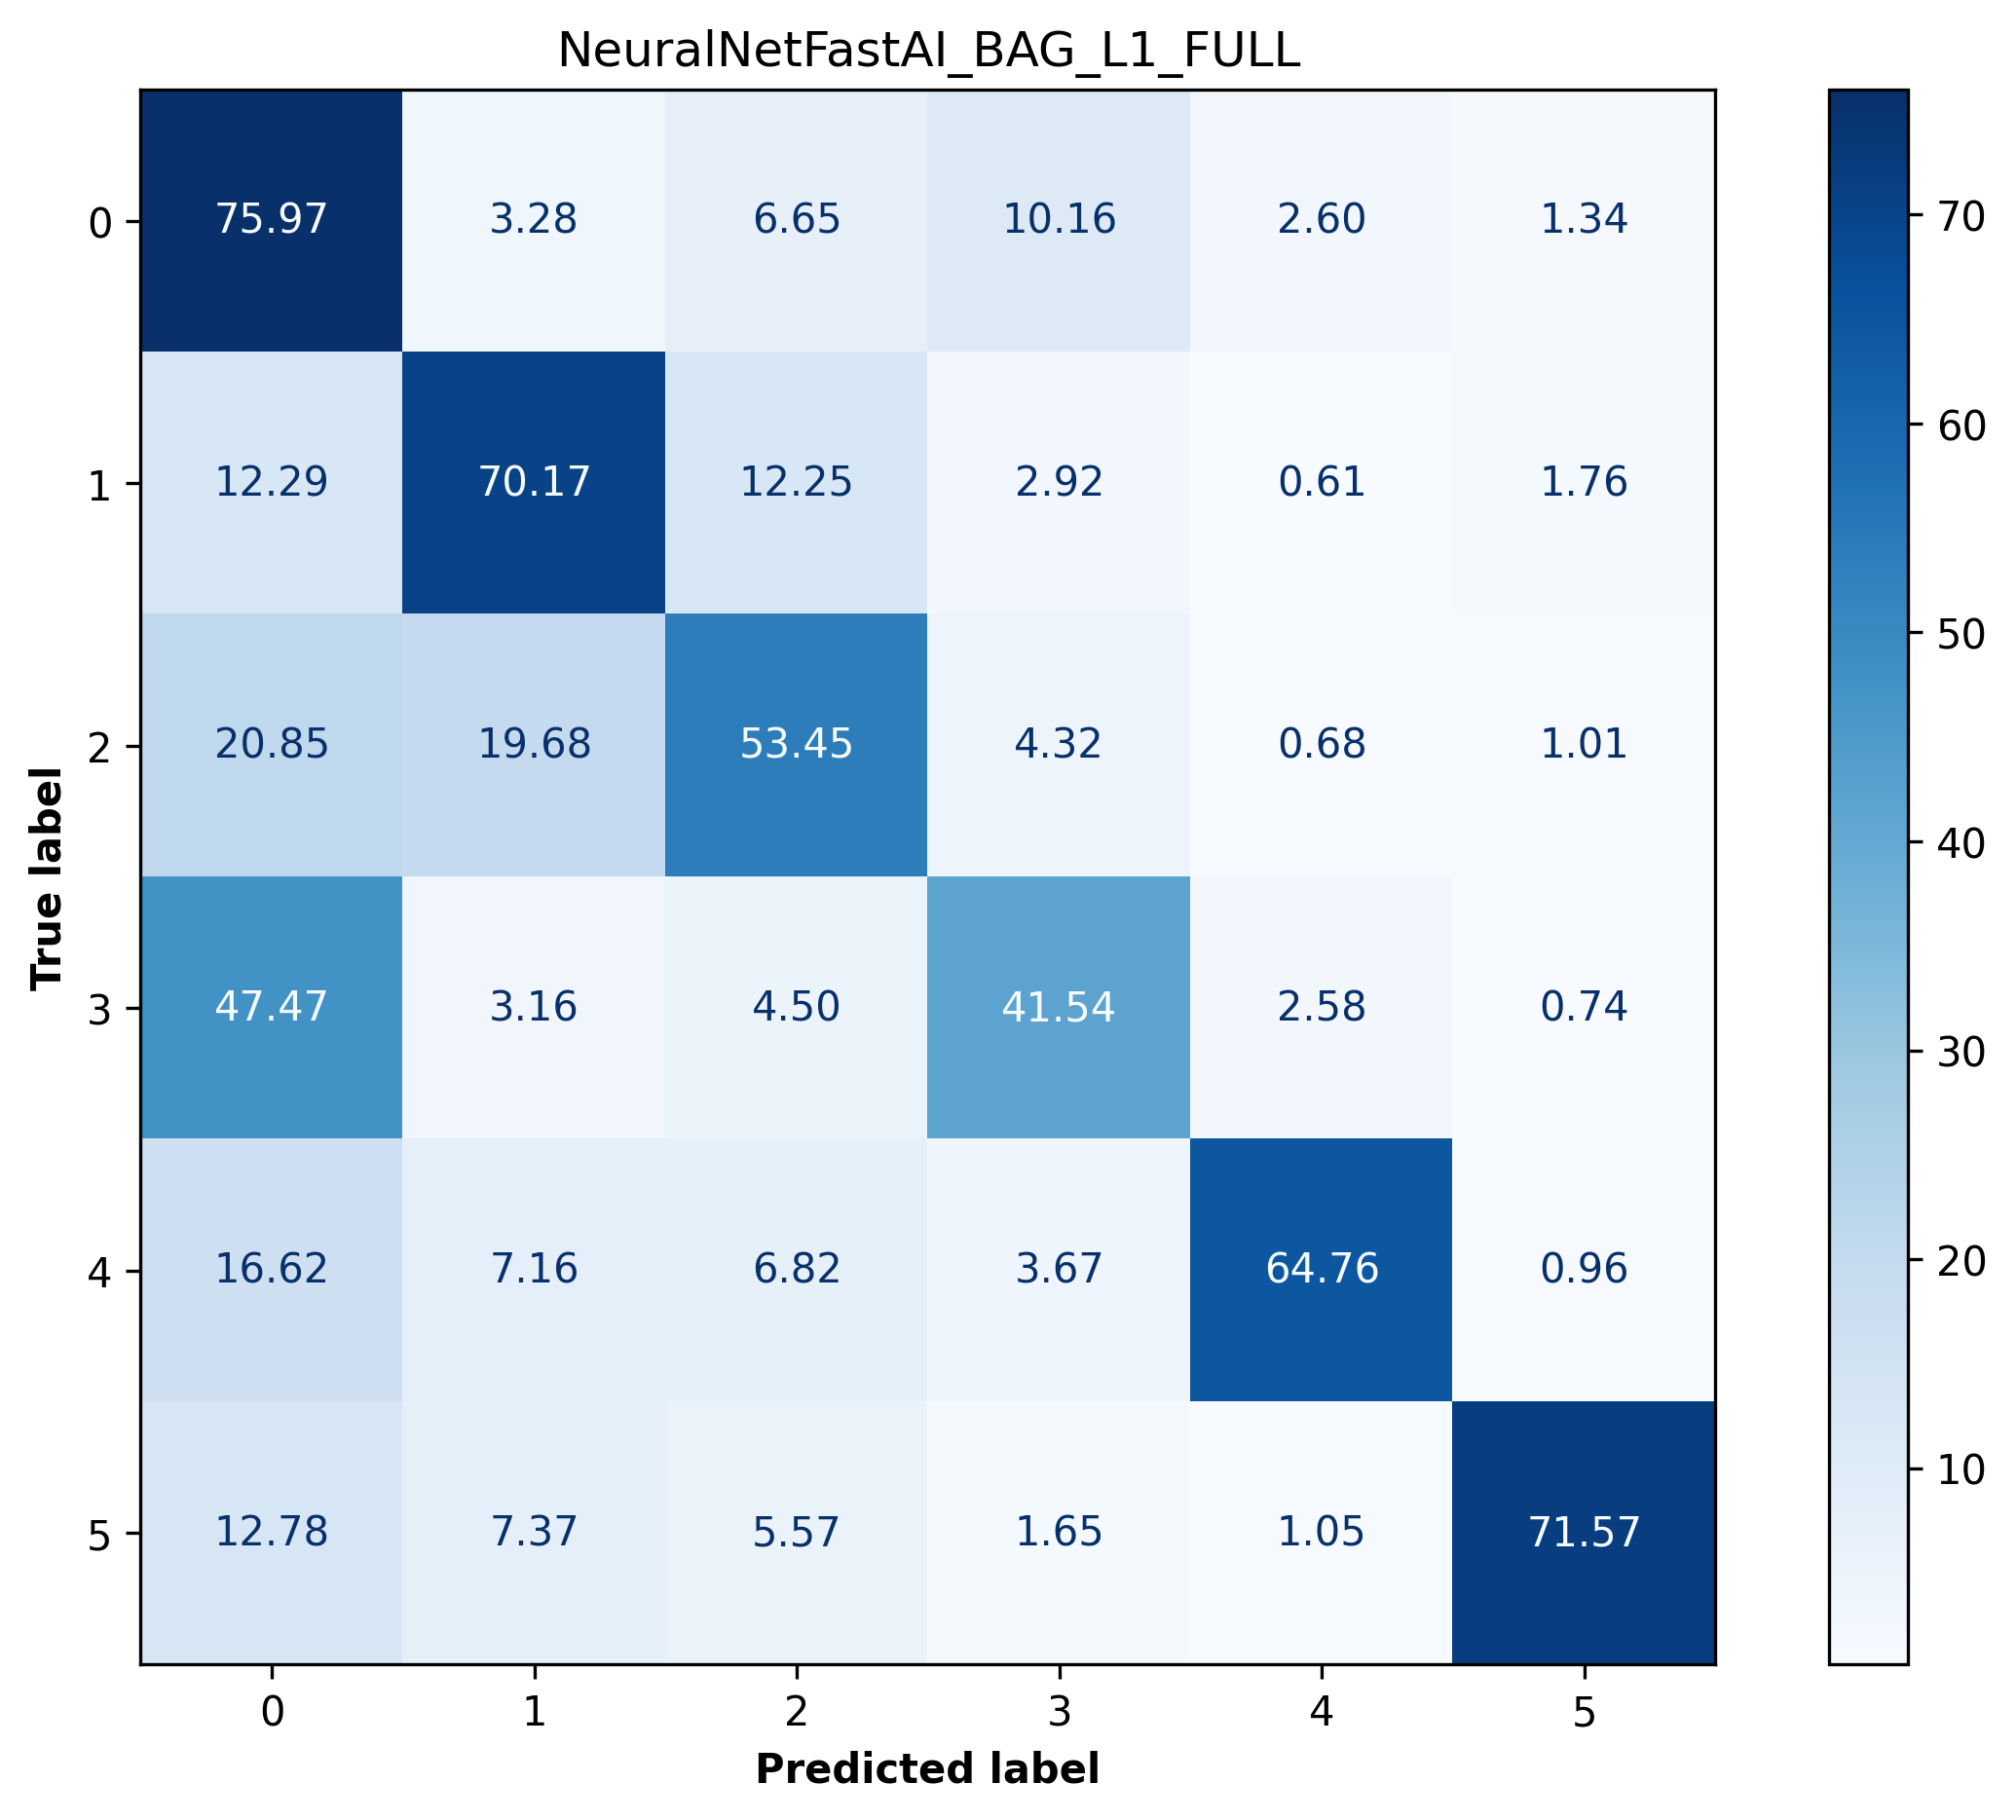

Model: LightGBMXT_BAG_L2_FULL, Accuracy: 0.7986


,precision,recall,f1-score,support
0,0.808767,0.795301,0.801977,12853.000000
1,0.744271,0.841921,0.790090,6288.000000
2,0.768007,0.678076,0.720245,5551.000000
3,0.669065,0.701456,0.684878,5701.000000
4,0.880846,0.847980,0.864101,3243.000000
5,0.948374,0.930898,0.939554,6295.000000
accuracy,0.798603,0.798603,0.798603,0.798603
macro avg,0.803221,0.799272,0.800141,39931.000000
weighted avg,0.800861,0.798603,0.798759,39931.000000


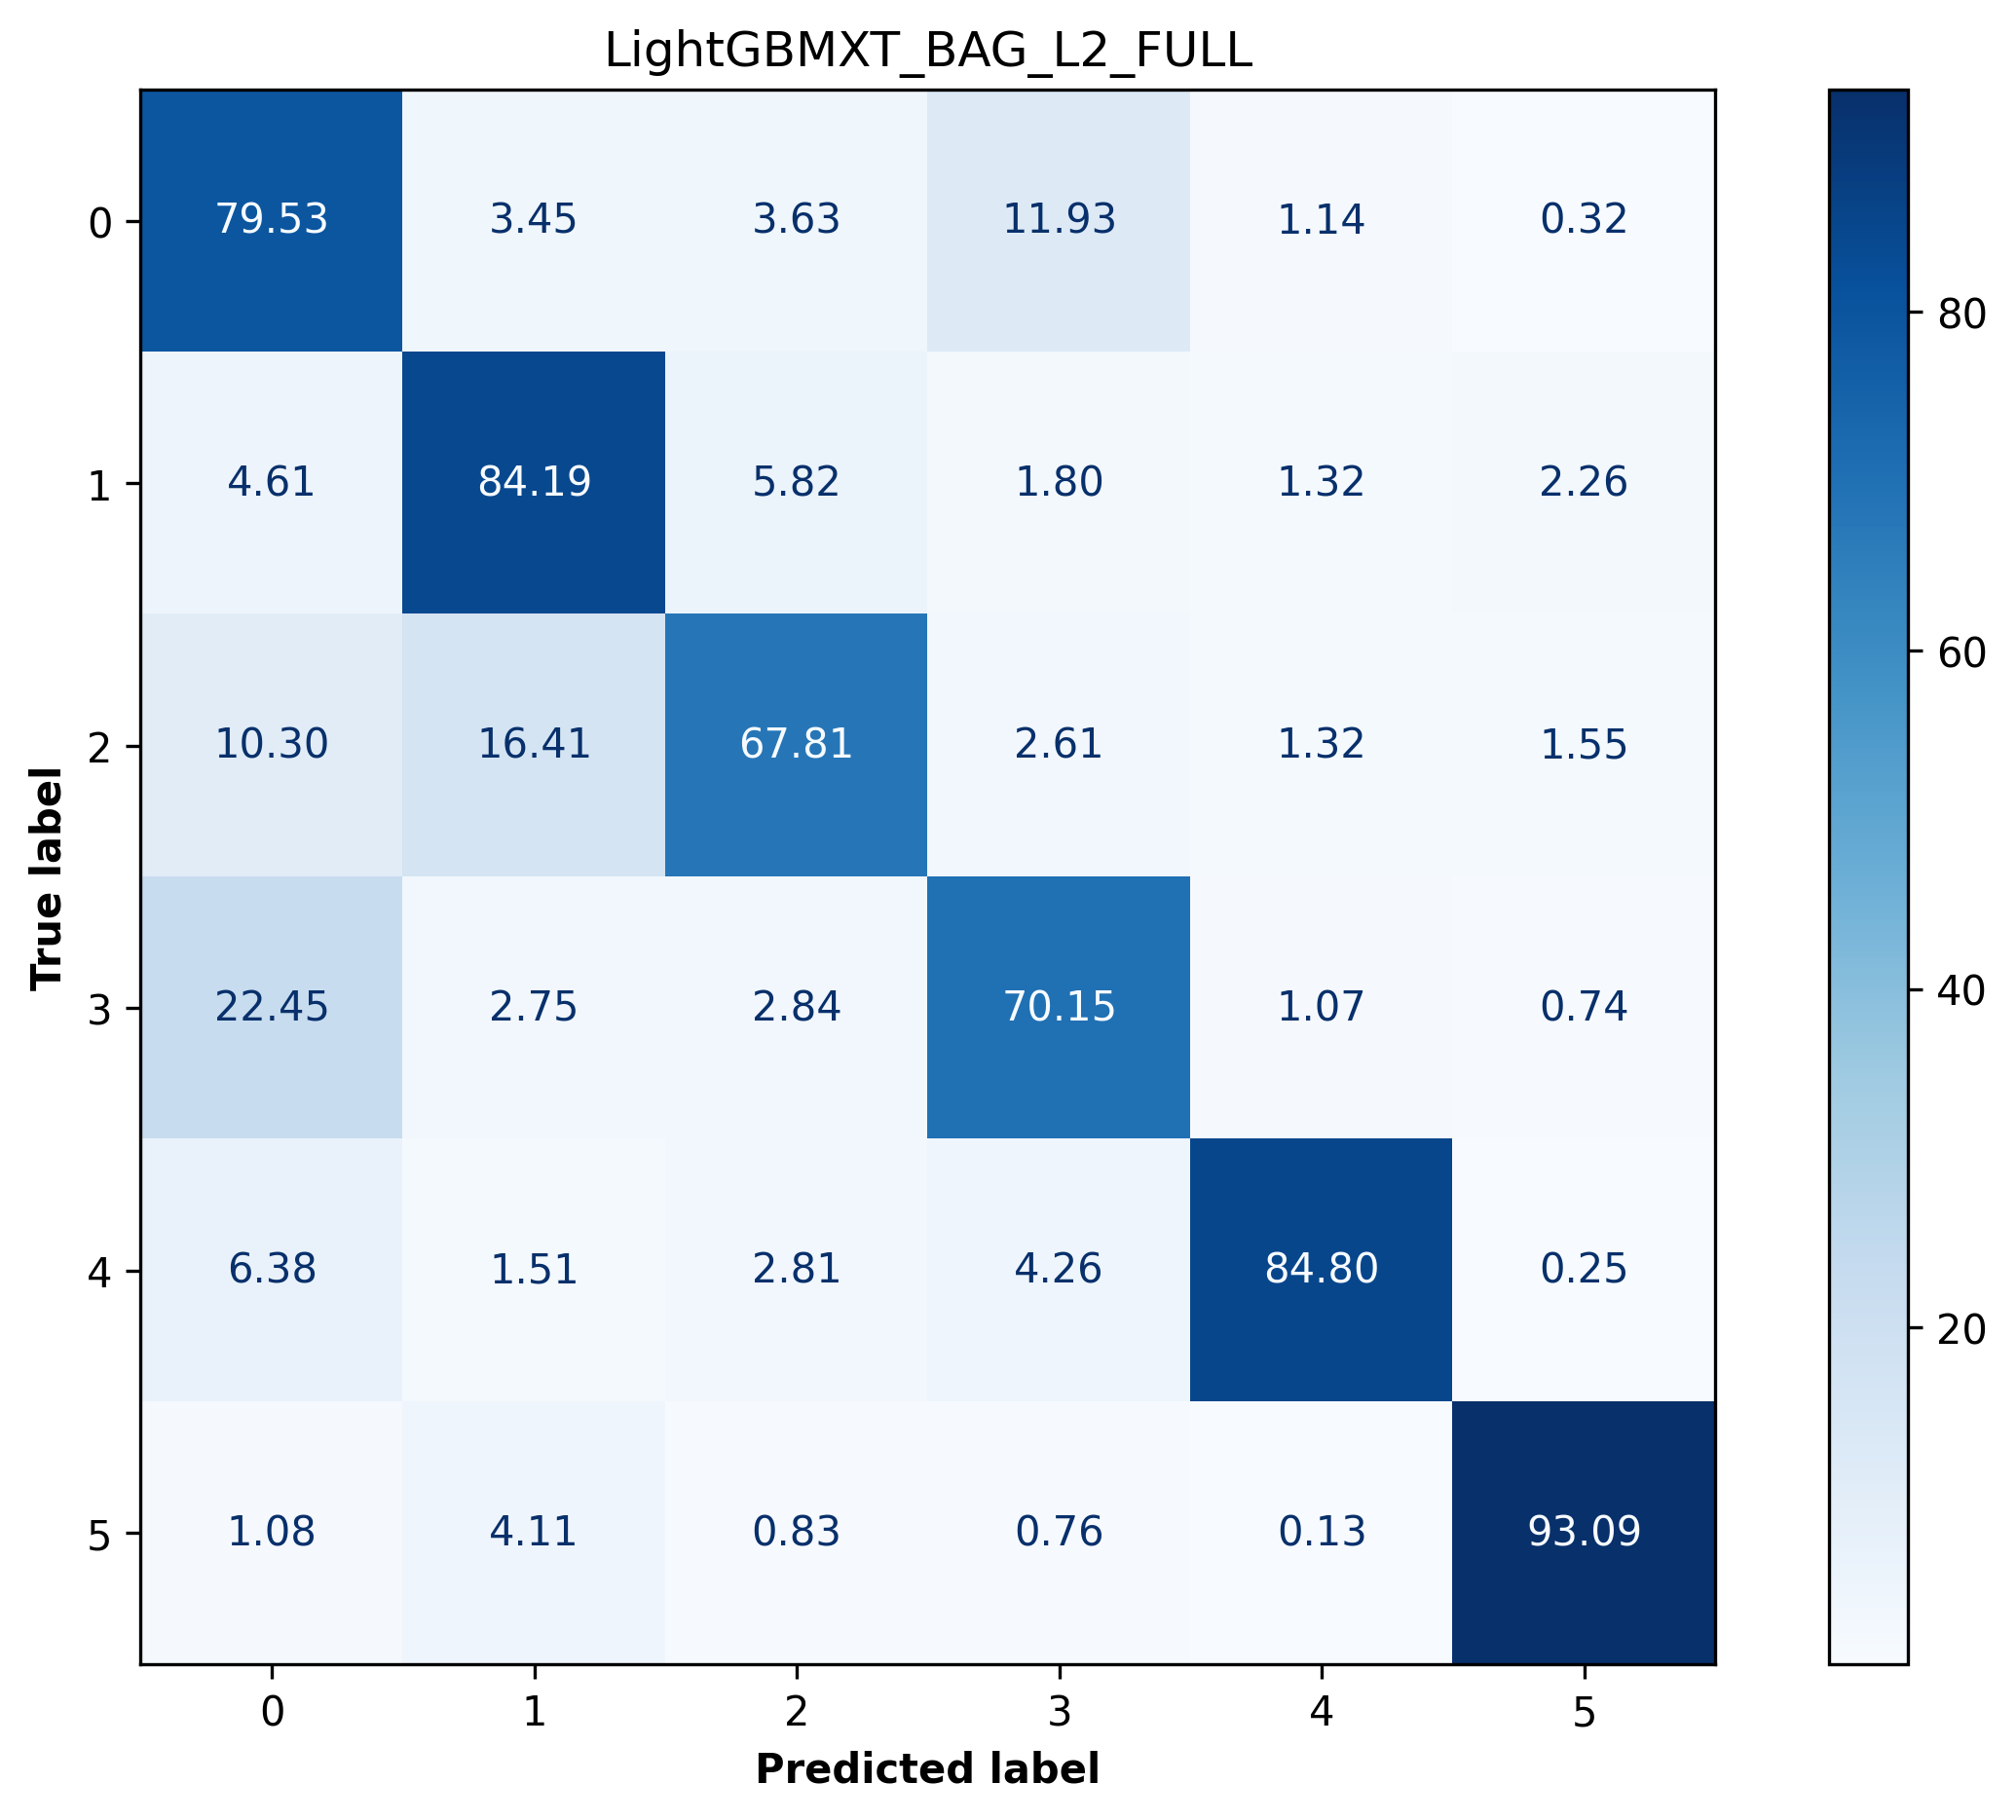

Model: NeuralNetFastAI_BAG_L1_FULL, Accuracy: 0.7903


,precision,recall,f1-score,support
0,0.812231,0.778106,0.794803,12853.000000
1,0.720230,0.856075,0.782299,6288.000000
2,0.800711,0.649252,0.717071,5551.000000
3,0.642674,0.701631,0.670860,5701.000000
4,0.854017,0.842430,0.848184,3243.000000
5,0.938585,0.927403,0.932960,6295.000000
accuracy,0.790313,0.790313,0.790313,0.790313
macro avg,0.794741,0.792483,0.791029,39931.000000
weighted avg,0.795247,0.790313,0.790448,39931.000000


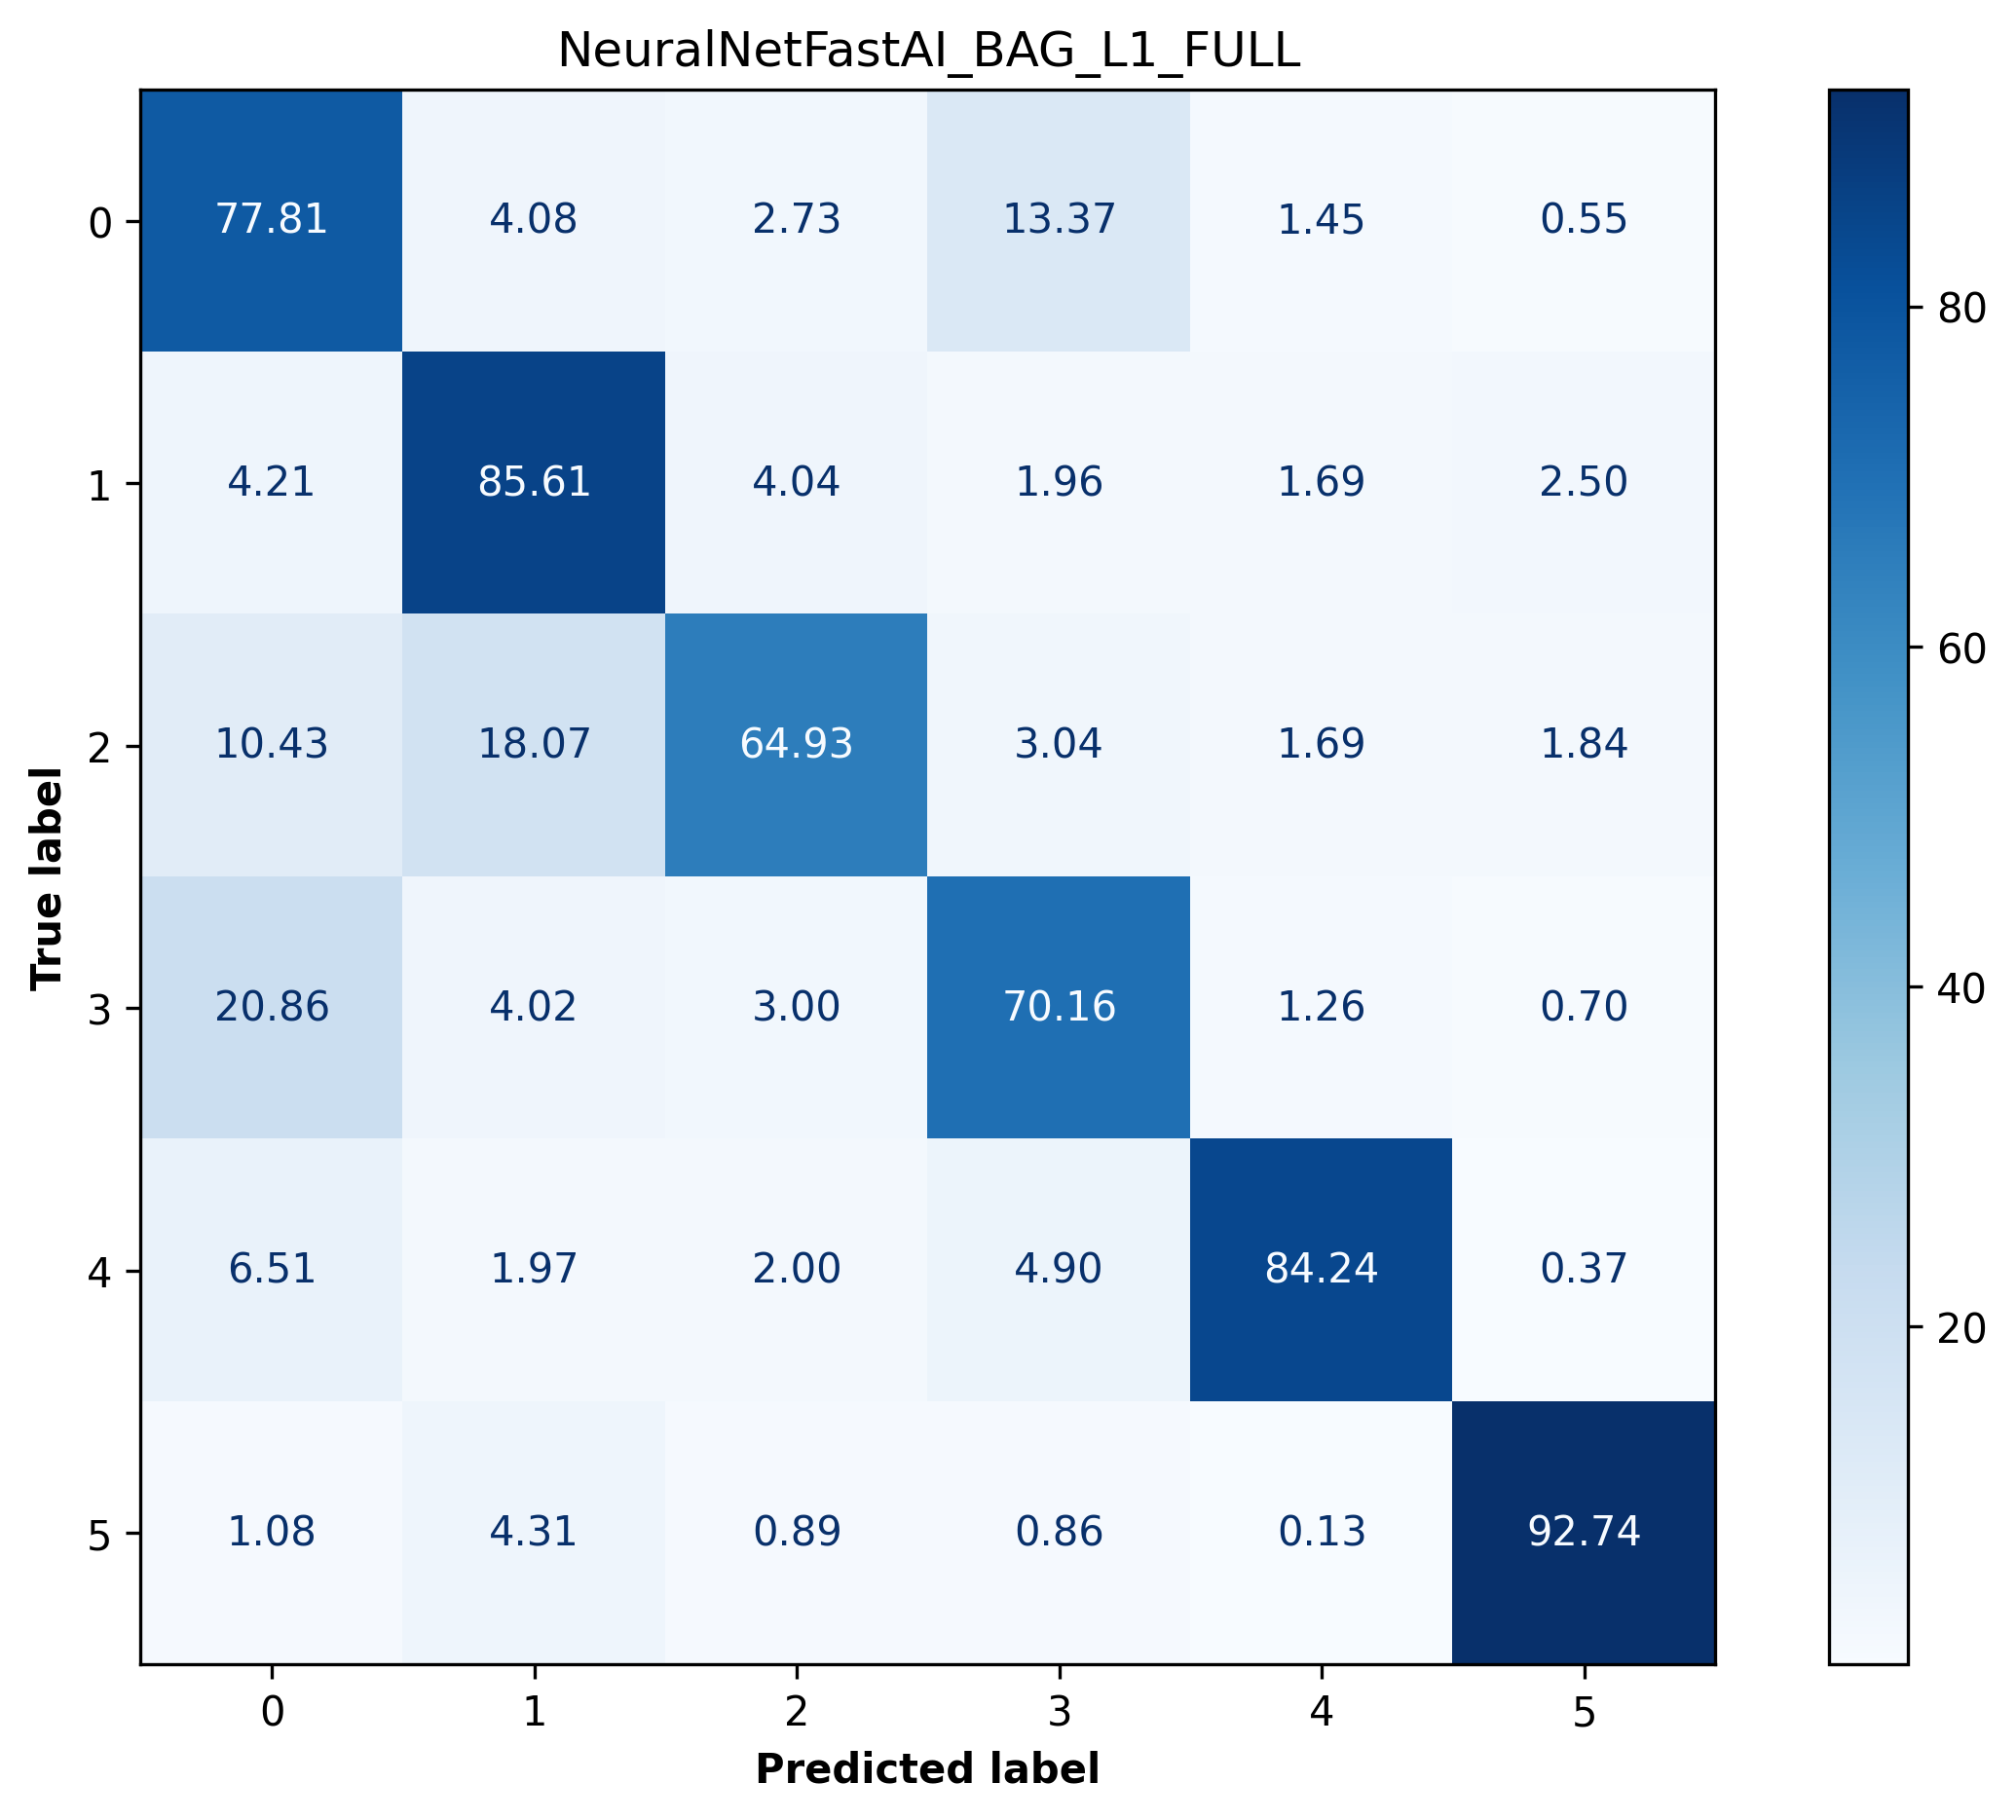

In [29]:
autogl_res_CP = evaluate_models_and_display_summary(test_set_CP.to_pandas(), "moa", predictor= predictor_CP, model_name = ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"])
autogl_res_DP = evaluate_models_and_display_summary(test_set_DP.to_pandas(), "moa", predictor= predictor_DP, model_name = ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"])
autogl_res_DINO = evaluate_models_and_display_summary(test_set_DINO.to_pandas(), "moa", predictor= predictor_DINO, model_name = ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"])


# Majority voting

## Data prep

### DINO

In [82]:
dino_profiles = pl.read_parquet("features/single_cell_features_DINO.parquet")

In [142]:
feature_columns_df1 = [col for col in dino_profiles.columns if "Feature" in col]
feature_columns_df2 = [col for col in test_set_DINO.columns if "Feature" in col]

# Convert columns to `f32` type in both dataframes
dino_profiles = dino_profiles.with_columns([pl.col(col).cast(pl.Float32) for col in feature_columns_df1])
test_set_DINO = test_set_DINO.with_columns([pl.col(col).cast(pl.Float32) for col in feature_columns_df2])

# Step 3: Perform the inner join on all matching "Feature" columns
joined_df_DINO = dino_profiles.join(test_set_DINO, on=feature_columns_df1, how="inner")

In [ ]:
joined_df_DINO_agg = dino_profiles.join(test_set_DINO_agg, on=feature_columns_df1, how="inner")

In [84]:
meta_dino = [feat for feat in joined_df_DINO.columns if "Feature" not in feat]

### DP

In [85]:
dp_profiles = pl.read_parquet("features/single_cell_features_DeepProfiler.parquet")

In [86]:
feature_columns_df1 = [col for col in dp_profiles.columns if "Feature" in col]
feature_columns_df2 = [col for col in test_set_DP.columns if "Feature" in col]

# Convert columns to `f32` type in both dataframes
dp_profiles = dp_profiles.with_columns([pl.col(col).cast(pl.Float32) for col in feature_columns_df1])
test_set_DP = test_set_DP.with_columns([pl.col(col).cast(pl.Float32) for col in feature_columns_df2])

# Step 3: Perform the inner join on all matching "Feature" columns
joined_df_DP = dp_profiles.join(test_set_DP, on=feature_columns_df1, how="inner")

In [87]:
meta_DP = [feat for feat in joined_df_DP.columns if "Feature" not in feat]

### CP

In [88]:
cp_profiles = pl.read_parquet("features/single_cell_features_CellProfiler.parquet")

In [89]:
feature_columns_df1 = [col for col in cp_profiles.columns if col not in ["Metadata_cmpdNameConc", "Metadata_Plate", "Metadata_cmpdName", "Metadata_Well", "Metadata_Site", "Metadata_cmpdConc", "moa", "label"]]
feature_columns_df2 = [col for col in test_set_CP.columns if "Feature" in col]

# Convert columns to `f32` type in both dataframes
cp_profiles = cp_profiles.with_columns([pl.col(col).cast(pl.Float32) for col in feature_columns_df1])
test_set_CP = test_set_CP.with_columns([pl.col(col).cast(pl.Float32) for col in feature_columns_df2])

# Step 3: Perform the inner join on all matching "Feature" columns
joined_df_CP = cp_profiles.join(test_set_CP, on=feature_columns_df1, how="inner")

In [90]:
meta_cp = ["Metadata_cmpdNameConc", "Metadata_Plate", "Metadata_cmpdName", "Metadata_Well", "Metadata_Site", "Metadata_cmpdConc", "moa", "label", "moa_right"]

## Voting

In [19]:
from collections import Counter

def calculate_prediction_avg(profile_df, columns, predictor, models, metadata_feats):
    performances = []
    all_reports = []
    string_labels = np.unique(profile_df["moa"])
    for model in models:
    # Extract metadata and feature data
        meta_df = profile_df[metadata_feats]
        X_test = profile_df.drop(labels=metadata_feats, axis=1)
        # Make predictions using the provided model
        y_pred = pd.DataFrame({"predicted_label": predictor.predict(X_test, model=model)})

        y_pred_proba = predictor.predict_proba(X_test, model=model)

        proba_with_profiles = pd.concat([profile_df.reset_index(drop=True), y_pred_proba.reset_index(drop=True)], axis=1)

        # Combine the predictions with metadata columns
        combined_df = pd.concat([y_pred, meta_df], axis=1)
        # Verify that all columns in the 'columns' parameter are present in the DataFrame
        missing_columns = [col for col in columns if col not in combined_df.columns]
        if missing_columns:
            raise ValueError(f"The following columns are missing in combined_df: {missing_columns}")

        # Update group_columns to use "predicted_label" instead of "label"
        group_columns = [col if col != "label" else "predicted_label" for col in columns]

        # Perform majority voting on the grouped columns
        aggregated_df = combined_df.groupby(group_columns).agg({
            "predicted_label": lambda x: Counter(x).most_common(1)[0][0],  # Perform majority voting
            **{col: "first" for col in metadata_feats if col not in group_columns}  # Retain other metadata
        }).rename(columns={"predicted_label": "majority_label"}).reset_index()
        
        aggregated_df = aggregated_df.dropna(subset=["majority_label", "moa"])

        print("Checking for NaN values in aggregated labels:")
        print(aggregated_df.isna().sum()) 

        
        y_test = aggregated_df["moa"]
        y_pred = aggregated_df["majority_label"]
        report = classification_report(y_test, y_pred, output_dict=True)
        report_df = pd.DataFrame(report).transpose()
        report_df['model'] = model  # Add a column for the model
        all_reports.append(report_df)
        accuracy = accuracy_score(y_test, y_pred)
        performances.append((model, report, accuracy))

        print(f"Model: {model}, Accuracy: {accuracy:.4f}")
        display(pd.DataFrame(report).transpose())
            
            # Optional: Plot confusion matrix for each model
        cm = confusion_matrix(y_test, y_pred, labels=predictor.class_labels)
        cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Convert to percentage
            
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=string_labels)
        fig, ax = plt.subplots(figsize=(10,7), dpi = 300)
        disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2f')
        plt.title(f'{model}')
        plt.xlabel('Predicted label', fontweight = "bold")
        plt.ylabel('True label', fontweight = "bold")
        #plt.savefig(f"/home/jovyan/share/data/analyses/benjamin/Single_cell_supervised/Autogluon_celldeath_DINO_revision/output/Celldeath_majority_confusion_{model}_DINO.png")

    all_reports_df = pd.concat(all_reports, axis=0).reset_index().rename(columns={'index': 'metric'})
    #output_path = f'/home/jovyan/share/data/analyses/benjamin/Single_cell_supervised/Autogluon_celldeath_DINO_revision/output/classification_report_celldeath_majority_DINO.csv'
    all_reports_df.to_csv(output_path, index=False)
    return all_reports_df, proba_with_meta

In [30]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# label_codes you should define somewhere earlier
label_codes = {
    4: 'necroptosis inducer',
    1: 'autophagy inducer',
    2: 'ferroptosis inducer',
    3: 'immunogenic cell death',
    0: 'apoptosis',
    5: 'pyroptosis inducer'
}
string_to_int = {v: k for k, v in label_codes.items()}

def calculate_prediction_avg(profile_df, columns, predictor, models, metadata_feats):
    performances = []
    all_reports = []
    all_probabilities = []  # collect per model probabilities if needed
    int_labels = sorted(label_codes.keys())  # [0, 1, 2, 3, 4, 5]

    for model in models:
        # Extract metadata and feature data
        meta_df = profile_df[metadata_feats]
        X_test = profile_df.drop(labels=metadata_feats, axis=1)
        # Make predictions
        y_pred = pd.DataFrame({"predicted_label": predictor.predict(X_test, model=model)})
        y_pred_proba = predictor.predict_proba(X_test, model=model)

        # Join profile + probabilities
        proba_with_profiles = pd.concat([profile_df.reset_index(drop=True), y_pred_proba.reset_index(drop=True)], axis=1)

        # Combine predictions + metadata
        combined_df = pd.concat([y_pred, meta_df], axis=1)

        # Check columns
        missing_columns = [col for col in columns if col not in combined_df.columns]
        if missing_columns:
            raise ValueError(f"The following columns are missing in combined_df: {missing_columns}")

        group_columns = [col if col != "label" else "predicted_label" for col in columns]

        # Majority voting
        aggregated_df = combined_df.groupby(group_columns).agg({
            "predicted_label": lambda x: Counter(x).most_common(1)[0][0],
            "moa": "first",
            **{col: "first" for col in metadata_feats if col not in group_columns}
        }).rename(columns={"predicted_label": "majority_label"}).reset_index()

        # Drop rows missing majority_label or moa
        aggregated_df = aggregated_df.dropna(subset=["majority_label", "moa"])


        # Ground truth and predictions
        y_test = aggregated_df["moa"]
        y_pred_majority = aggregated_df["majority_label"]

        # OPTIONAL: if you want to map them back to integers (can be skipped if classes are already strings)
        y_test_mapped = y_test.map(string_to_int)
        y_pred_mapped = y_pred_majority.map(string_to_int)

        # Remove NaNs after mapping (if any)
        valid_idx = (~y_test_mapped.isna()) & (~y_pred_mapped.isna())
        y_test_mapped = y_test_mapped[valid_idx]
        y_pred_mapped = y_pred_mapped[valid_idx]

        # Classification report
        report = classification_report(y_test_mapped, y_pred_mapped, output_dict=True)
        report_df = pd.DataFrame(report).transpose()
        report_df['model'] = model
        all_reports.append(report_df)

        accuracy = accuracy_score(y_test_mapped, y_pred_mapped)
        performances.append((model, report, accuracy))

        print(f"Model: {model}, Accuracy: {accuracy:.4f}")
        display(pd.DataFrame(report).transpose())

        # Confusion matrix plotting with 0-5 labels
        cm = confusion_matrix(y_test_mapped, y_pred_mapped, labels=int_labels)
        cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

        disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=int_labels)
        fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
        disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2f')
        plt.title(f'{model}')
        plt.xlabel('Predicted label', fontweight="bold")
        plt.ylabel('True label', fontweight="bold")
        plt.show()

        # Save probabilities (optional, in case you need per model)
        all_probabilities.append(proba_with_profiles)

    all_reports_df = pd.concat(all_reports, axis=0).reset_index().rename(columns={'index': 'metric'})

    return all_reports_df, all_probabilities


Model: LightGBMXT_BAG_L2_FULL, Accuracy: 0.9967


/tmp/ipykernel_1140765/1530776312.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_df = combined_df.groupby(group_columns).agg({


,precision,recall,f1-score,support
0,1.000000,0.986842,0.993377,76.000000
1,1.000000,1.000000,1.000000,28.000000
2,1.000000,1.000000,1.000000,18.000000
3,0.988235,1.000000,0.994083,84.000000
4,1.000000,1.000000,1.000000,47.000000
5,1.000000,1.000000,1.000000,49.000000
accuracy,0.996689,0.996689,0.996689,0.996689
macro avg,0.998039,0.997807,0.997910,302.000000
weighted avg,0.996728,0.996689,0.996688,302.000000


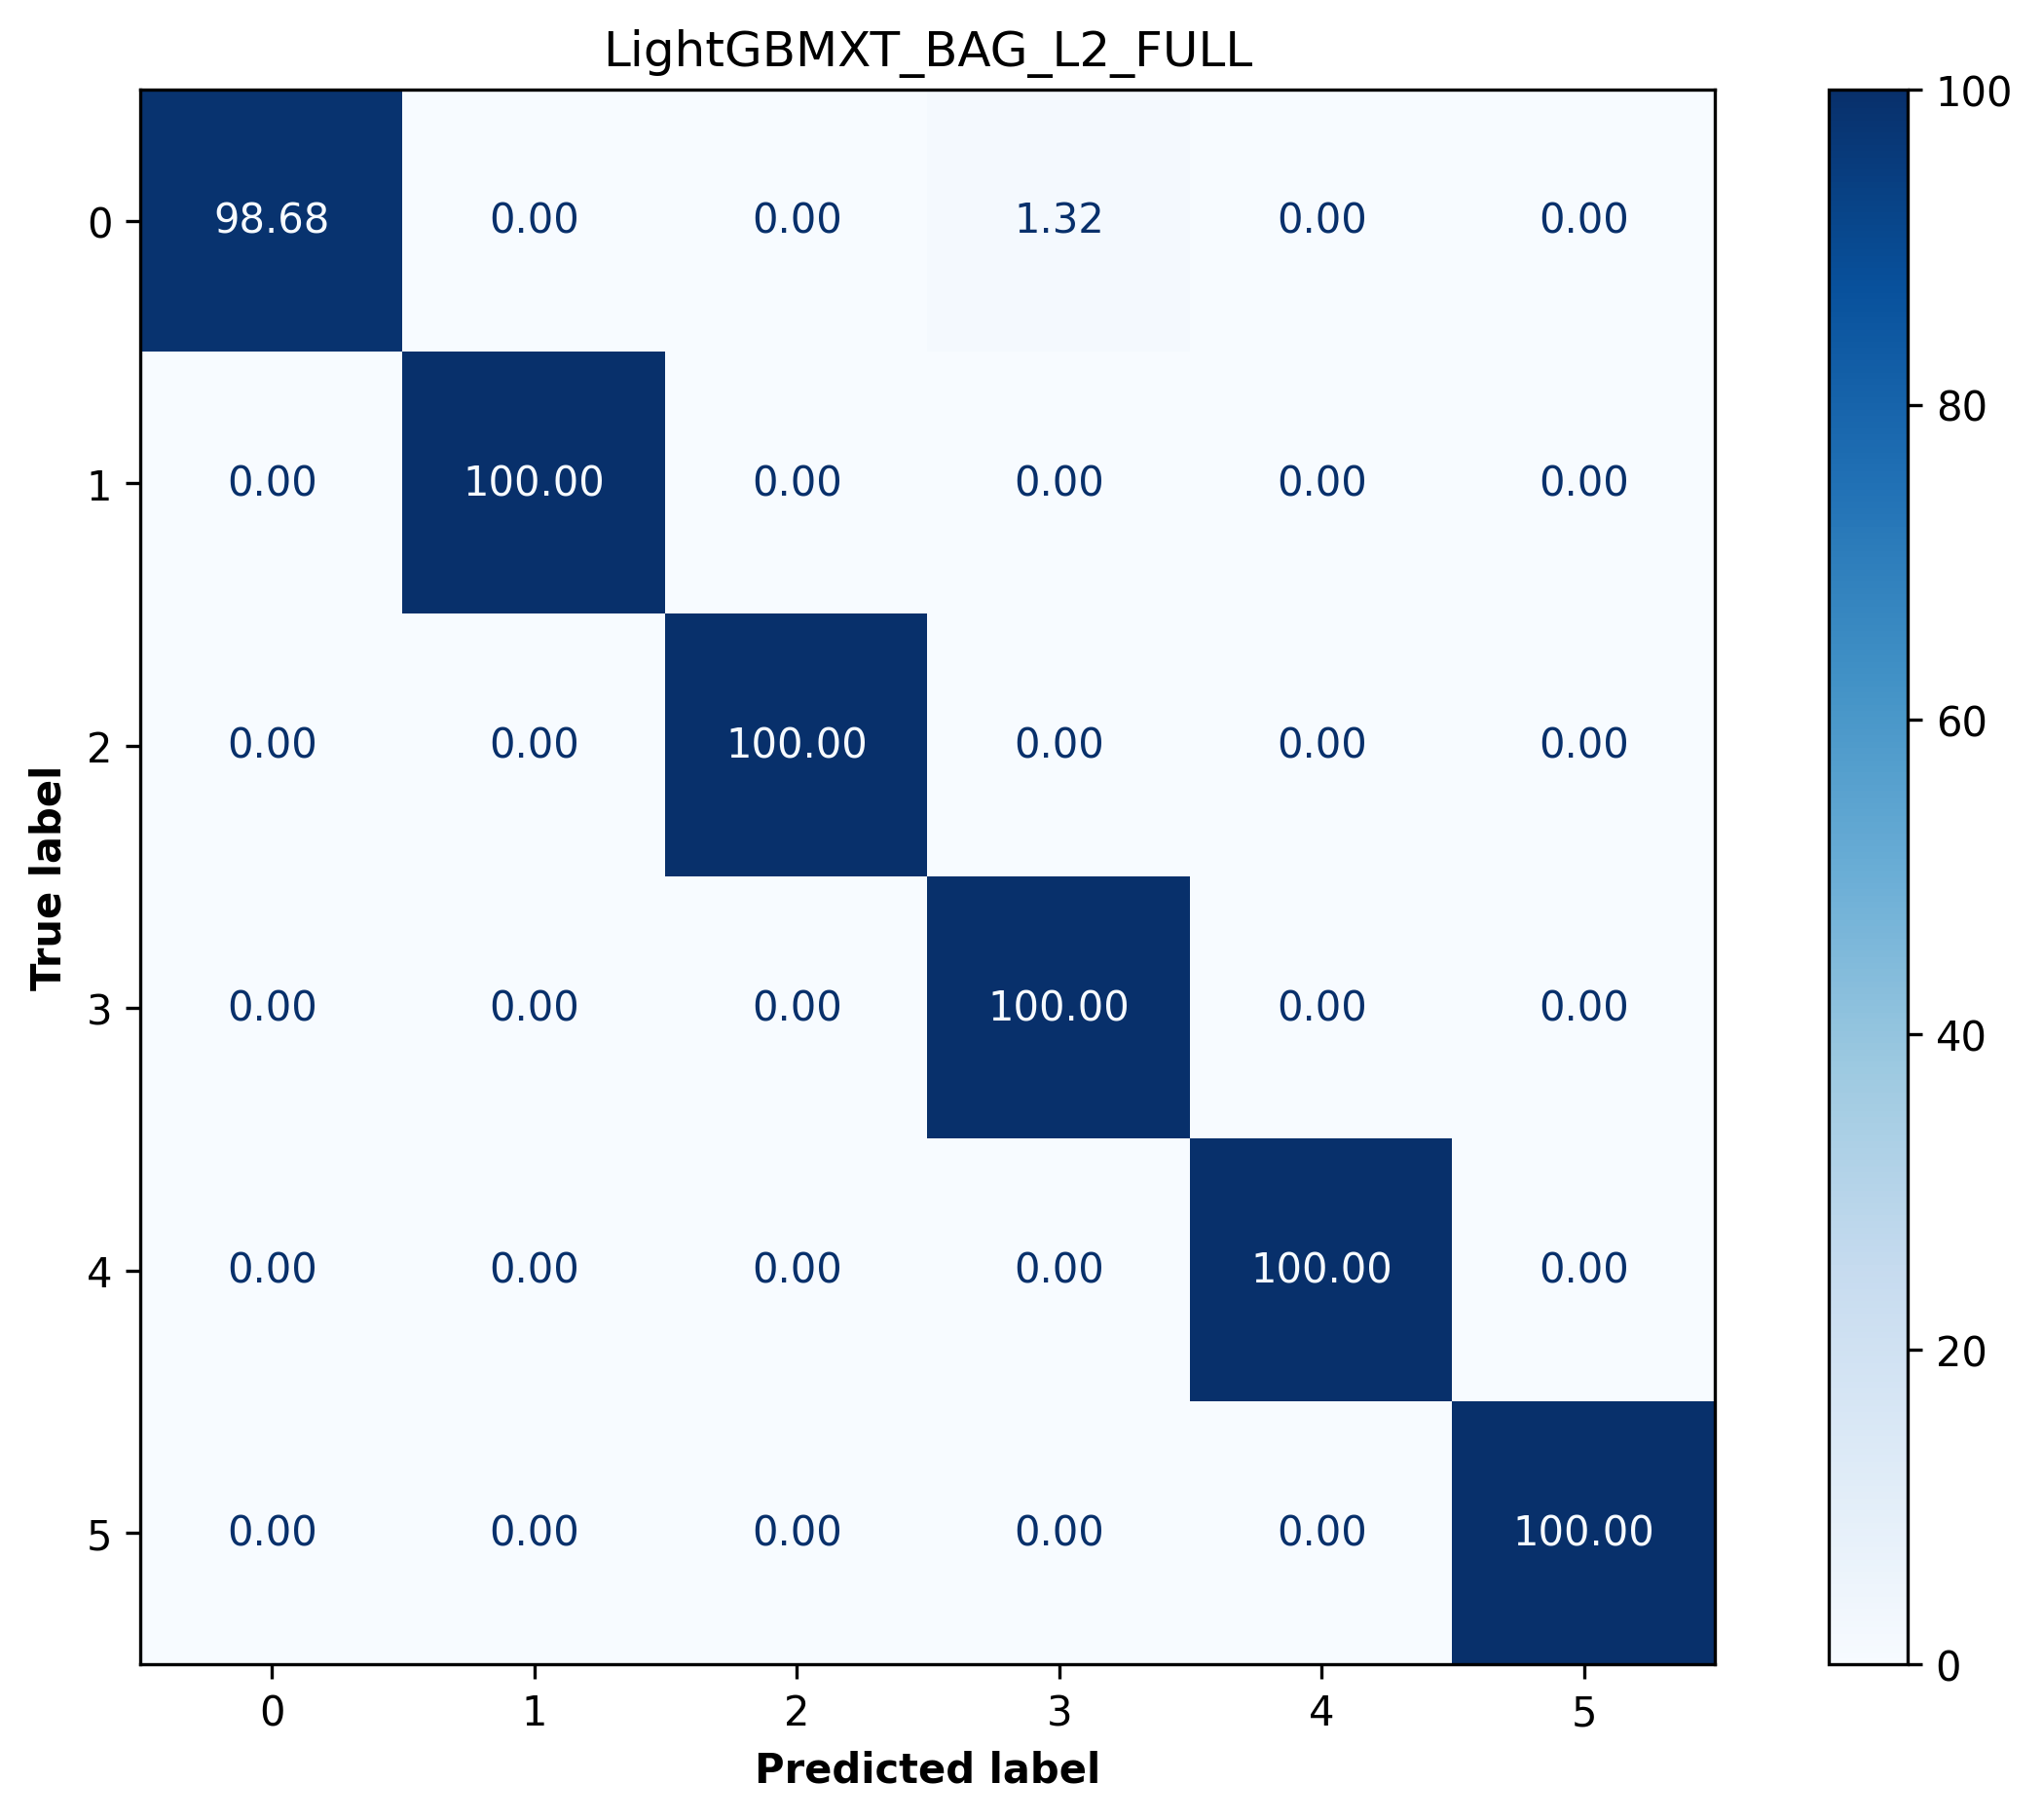

Model: NeuralNetFastAI_BAG_L1_FULL, Accuracy: 0.9636


/tmp/ipykernel_1140765/1530776312.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_df = combined_df.groupby(group_columns).agg({


,precision,recall,f1-score,support
0,0.985075,0.868421,0.923077,76.000000
1,1.000000,1.000000,1.000000,28.000000
2,1.000000,1.000000,1.000000,18.000000
3,0.892473,0.988095,0.937853,84.000000
4,1.000000,1.000000,1.000000,47.000000
5,1.000000,1.000000,1.000000,49.000000
accuracy,0.963576,0.963576,0.963576,0.963576
macro avg,0.979591,0.976086,0.976822,302.000000
weighted avg,0.966336,0.963576,0.963356,302.000000


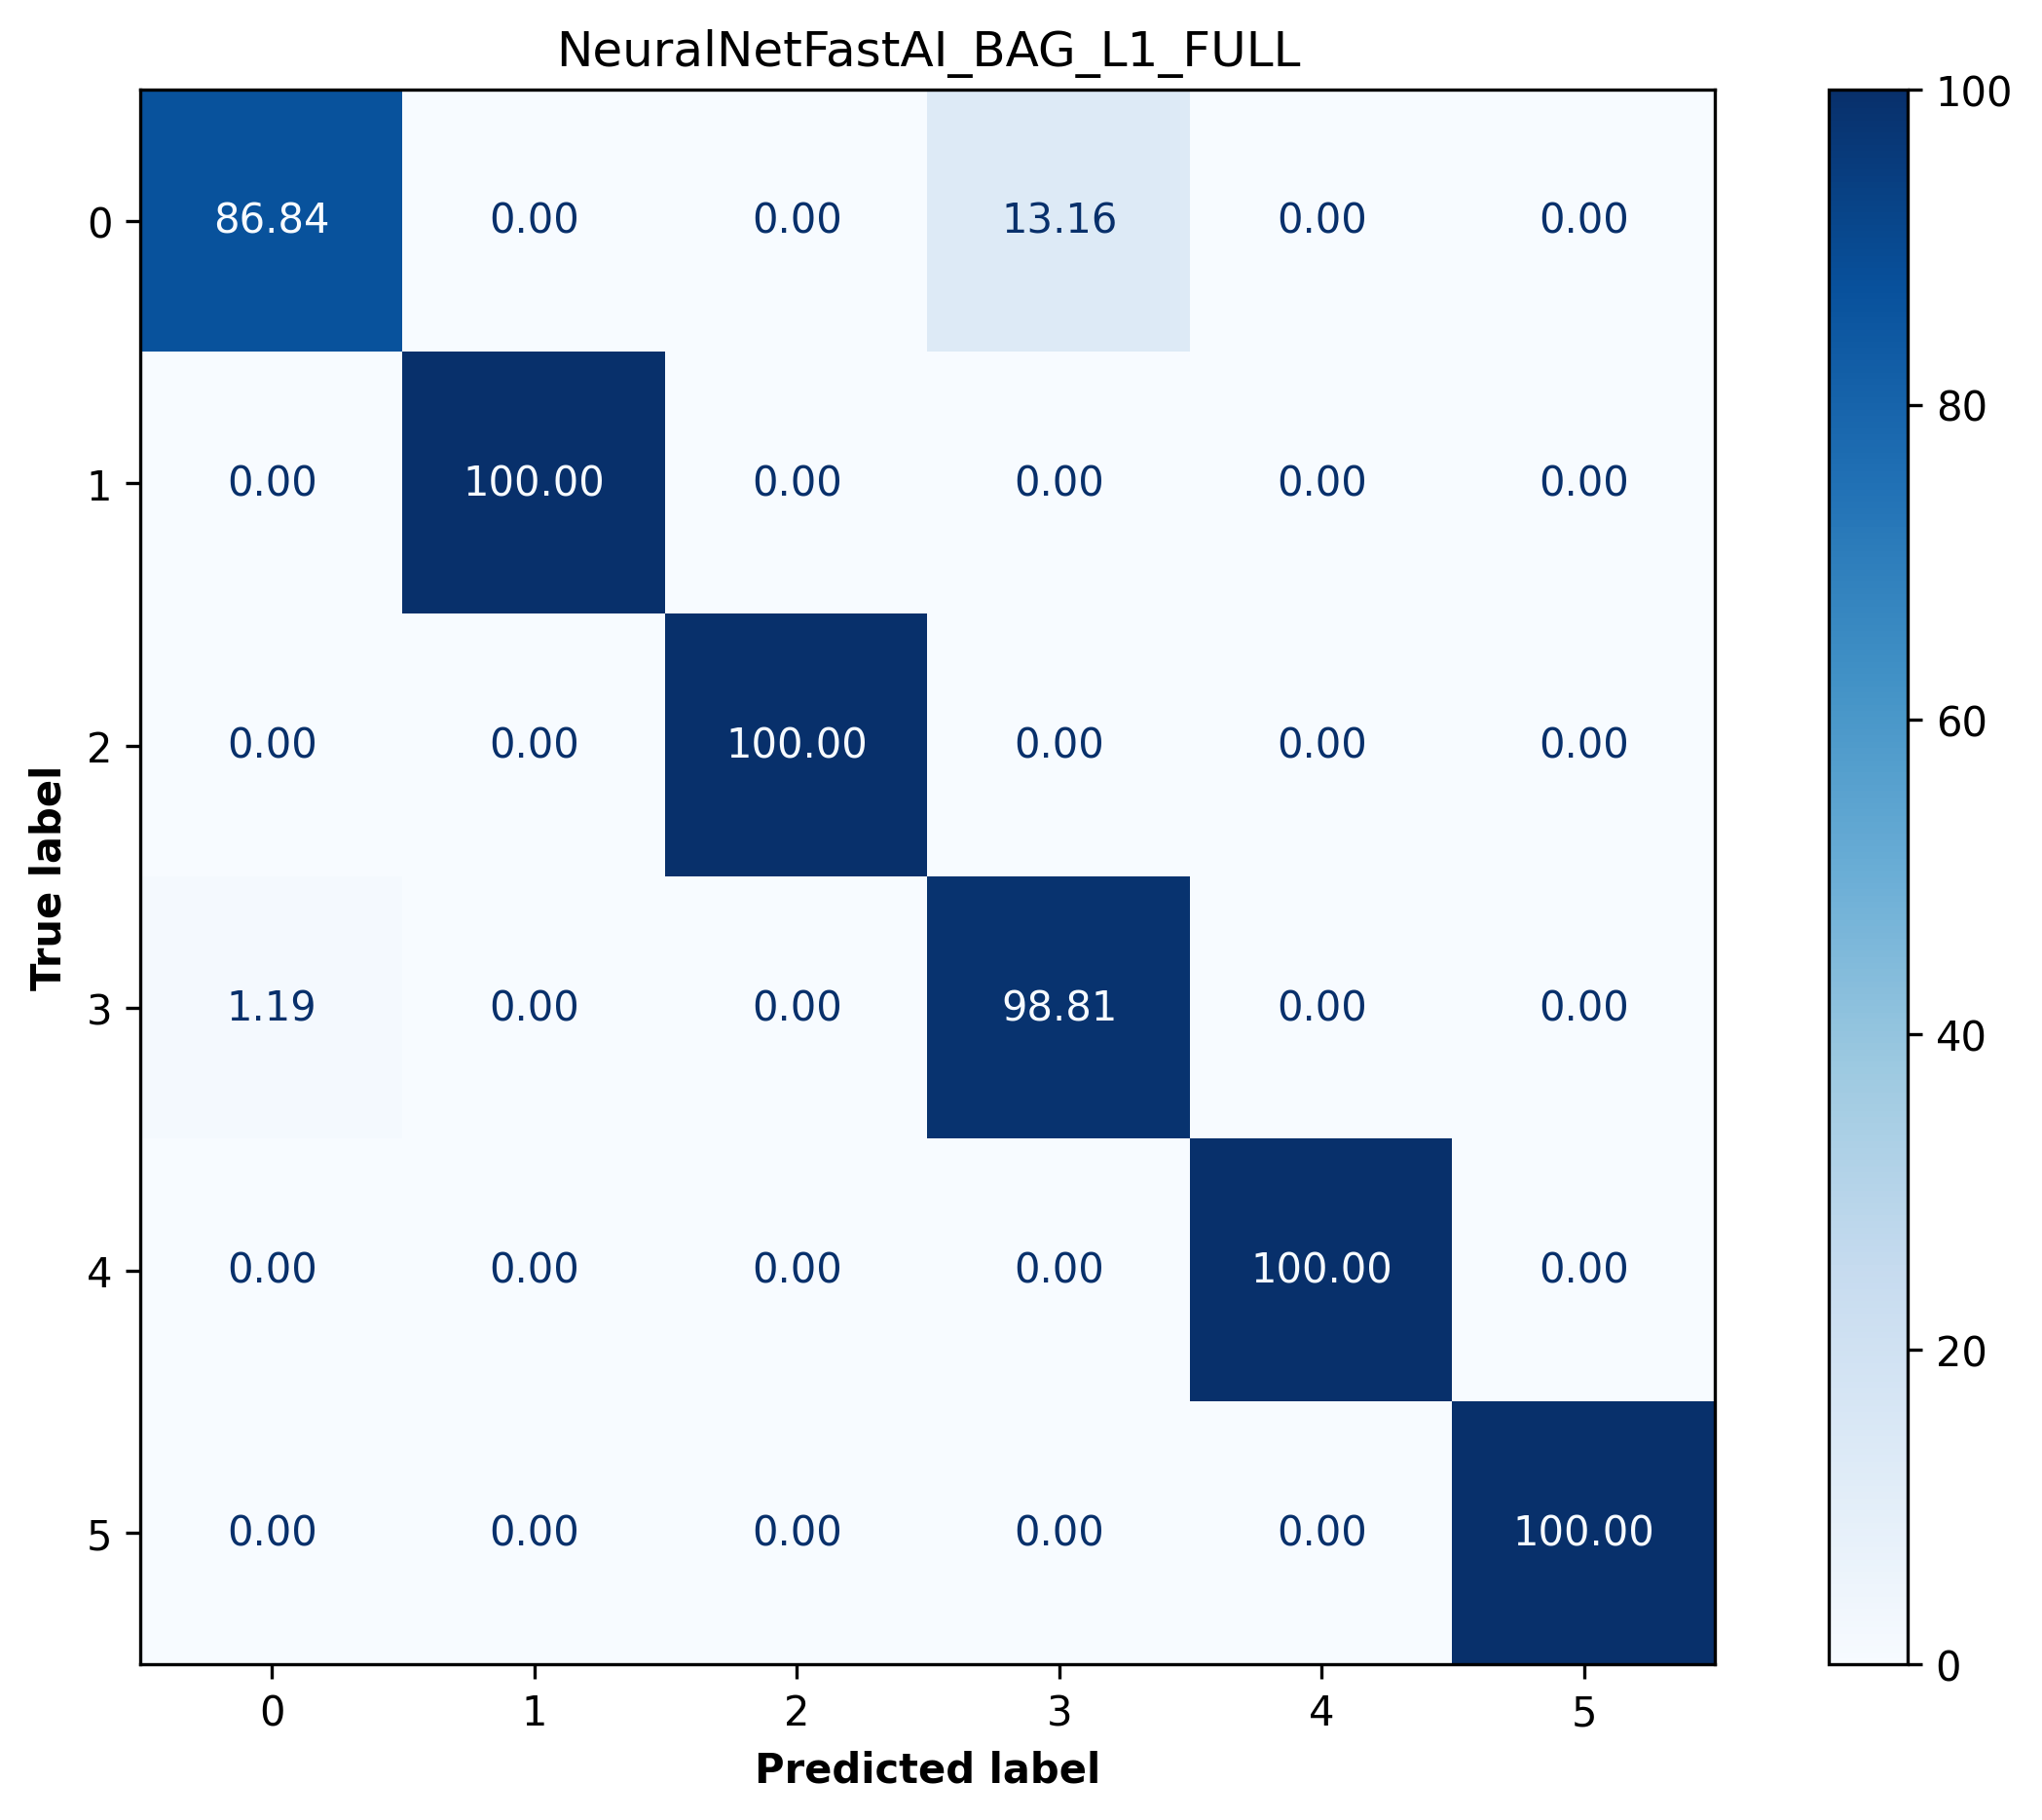

In [35]:
report_df_dino, profiles_df_dino = calculate_prediction_avg(joined_DINO_filt.to_pandas() , ["Metadata_Plate", "Metadata_Well", "Metadata_Site"], predictor_DINO, ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"], meta_dino)

Model: LightGBMXT_BAG_L2_FULL, Accuracy: 0.9272


/tmp/ipykernel_1140765/1530776312.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_df = combined_df.groupby(group_columns).agg({


,precision,recall,f1-score,support
0,0.817204,1.000000,0.899408,76.000000
1,1.000000,1.000000,1.000000,28.000000
2,0.947368,1.000000,0.972973,18.000000
3,1.000000,0.738095,0.849315,84.000000
4,0.921569,1.000000,0.959184,47.000000
5,1.000000,1.000000,1.000000,49.000000
accuracy,0.927152,0.927152,0.927152,0.927152
macro avg,0.947690,0.956349,0.946813,302.000000
weighted avg,0.938655,0.927152,0.924810,302.000000


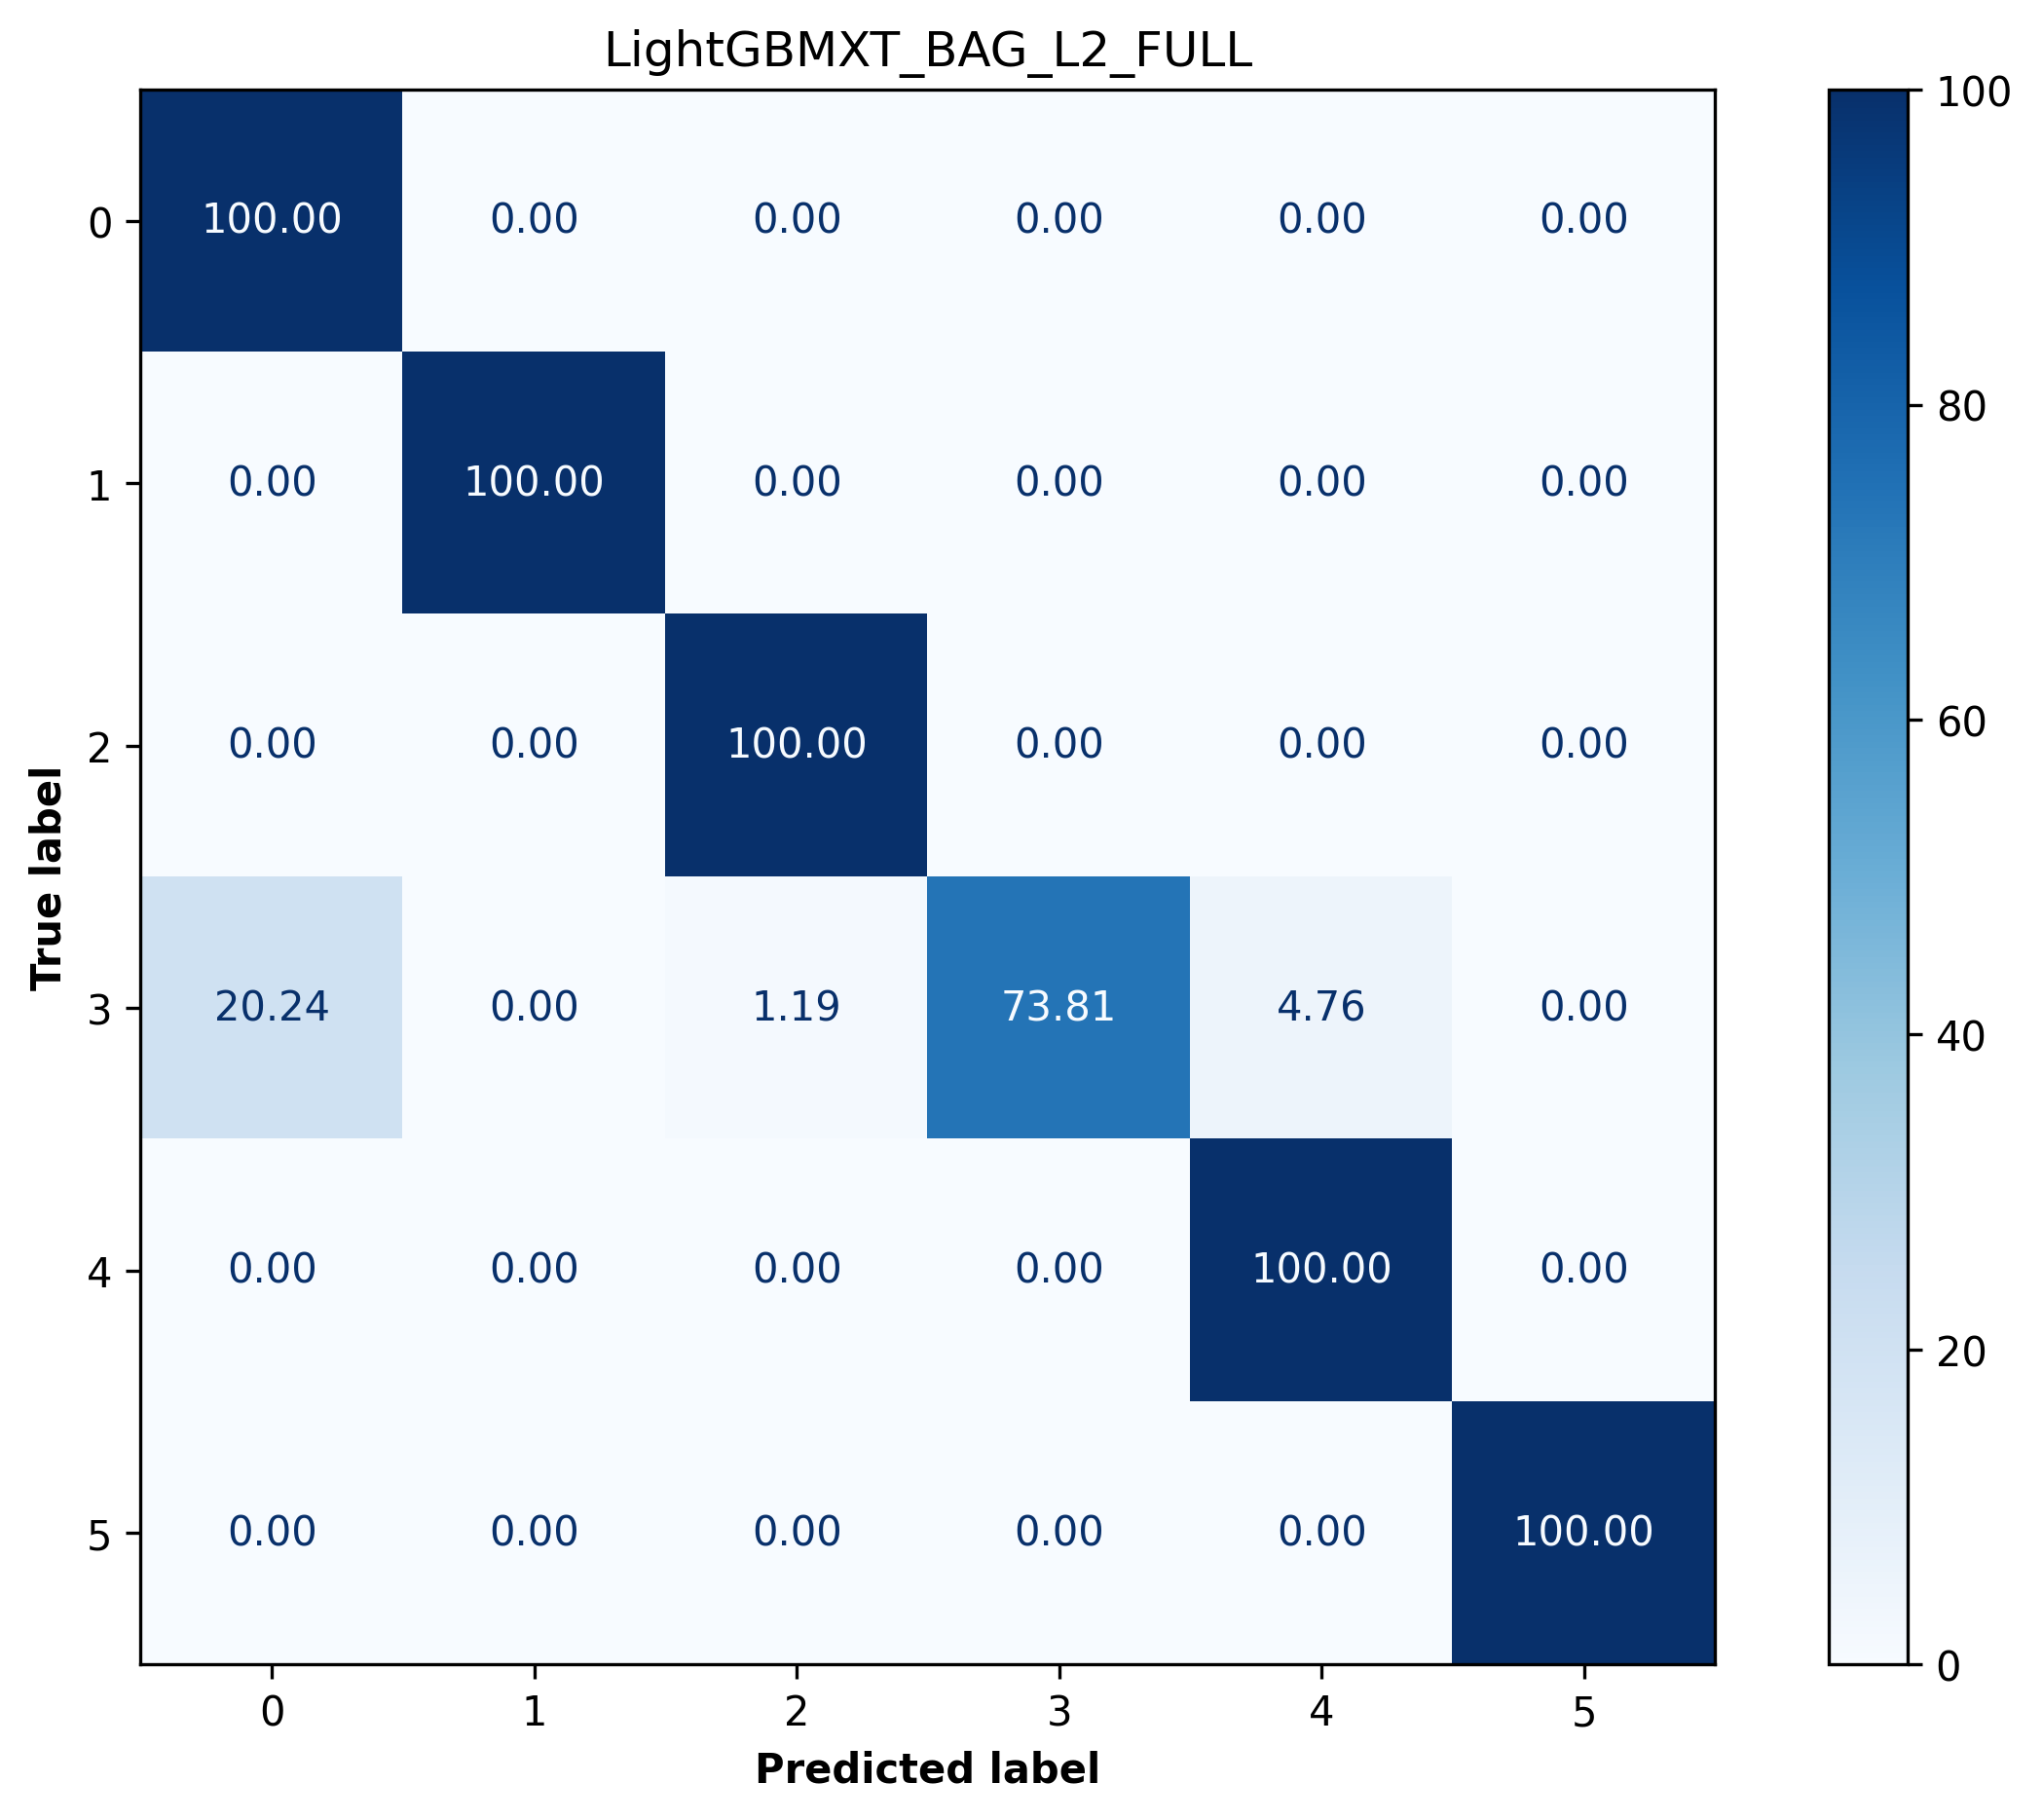

Model: NeuralNetFastAI_BAG_L1_FULL, Accuracy: 0.8642


/tmp/ipykernel_1140765/1530776312.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_df = combined_df.groupby(group_columns).agg({


,precision,recall,f1-score,support
0,0.728261,0.881579,0.797619,76.000000
1,0.923077,0.857143,0.888889,28.000000
2,0.666667,1.000000,0.800000,18.000000
3,0.933333,0.666667,0.777778,84.000000
4,0.979167,1.000000,0.989474,47.000000
5,1.000000,1.000000,1.000000,49.000000
accuracy,0.864238,0.864238,0.864238,0.864238
macro avg,0.871751,0.900898,0.875627,302.000000
weighted avg,0.882831,0.864238,0.863399,302.000000


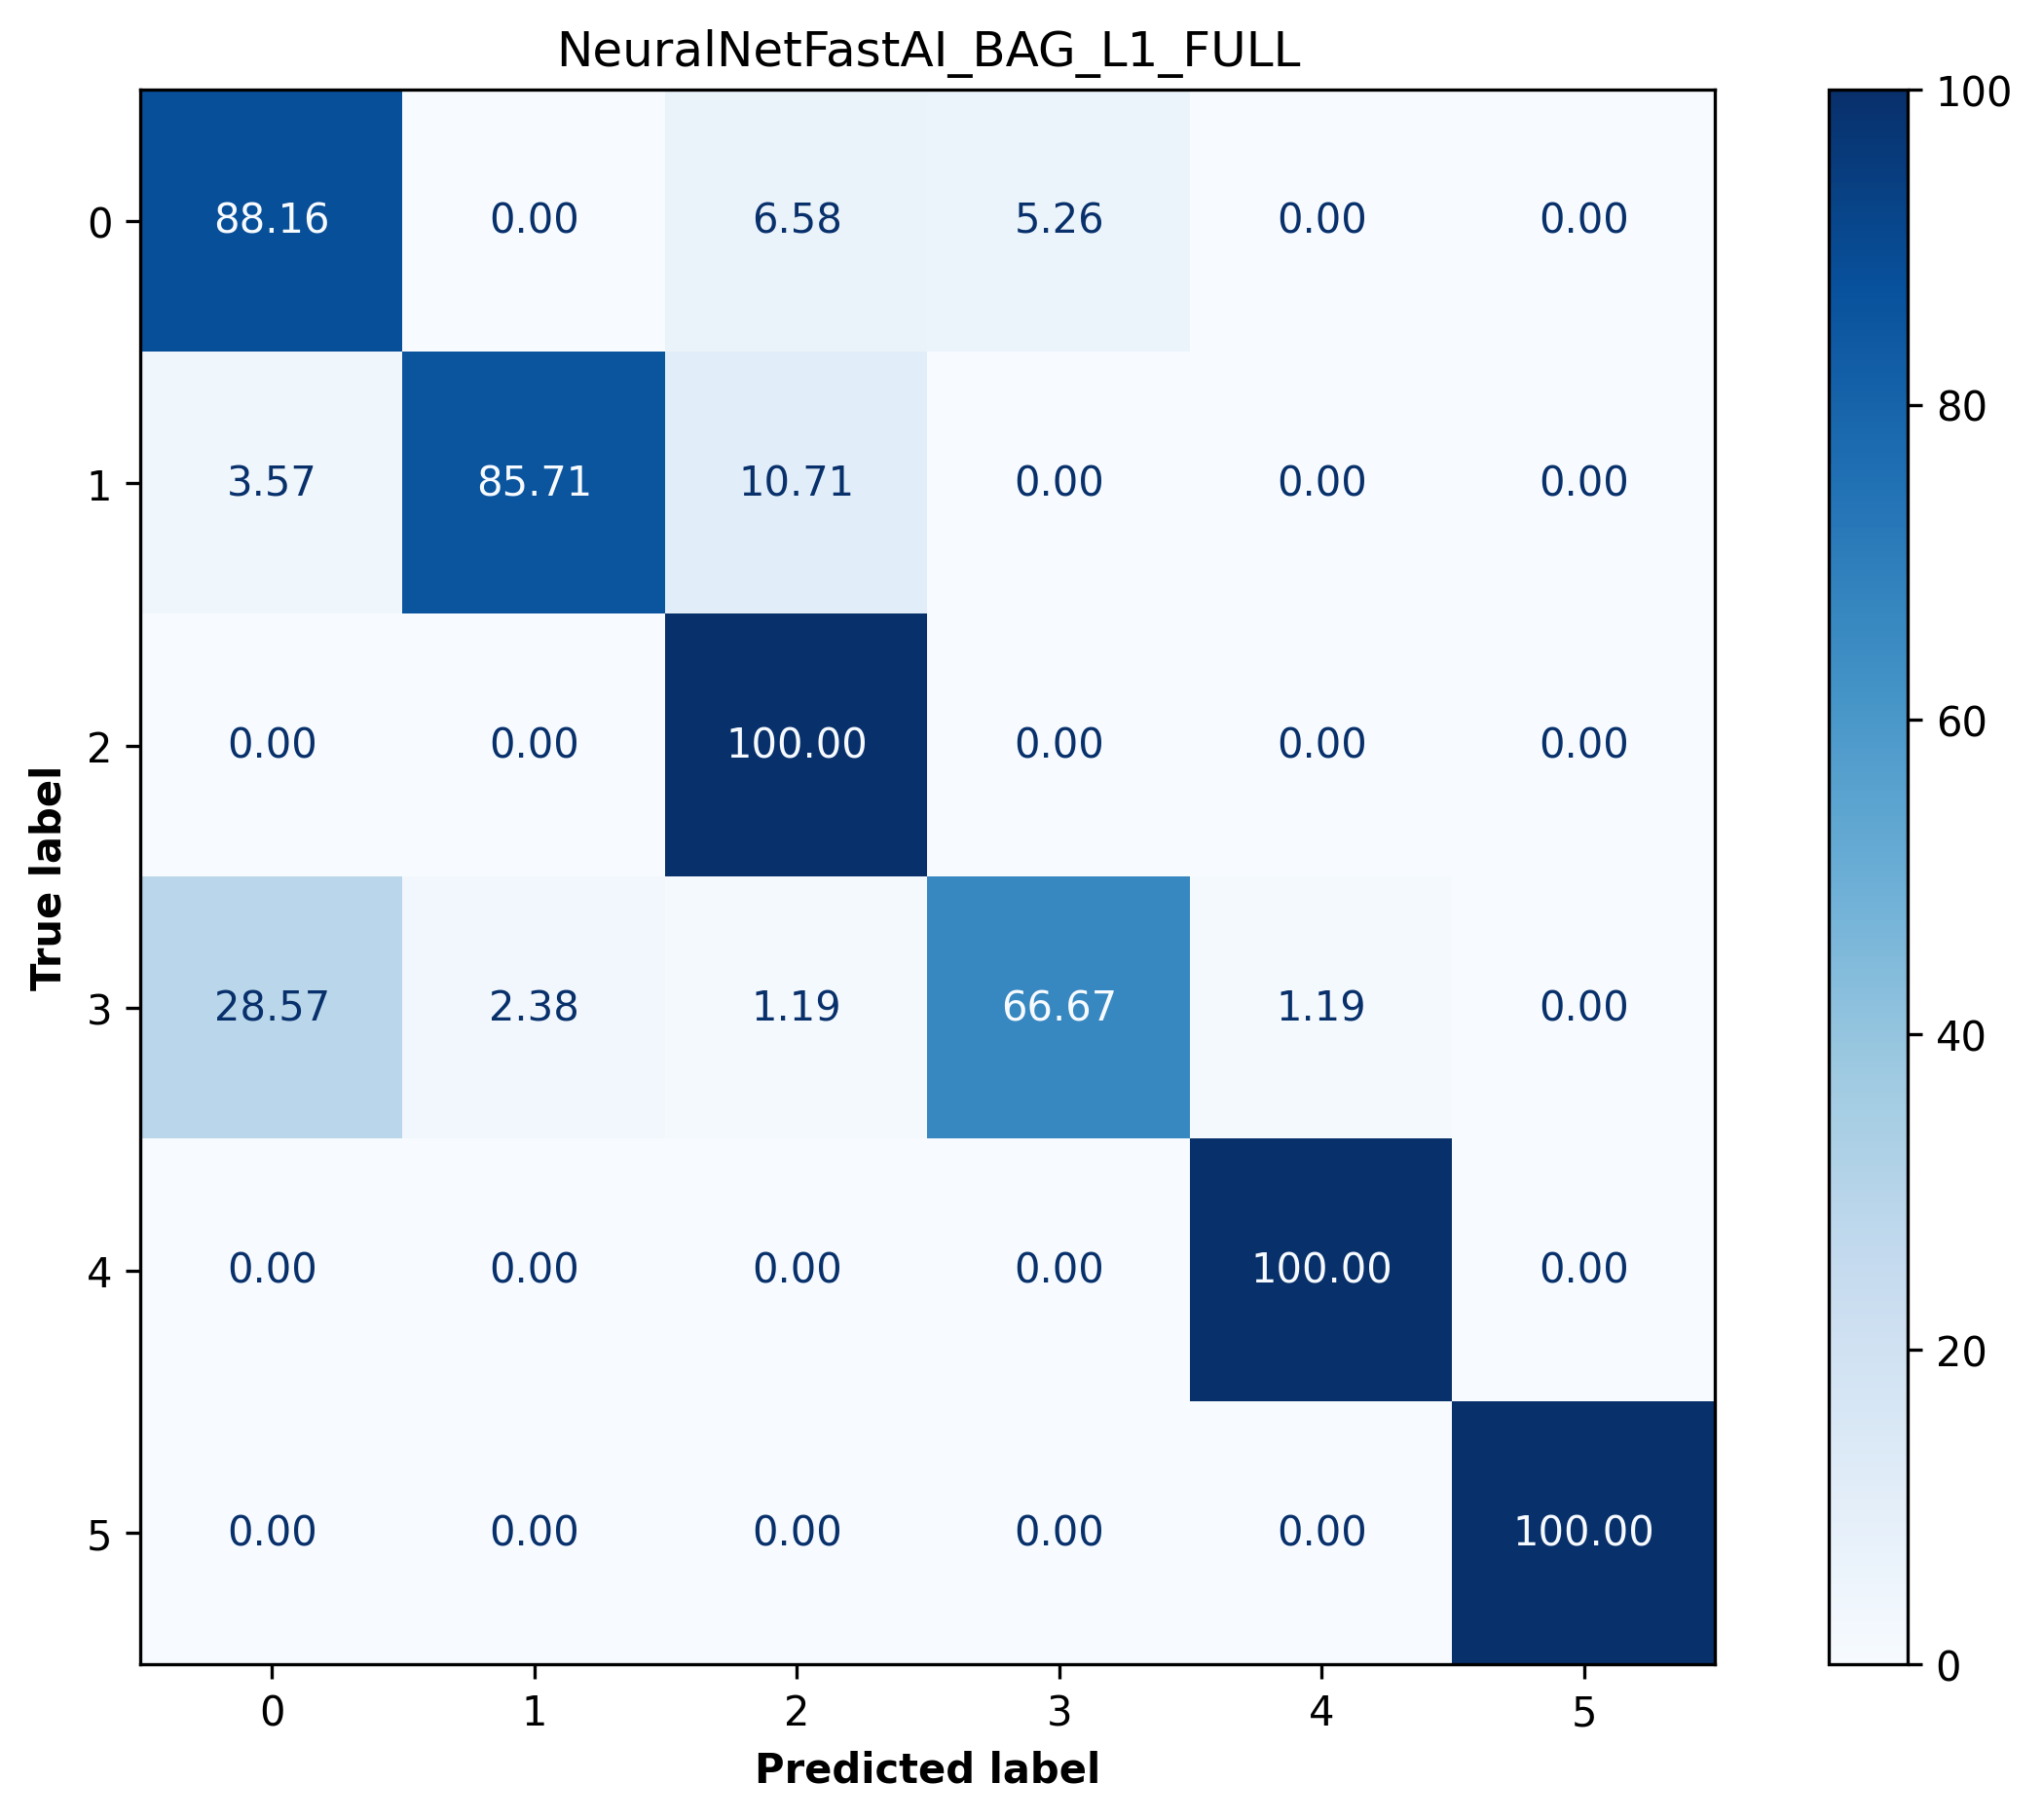

In [36]:
report_df_CP, profiles_df_CP = calculate_prediction_avg(joined_CP_filt.to_pandas(), ["Metadata_Plate", "Metadata_Well", "Metadata_Site"], predictor_CP, ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"], meta_cp)

Model: LightGBMXT_BAG_L2_FULL, Accuracy: 0.9503


/tmp/ipykernel_1140765/1530776312.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_df = combined_df.groupby(group_columns).agg({


,precision,recall,f1-score,support
0,0.894118,1.000000,0.944099,76.000000
1,0.875000,1.000000,0.933333,28.000000
2,1.000000,0.944444,0.971429,18.000000
3,0.973684,0.880952,0.925000,84.000000
4,1.000000,1.000000,1.000000,47.000000
5,1.000000,0.918367,0.957447,49.000000
accuracy,0.950331,0.950331,0.950331,0.950331
macro avg,0.957134,0.957294,0.955218,302.000000
weighted avg,0.954445,0.950331,0.950283,302.000000


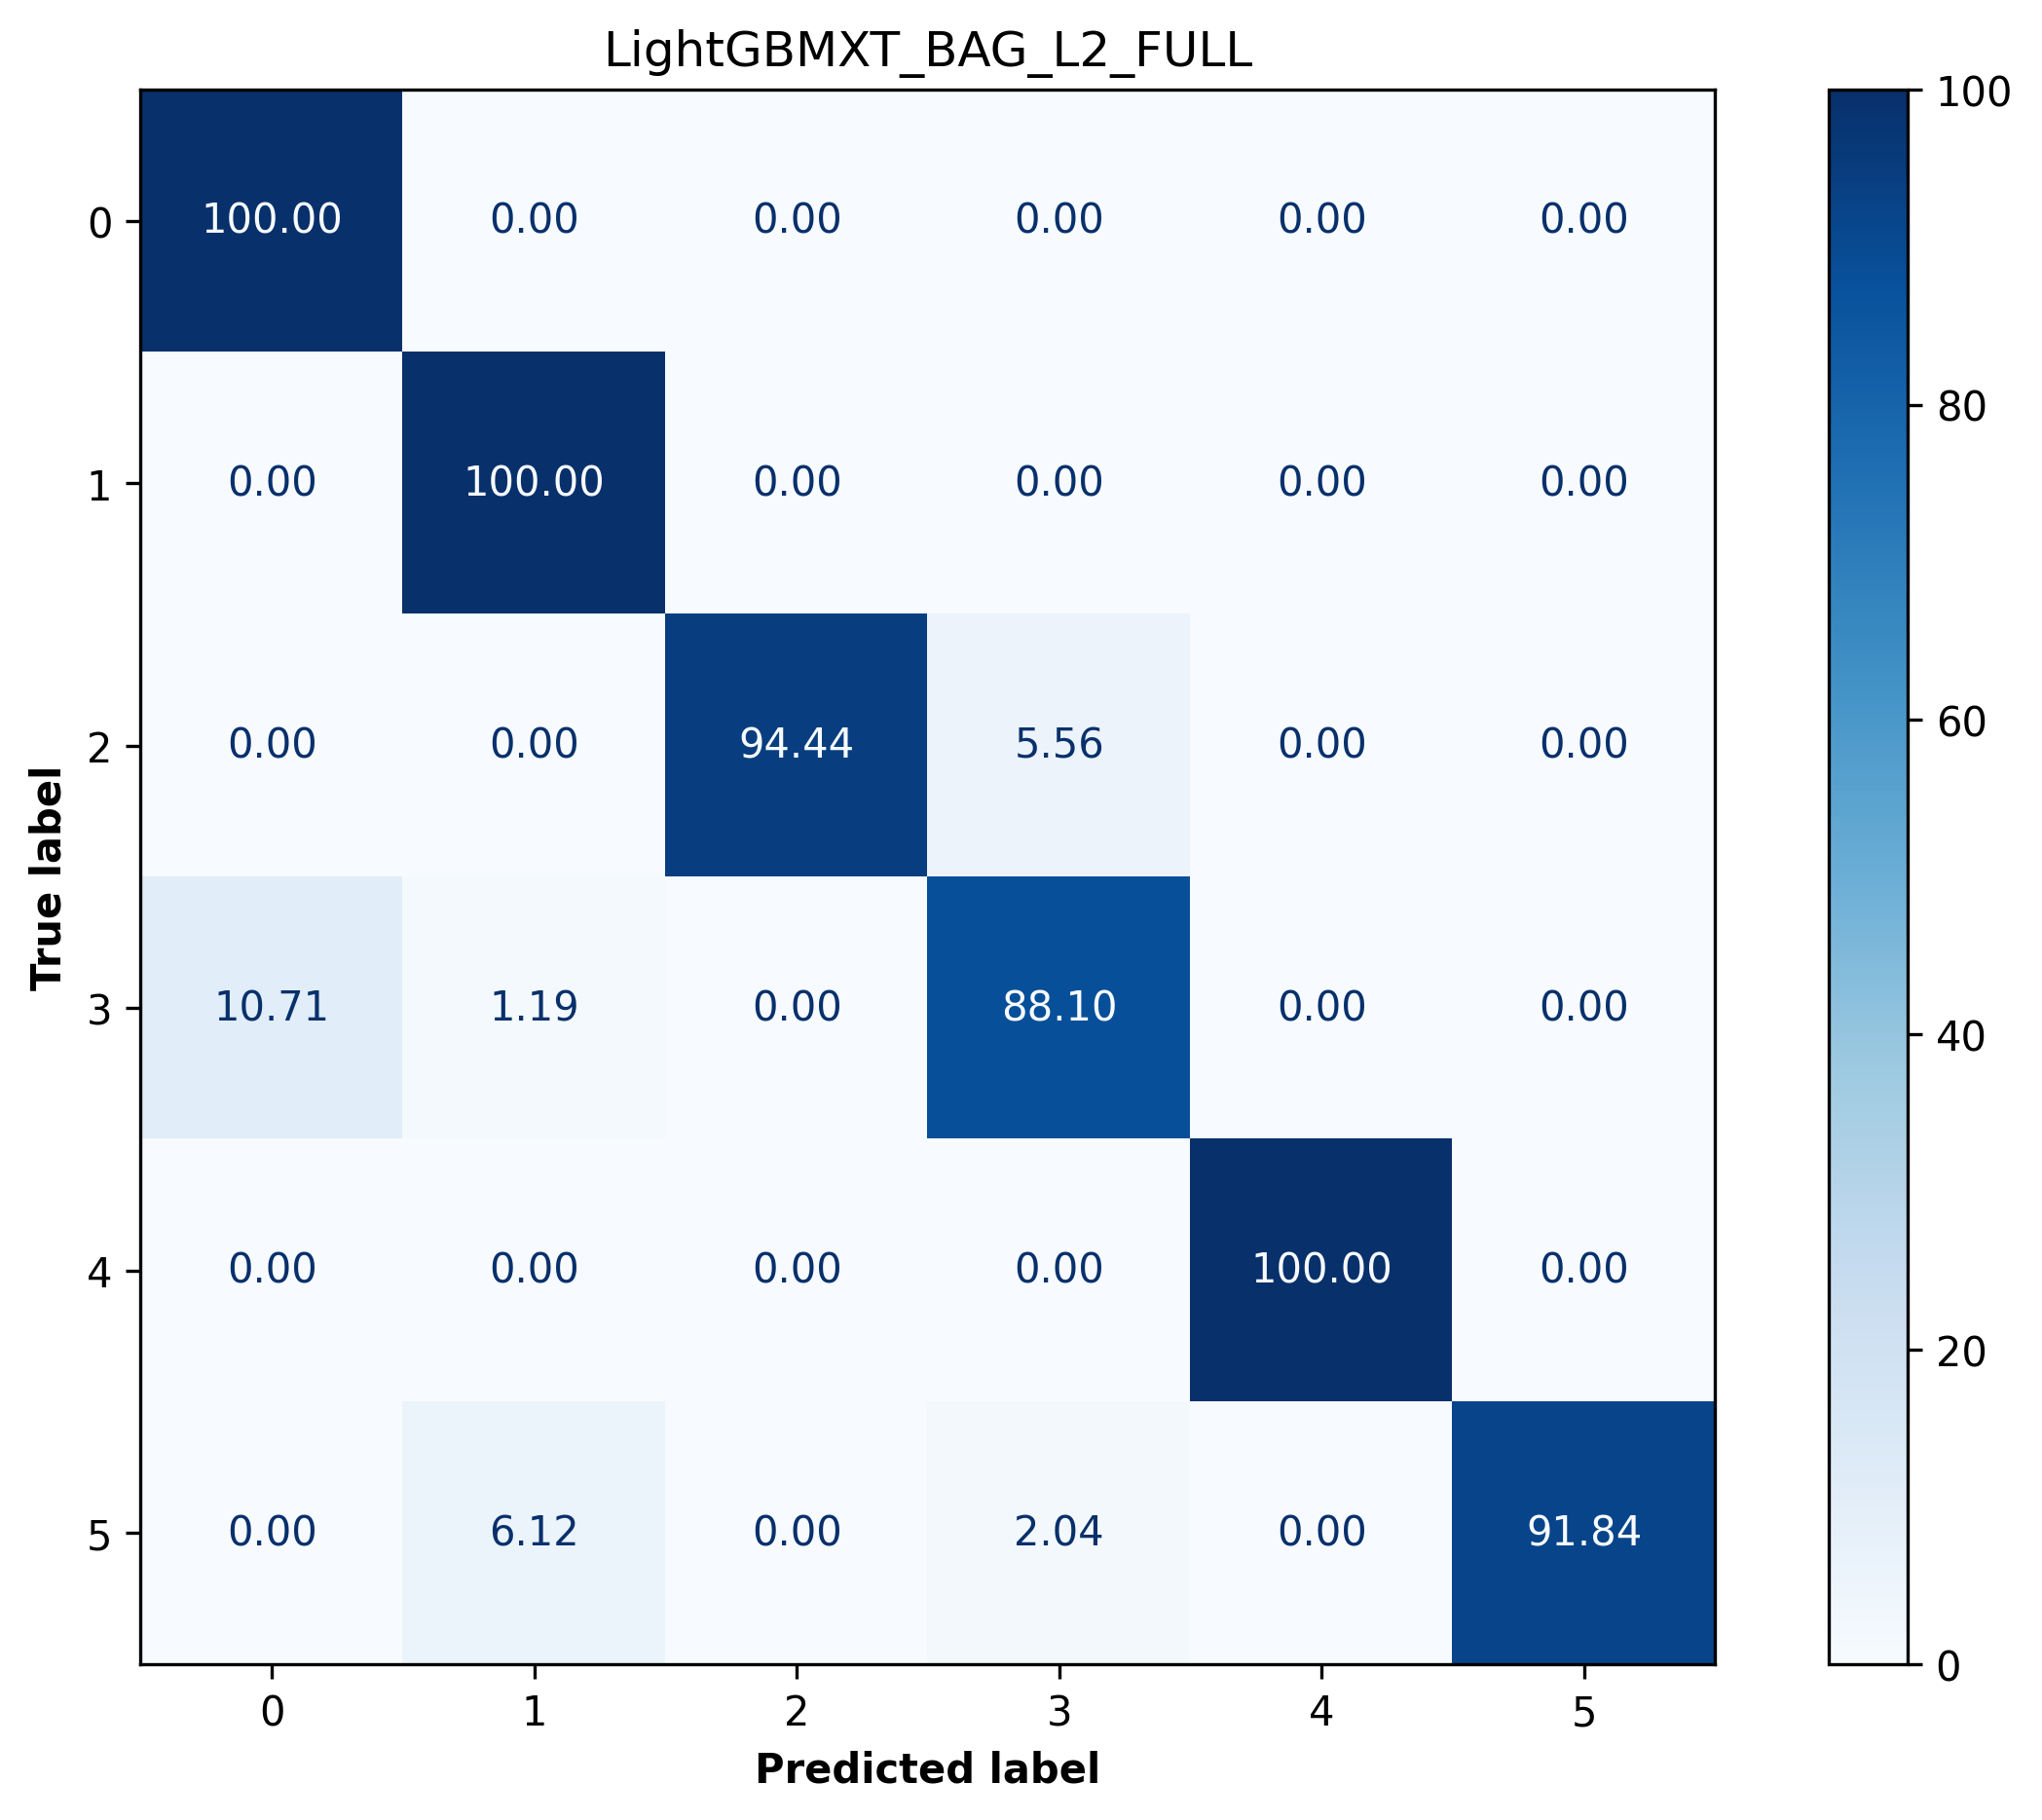

Model: NeuralNetFastAI_BAG_L1_FULL, Accuracy: 0.8576


/tmp/ipykernel_1140765/1530776312.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_df = combined_df.groupby(group_columns).agg({


,precision,recall,f1-score,support
0,0.691589,0.973684,0.808743,76.000000
1,0.848485,1.000000,0.918033,28.000000
2,0.944444,0.944444,0.944444,18.000000
3,0.942308,0.583333,0.720588,84.000000
4,0.979167,1.000000,0.989474,47.000000
5,1.000000,0.897959,0.946237,49.000000
accuracy,0.857616,0.857616,0.857616,0.857616
macro avg,0.900999,0.899904,0.887920,302.000000
weighted avg,0.885738,0.857616,0.852880,302.000000


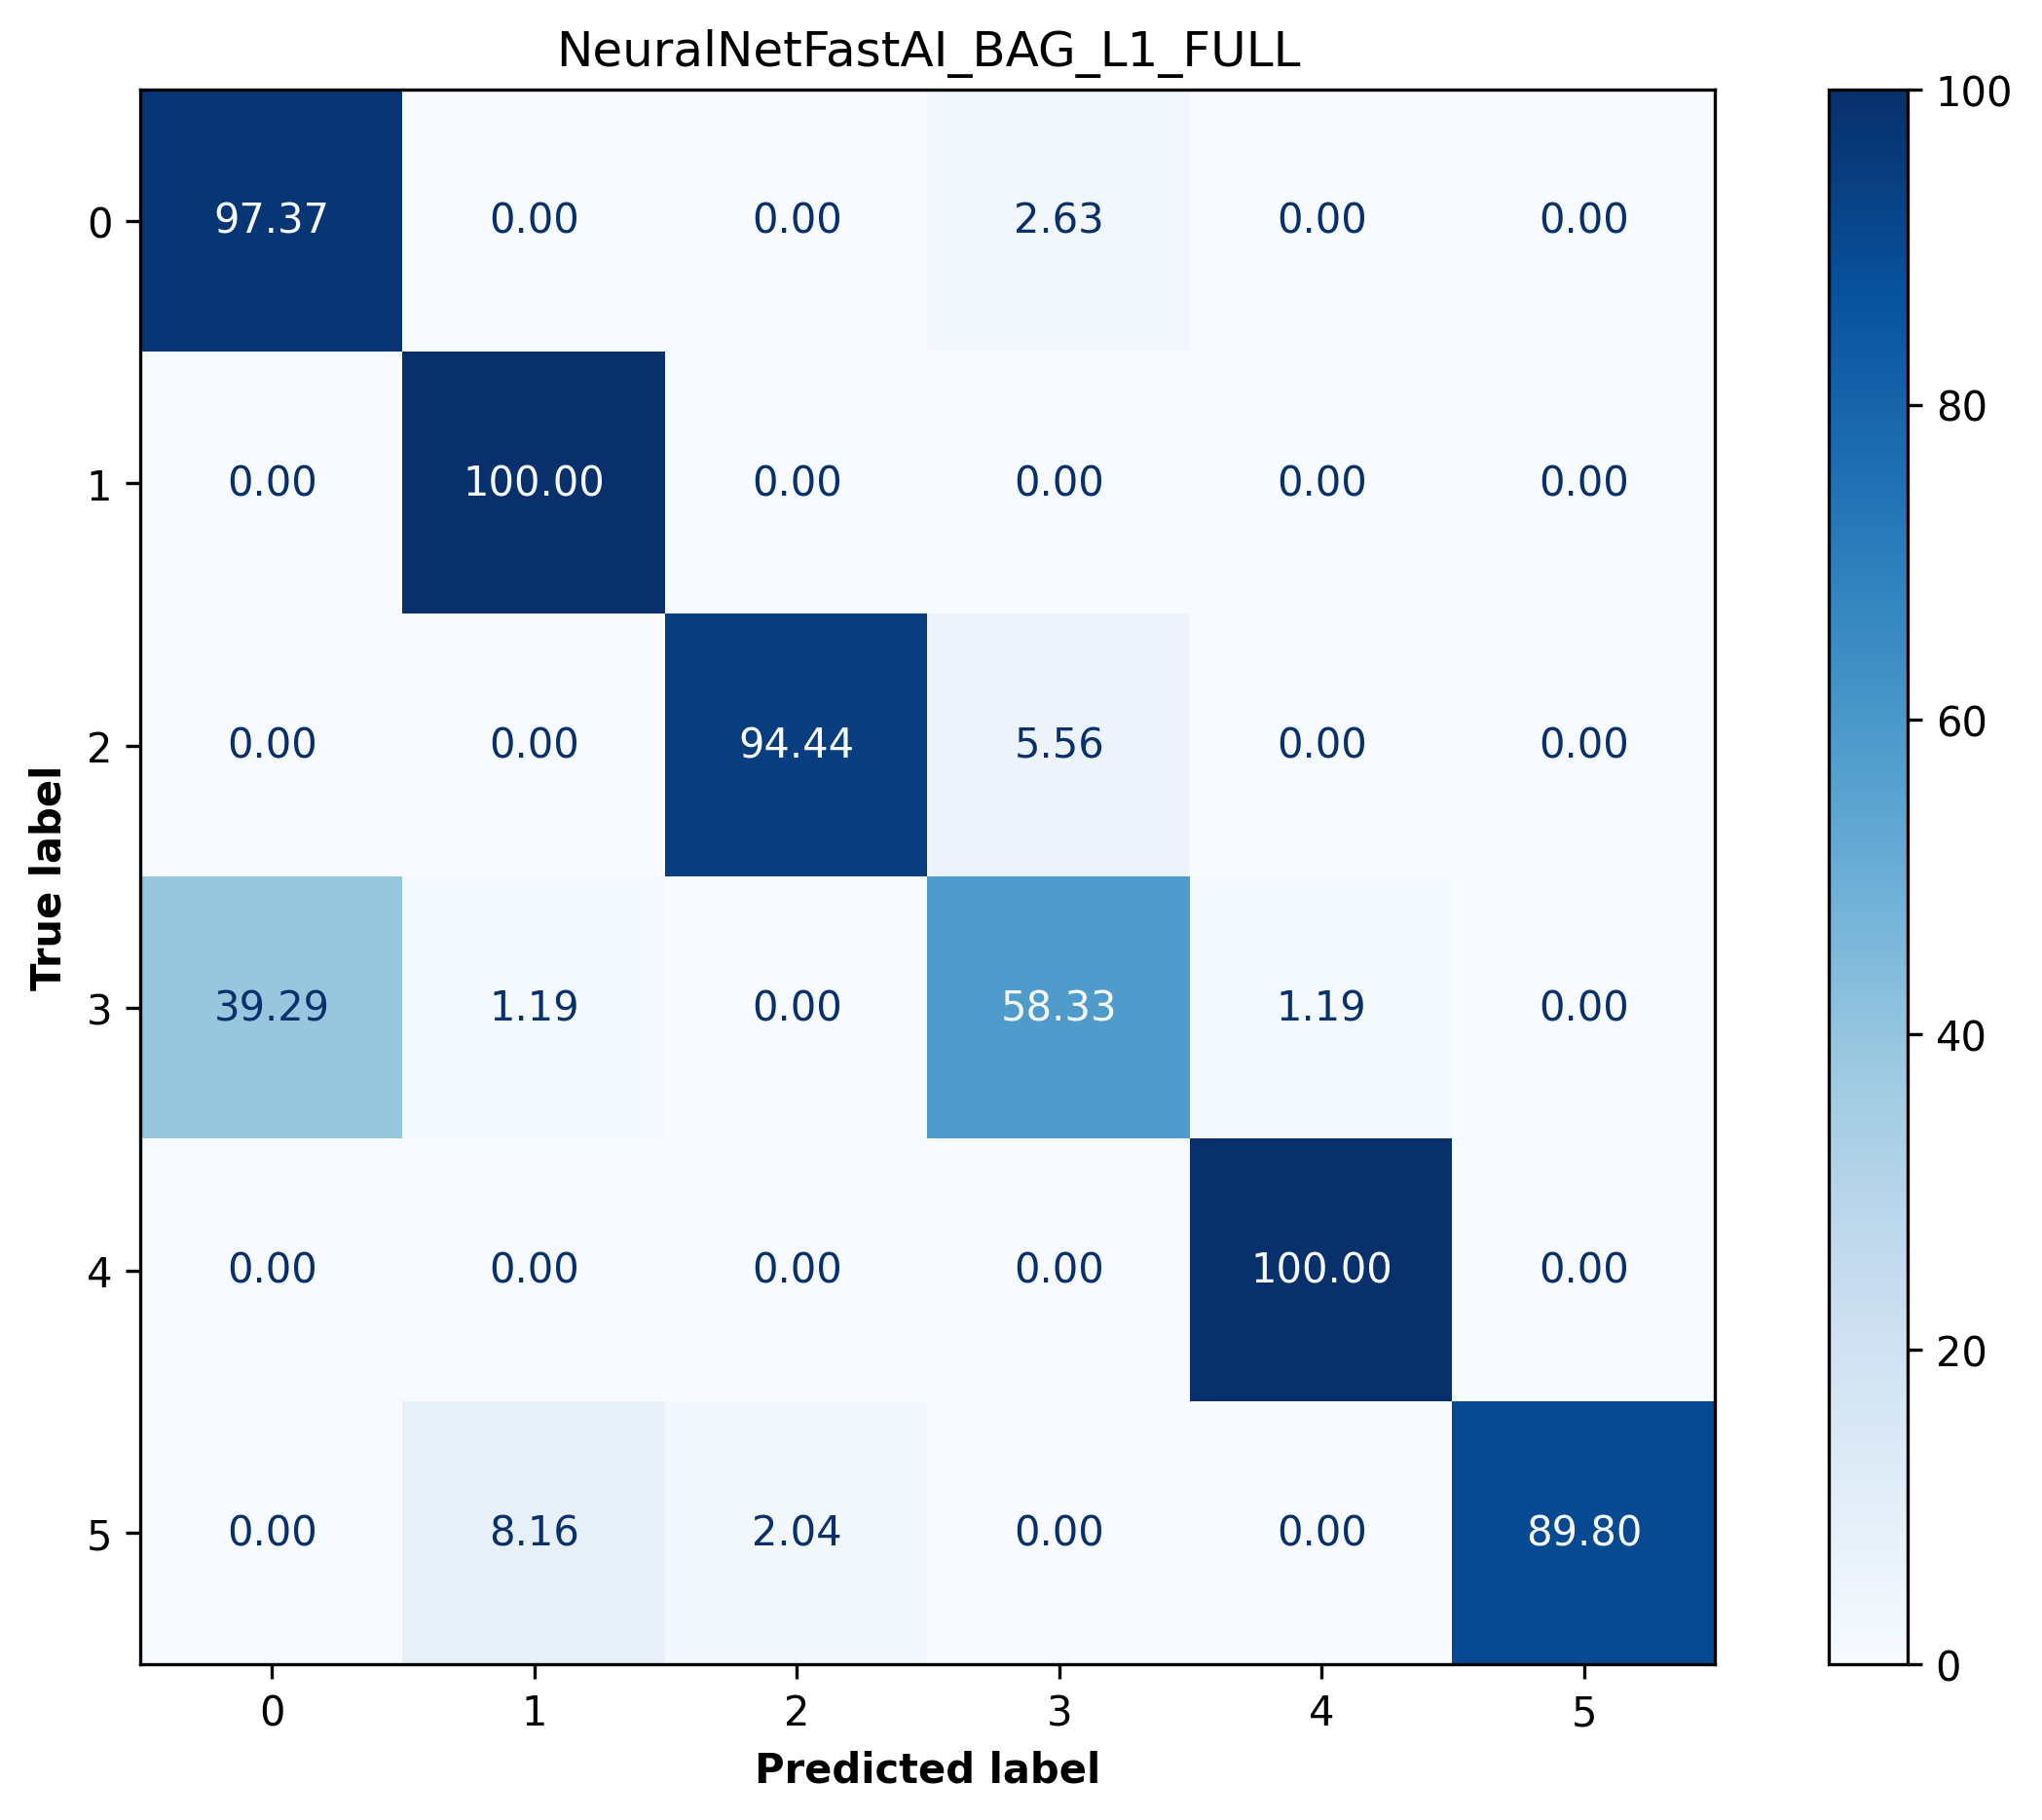

In [37]:
report_df_DP, profiles_df_DP = calculate_prediction_avg(joined_DP_filt.to_pandas(), ["Metadata_Plate", "Metadata_Well", "Metadata_Site"], predictor_DP, ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"], meta_DP)

In [38]:
def generate_confusion_matrices(predictors, datasets, models_list, metadata_feats_list, group_columns, majority_vote=False):
    """
    Generate confusion matrices for a list of predictors and datasets.

    Parameters:
    - predictors: list of AutoGluon predictors
    - datasets: list of feature datasets
    - models_list: list of model names to evaluate
    - metadata_feats_list: list of metadata column lists (one per dataset)
    - group_columns: columns to group by when doing majority vote
    - majority_vote: whether to apply majority voting strategy

    Returns:
    - confusion_matrices: List of lists, shape (models x features)
    - model_labels: List of model names (for rows)
    - feature_labels: List of feature extractor names (for columns)
    """
    confusion_matrices = []
    model_labels = []
    feature_labels = []

    int_labels = sorted(label_codes.keys())

    for model in models_list:
        model_row_matrices = []

        for predictor, data, metadata_feats in zip(predictors, datasets, metadata_feats_list):
            print(f"Evaluating {model}")
            meta_df = data[metadata_feats]
            X_test = data[[feat for feat in  data.columns if feat not in metadata_feats]]

            if majority_vote:
                # ------------- Majority Voting Strategy -------------
                # Predict per single-cell
                y_pred_single = predictor.predict(X_test, model=model)
                y_pred_single = pd.Series(y_pred_single, index=X_test.index)

                # Combine predictions with metadata
                combined_df = pd.concat([y_pred_single.rename("predicted_label"), meta_df], axis=1)

                # Majority vote per group
                grouped = combined_df.groupby(group_columns).agg({
                    "predicted_label": lambda x: Counter(x).most_common(1)[0][0],
                    **{col: "first" for col in meta_df.columns if col not in group_columns}
                }).reset_index()

                # Get majority voted predictions and corresponding true labels
                y_pred_majority = grouped["predicted_label"]
                y_true_majority = grouped["moa"]

                # Map
                y_true_mapped = y_true_majority.map(string_to_int)
                y_pred_mapped = y_pred_majority.map(string_to_int)

            else:
                # ------------- Single-cell Strategy -------------
                y_pred = predictor.predict(X_test, model=model)
                y_true = data["moa"]

                # Map
                y_true_mapped = y_true.map(string_to_int)
                y_pred_mapped = pd.Series(y_pred).map(string_to_int)


            # Clean invalid entries
            valid_idx = (~y_true_mapped.isna()) & (~y_pred_mapped.isna())
            y_true_mapped = y_true_mapped[valid_idx]
            y_pred_mapped = y_pred_mapped[valid_idx]

            # Compute confusion matrix
            cm = confusion_matrix(y_true_mapped, y_pred_mapped, labels=int_labels)
            cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
            model_row_matrices.append(cm_percentage)

        confusion_matrices.append(model_row_matrices)

    # Labels
    model_labels = models_list
    feature_labels = ["CellProfiler", "DeepProfiler", "DINO"]

    return confusion_matrices, model_labels, feature_labels


import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_grid(confusion_matrices, model_labels, feature_labels, title="Confusion Matrices", normalize=True):
    """
    Plot a grid of confusion matrices.

    confusion_matrices: list of list of matrices. Outer list = models, Inner list = feature extractors.
    model_labels: labels for each row (model)
    feature_labels: labels for each column (feature extractor)
    """

    n_rows = len(model_labels)
    n_cols = len(feature_labels)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), dpi=300)

    # If axes is 1D (only one row or one column), expand it to 2D
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)
    if n_cols == 1:
        axes = np.expand_dims(axes, axis=1)

    # Flatten the confusion matrices and get global min/max for uniform color scaling
    all_cm_values = np.concatenate([cm.flatten() for row in confusion_matrices for cm in row])
    vmin = 0
    vmax = all_cm_values.max()

    for i in range(n_rows):
        for j in range(n_cols):
            cm = confusion_matrices[i][j]
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4,5])
            disp.plot(ax=axes[i, j], cmap="Blues", values_format=".2f", colorbar=False)

            for text in axes[i, j].texts:
                text.set_fontsize(7)  # ← Set this smaller (e.g., 6, 7, 8)
            if i == 0:
                axes[i, j].set_title(feature_labels[j], fontsize=12, fontweight="bold")
            axes[i, j].set_xlabel("Predicted", fontsize=8)
            axes[i, j].set_ylabel("True", fontsize=8)

    # Set row labels (models)
    for ax, row_label in zip(axes[:,0], model_labels):
        ax.set_ylabel(row_label, rotation=90, size=10, fontweight="bold", labelpad=20)

    # Add single shared colorbar
    im = axes[0,0].collections[0]
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, orientation="vertical", pad=0.02)

    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



In [39]:
def generate_confusion_matrices_agg(predictors, datasets, models_list, metadata_feats_list, group_columns, majority_vote=False):
    """
    Generate confusion matrices for a list of predictors and datasets.

    Returns:
    - confusion_matrices: List of lists, shape (models x features)
    - model_labels: List of model names (for rows)
    - feature_labels: List of feature extractor names (for columns)
    """
    confusion_matrices = []
    model_labels = []
    feature_labels = ["CellProfiler", "DeepProfiler", "DINO"]

    int_labels = [0, 1, 2, 3, 4, 5]
    string_to_int = {
        'necroptosis inducer': 4,
        'autophagy inducer': 1,
        'ferroptosis inducer': 2,
        'immunogenic cell death': 3,
        'apoptosis': 0,
        'pyroptosis inducer': 5
    }

    for model in models_list:
        model_row_matrices = []

        for i, (predictor, data, metadata_feats) in enumerate(zip(predictors, datasets, metadata_feats_list)):
            print(f"Evaluating model '{model}' on feature extractor {feature_labels[i]}")
            X_test = data[[feat for feat in data.columns if feat not in metadata_feats]]

            is_dino = (feature_labels[i] == "DINO")

            if majority_vote:
                y_pred_single = predictor.predict(X_test, model=model)
                y_pred_single = pd.Series(y_pred_single, index=X_test.index)

                # Combine predictions with metadata
                label_col = "moa" if is_dino else "label"
                combined_df = pd.concat([y_pred_single.rename("predicted_label"), data[metadata_feats + [label_col]]], axis=1)

                # Majority vote per group
                grouped = combined_df.groupby(group_columns).agg({
                    "predicted_label": lambda x: Counter(x).most_common(1)[0][0],
                    label_col: "first"
                }).reset_index()

                y_pred = grouped["predicted_label"]
                y_true = grouped[label_col]

            else:
                y_pred = predictor.predict(X_test, model=model)
                label_col = "moa" if is_dino else "label"
                y_true = data[label_col]

            # Map string labels to integers if needed
            if is_dino:
                y_true_mapped = pd.Series(y_true).map(string_to_int)
                y_pred_mapped = pd.Series(y_pred).map(string_to_int)
            else:
                y_true_mapped = pd.Series(y_true)
                y_pred_mapped = pd.Series(y_pred)

            # Drop NaNs from mapping
            valid_idx = (~y_true_mapped.isna()) & (~y_pred_mapped.isna())
            y_true_mapped = y_true_mapped[valid_idx].astype(int)
            y_pred_mapped = y_pred_mapped[valid_idx].astype(int)

            # Compute confusion matrix (in %)
            cm = confusion_matrix(y_true_mapped, y_pred_mapped, labels=int_labels)
            cm_percentage = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
            model_row_matrices.append(cm_percentage)

        confusion_matrices.append(model_row_matrices)

    return confusion_matrices, models_list, feature_labels


In [ ]:
test_set_DINO_agg_adj = test_set_DINO_agg.with_columns(
    pl.col("moa").replace(string_to_int).alias("label")
)


In [76]:
test_set_DINO_agg_adj = test_set_DINO_agg_adj.with_columns(
    pl.col("label").cast(pl.Int32)  # or pl.Int64
)

In [84]:
conf_mats_agg, model_labels, feature_labels_majority = generate_confusion_matrices_agg(
    predictors=[predictor_agg_CP, predictor_agg_DP, predictor_agg_DINO],
    datasets=[test_set_CP_agg.to_pandas(), test_set_DP_agg.to_pandas(), test_set_DINO_agg.to_pandas()],
    models_list=["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_r191_BAG_L1_FULL"],
    metadata_feats_list=[meta_cp, meta_DP, meta_dino],  # One list per extractor!
    group_columns=["Metadata_Plate", "Metadata_Well", "Metadata_Site"],
    majority_vote=False
)

Evaluating model 'LightGBMXT_BAG_L2_FULL' on feature extractor CellProfiler


Evaluating model 'LightGBMXT_BAG_L2_FULL' on feature extractor DeepProfiler
Evaluating model 'LightGBMXT_BAG_L2_FULL' on feature extractor DINO
Evaluating model 'NeuralNetFastAI_r191_BAG_L1_FULL' on feature extractor CellProfiler
Evaluating model 'NeuralNetFastAI_r191_BAG_L1_FULL' on feature extractor DeepProfiler
Evaluating model 'NeuralNetFastAI_r191_BAG_L1_FULL' on feature extractor DINO


In [29]:
conf_mats_single, model_labels, feature_labels = generate_confusion_matrices(
    predictors=[predictor_CP, predictor_DP, predictor_DINO],
    datasets=[joined_df_CP.to_pandas(), joined_df_DP.to_pandas(), joined_df_DINO.to_pandas()],
    models_list=["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"],
    metadata_feats_list=[meta_cp, meta_DP, meta_dino],  # One list per extractor!
    group_columns=["Metadata_Plate", "Metadata_Well", "Metadata_Site"],
    majority_vote=False
)

Evaluating LightGBMXT_BAG_L2_FULL
Evaluating LightGBMXT_BAG_L2_FULL
Evaluating LightGBMXT_BAG_L2_FULL
Evaluating NeuralNetFastAI_BAG_L1_FULL
Evaluating NeuralNetFastAI_BAG_L1_FULL
Evaluating NeuralNetFastAI_BAG_L1_FULL


In [174]:
conf_mats_majority, model_labels_majority, feature_labels_majority = generate_confusion_matrices(
    predictors=[predictor_CP, predictor_DP, predictor_DINO],
    datasets=[joined_df_CP.to_pandas(), joined_df_DP.to_pandas(), joined_df_DINO.to_pandas()],
    models_list=["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"],
    metadata_feats_list=[meta_cp, meta_DP, meta_dino],  # One list per extractor!
    group_columns=["Metadata_Plate", "Metadata_Well", "Metadata_Site"],
    majority_vote=True
)

/tmp/ipykernel_102579/2400764770.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = combined_df.groupby(group_columns).agg({
/tmp/ipykernel_102579/2400764770.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = combined_df.groupby(group_columns).agg({
/tmp/ipykernel_102579/2400764770.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = combined_df.groupby(group_columns).agg({
/tmp/ipykerne

IndexError: list index out of range

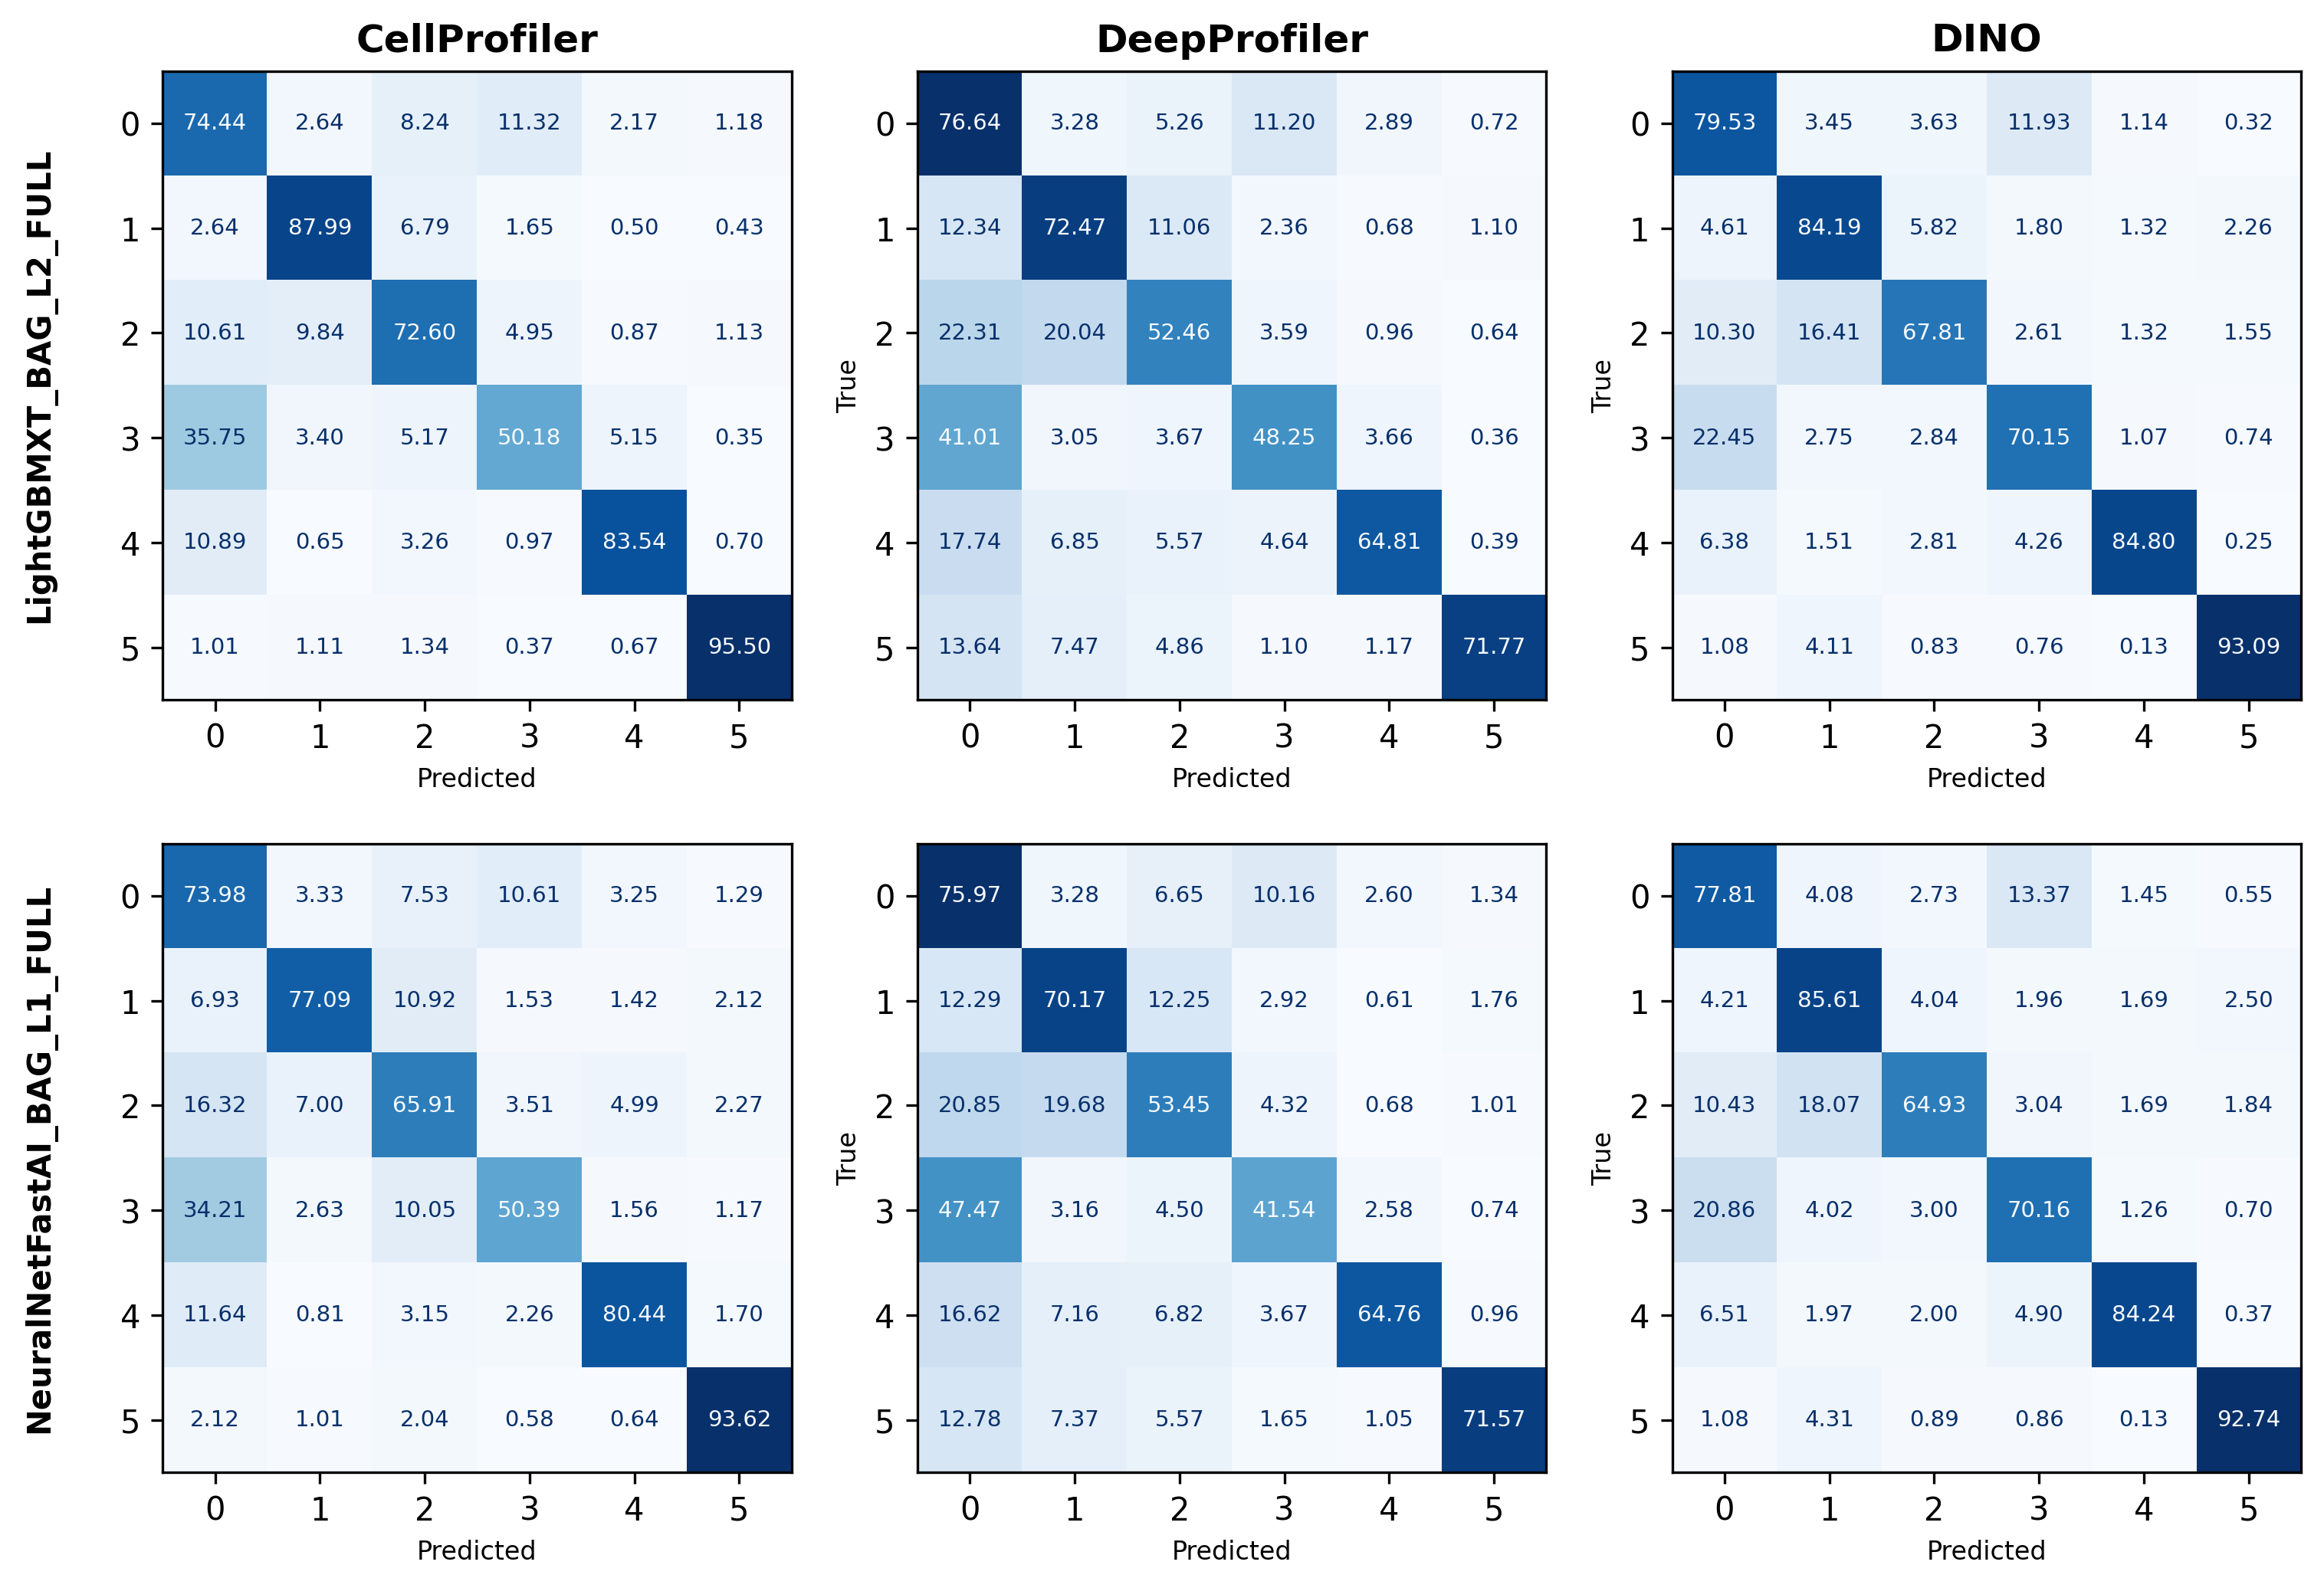

In [30]:
#plot_confusion_grid(conf_mats_single, model_labels, feature_labels, title="Single-cell predictions")
plot_confusion_grid(conf_mats_single, ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"], ["CellProfiler", "DeepProfiler", "DINO"], title="Majority vote predictions")


## Test set intersection

In [92]:
def synchronize_on_keys(dfs: list[pl.DataFrame], keys: list[str]) -> list[pl.DataFrame]:
    """
    Given a list of Polars DataFrames and a list of key columns,
    return a new list where each DataFrame has been inner-joined
    to the intersection of the keys across all frames.
    """
    # 1) get unique key‐tuples for each df
    uniques = [df.select(keys).unique() for df in dfs]
    # 2) intersect them
    common = uniques[0]
    for u in uniques[1:]:
        common = common.join(u, on=keys, how="inner")
    # 3) filter each original by joining back
    return [df.join(common, on=keys, how="inner") for df in dfs]

# usage:
joined_DINO_filt, joined_DP_filt, joined_CP_filt = synchronize_on_keys([joined_df_DINO,joined_df_DP,joined_df_CP], ["Metadata_Plate", "Metadata_Well", "Metadata_Site"])

/tmp/ipykernel_1140765/430928772.py:12: CategoricalRemappingWarning: Local categoricals have different encodings, expensive re-encoding is done to perform this merge operation. Consider using a StringCache or an Enum type if the categories are known in advance
  common = common.join(u, on=keys, how="inner")
/tmp/ipykernel_1140765/430928772.py:14: CategoricalRemappingWarning: Local categoricals have different encodings, expensive re-encoding is done to perform this merge operation. Consider using a StringCache or an Enum type if the categories are known in advance
  return [df.join(common, on=keys, how="inner") for df in dfs]


In [99]:
conf_mats_inter, model_labels, feature_labels_majority = generate_confusion_matrices(
    predictors=[predictor_CP, predictor_DP, predictor_DINO],
    datasets=[joined_CP_filt.to_pandas(), joined_DP_filt.to_pandas(), joined_DINO_filt.to_pandas()],
    models_list=["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"],
    metadata_feats_list=[meta_cp, meta_DP, meta_dino],  # One list per extractor!
    group_columns=["Metadata_Plate", "Metadata_Well", "Metadata_Site"],
    majority_vote=False
)

Evaluating LightGBMXT_BAG_L2_FULL
Evaluating LightGBMXT_BAG_L2_FULL
Evaluating LightGBMXT_BAG_L2_FULL
Evaluating NeuralNetFastAI_BAG_L1_FULL
Evaluating NeuralNetFastAI_BAG_L1_FULL
Evaluating NeuralNetFastAI_BAG_L1_FULL


IndexError: list index out of range

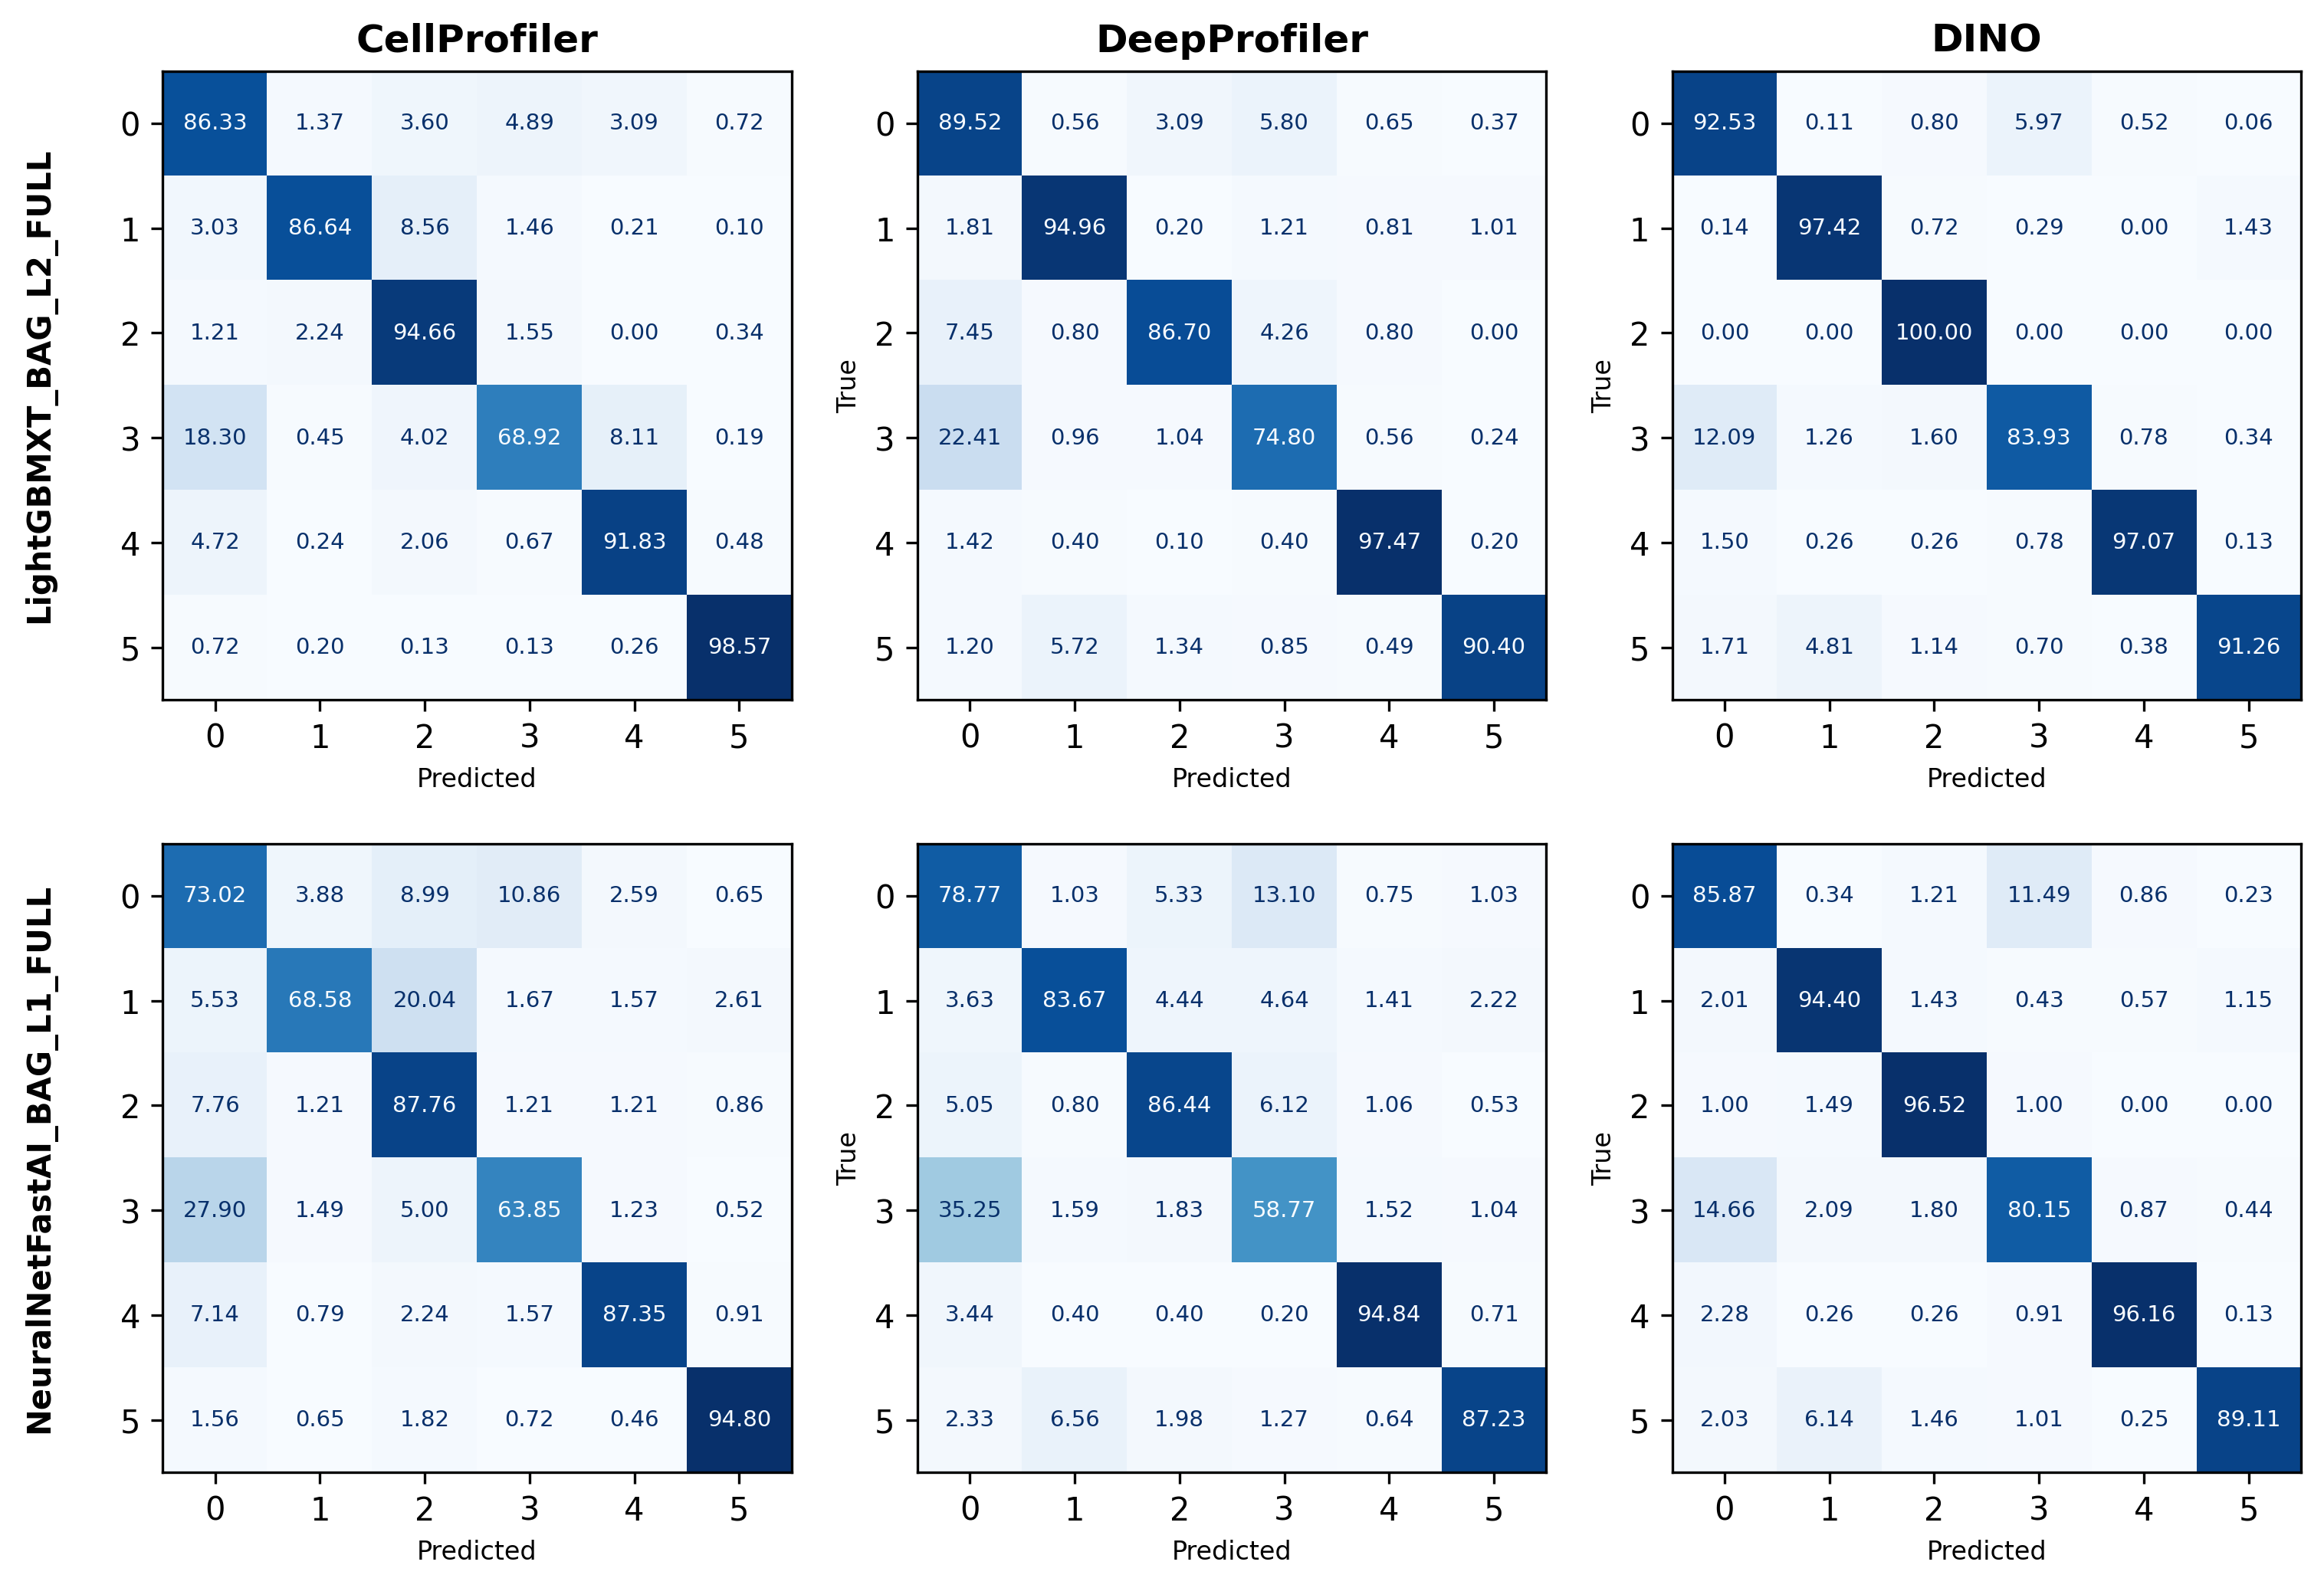

In [100]:
plot_confusion_grid(conf_mats_inter, ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"], ["CellProfiler", "DeepProfiler", "DINO"], title="Majority vote predictions")


In [ ]:
conf_mats_agg, model_labels, feature_labels_majority = generate_confusion_matrices_agg(
    predictors=[predictor_agg_CP, predictor_agg_DP, predictor_agg_DINO],
    datasets=[joined_CP_filt.group_by(["moa", "Metadata_Plate", "Metadata_Well", "Metadata_Site"]).agg().group_by("moa").count().to_pandas(), joined_DP_filt.group_by(["moa", "Metadata_Plate", "Metadata_Well", "Metadata_Site"]).agg().group_by("moa").count().to_pandas(), joined_DINO_filt.group_by(["moa", "label", "Metadata_Plate", "Metadata_Well", "Metadata_Site"]).agg().group_by("moa").count().to_pandas()],
    models_list=["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_r191_BAG_L1_FULL"],
    metadata_feats_list=[meta_cp, meta_DP, meta_dino],  # One list per extractor!
    group_columns=["Metadata_Plate", "Metadata_Well", "Metadata_Site"],
    majority_vote=False
)

plot_confusion_grid(conf_mats_agg, ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"], ["CellProfiler", "DeepProfiler", "DINO"], title="Majority vote predictions")

In [ ]:
joined_DINO_filt = joined_DINO_filt.with_columns([
    pl.col("moa")
      .cast(pl.Utf8)                  # 1) categorical → plain string
      .replace(string_to_int)         # 2) map each string → integer
      .cast(pl.Int32)                 # 3) make it a numeric type
      .alias("label")
])

joined_DINO_filt.group_by(["moa", "label", "Metadata_Plate", "Metadata_Well", "Metadata_Site"]).agg().group_by("moa").count()

Model: LightGBMXT_BAG_L2_FULL, Accuracy: 0.9174


,precision,recall,f1-score,support
0,0.843014,0.925330,0.882256,1741.000000
1,0.862770,0.974175,0.915094,697.000000
2,0.844538,1.000000,0.915718,402.000000
3,0.930571,0.839320,0.882593,2060.000000
4,0.979645,0.970722,0.975163,1537.000000
5,0.986311,0.912603,0.948026,1579.000000
accuracy,0.917415,0.917415,0.917415,0.917415
macro avg,0.907808,0.937025,0.919809,8016.000000
weighted avg,0.921734,0.917415,0.917646,8016.000000


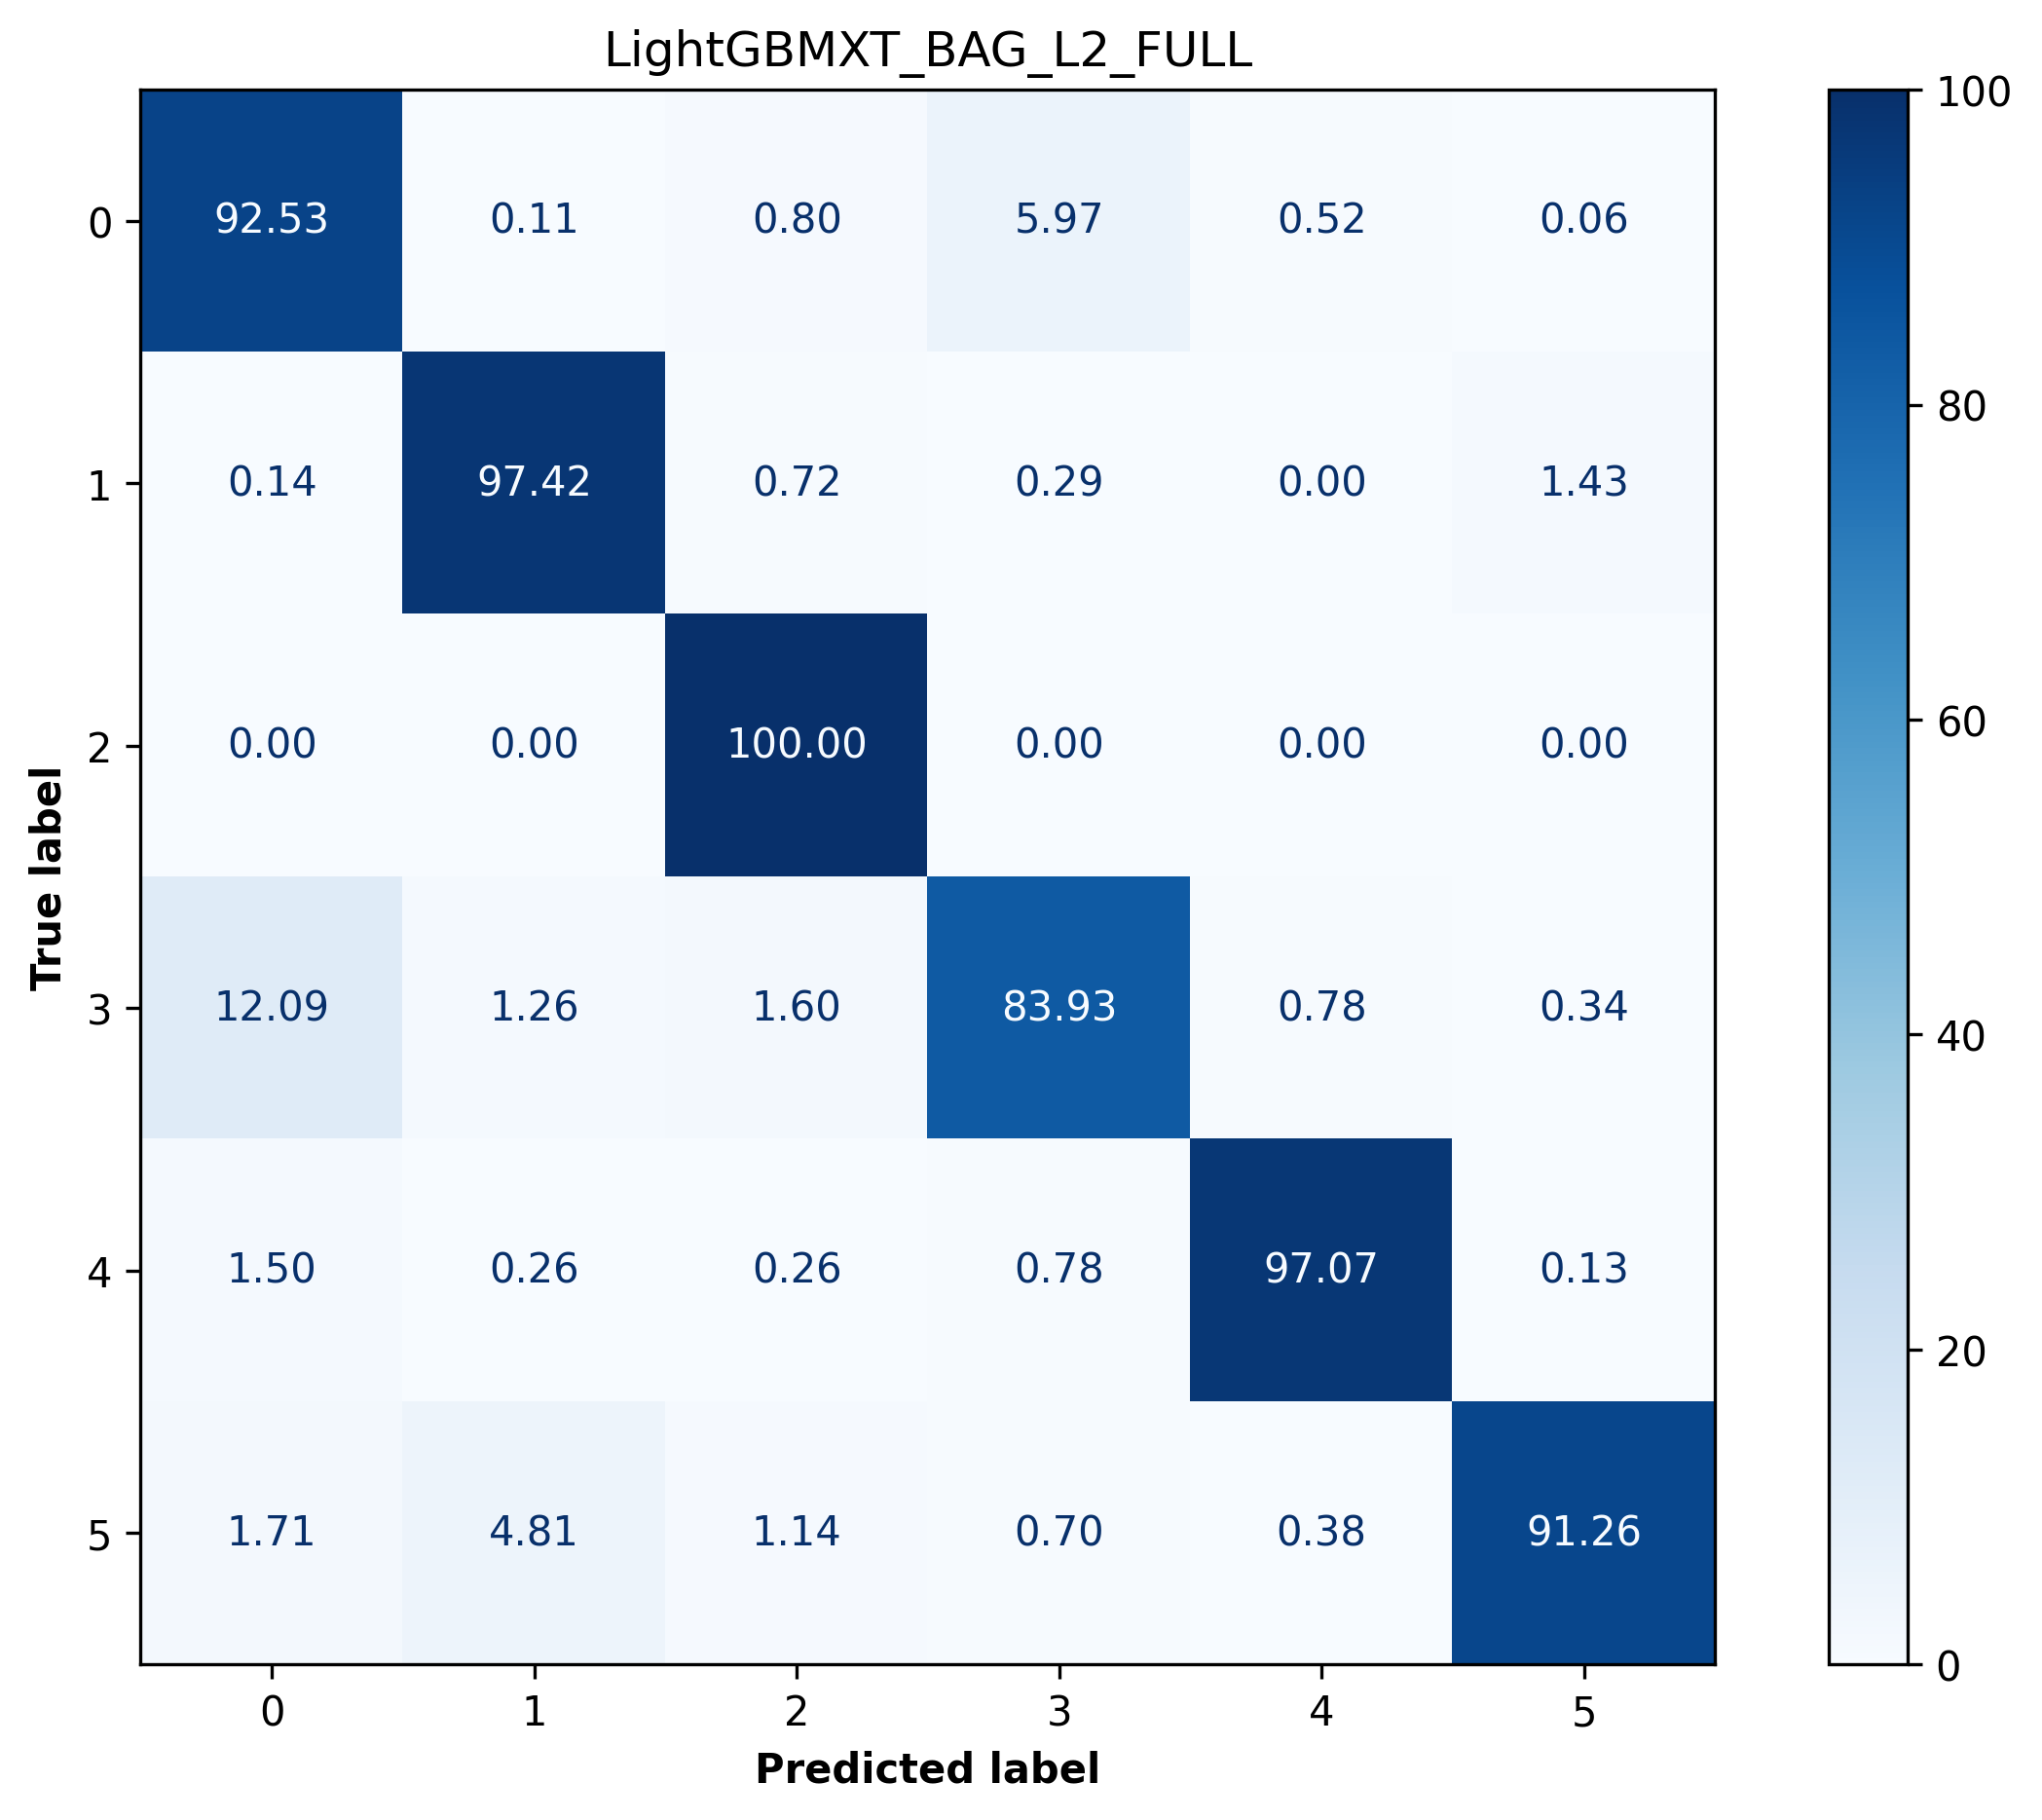

Model: NeuralNetFastAI_BAG_L1_FULL, Accuracy: 0.8829


,precision,recall,f1-score,support
0,0.794368,0.858702,0.825283,1741.000000
1,0.808354,0.944046,0.870946,697.000000
2,0.803313,0.965174,0.876836,402.000000
3,0.874470,0.801456,0.836373,2060.000000
4,0.973009,0.961614,0.967277,1537.000000
5,0.983916,0.891070,0.935194,1579.000000
accuracy,0.882859,0.882859,0.882859,0.882859
macro avg,0.872905,0.903677,0.885318,8016.000000
weighted avg,0.888208,0.882859,0.883565,8016.000000


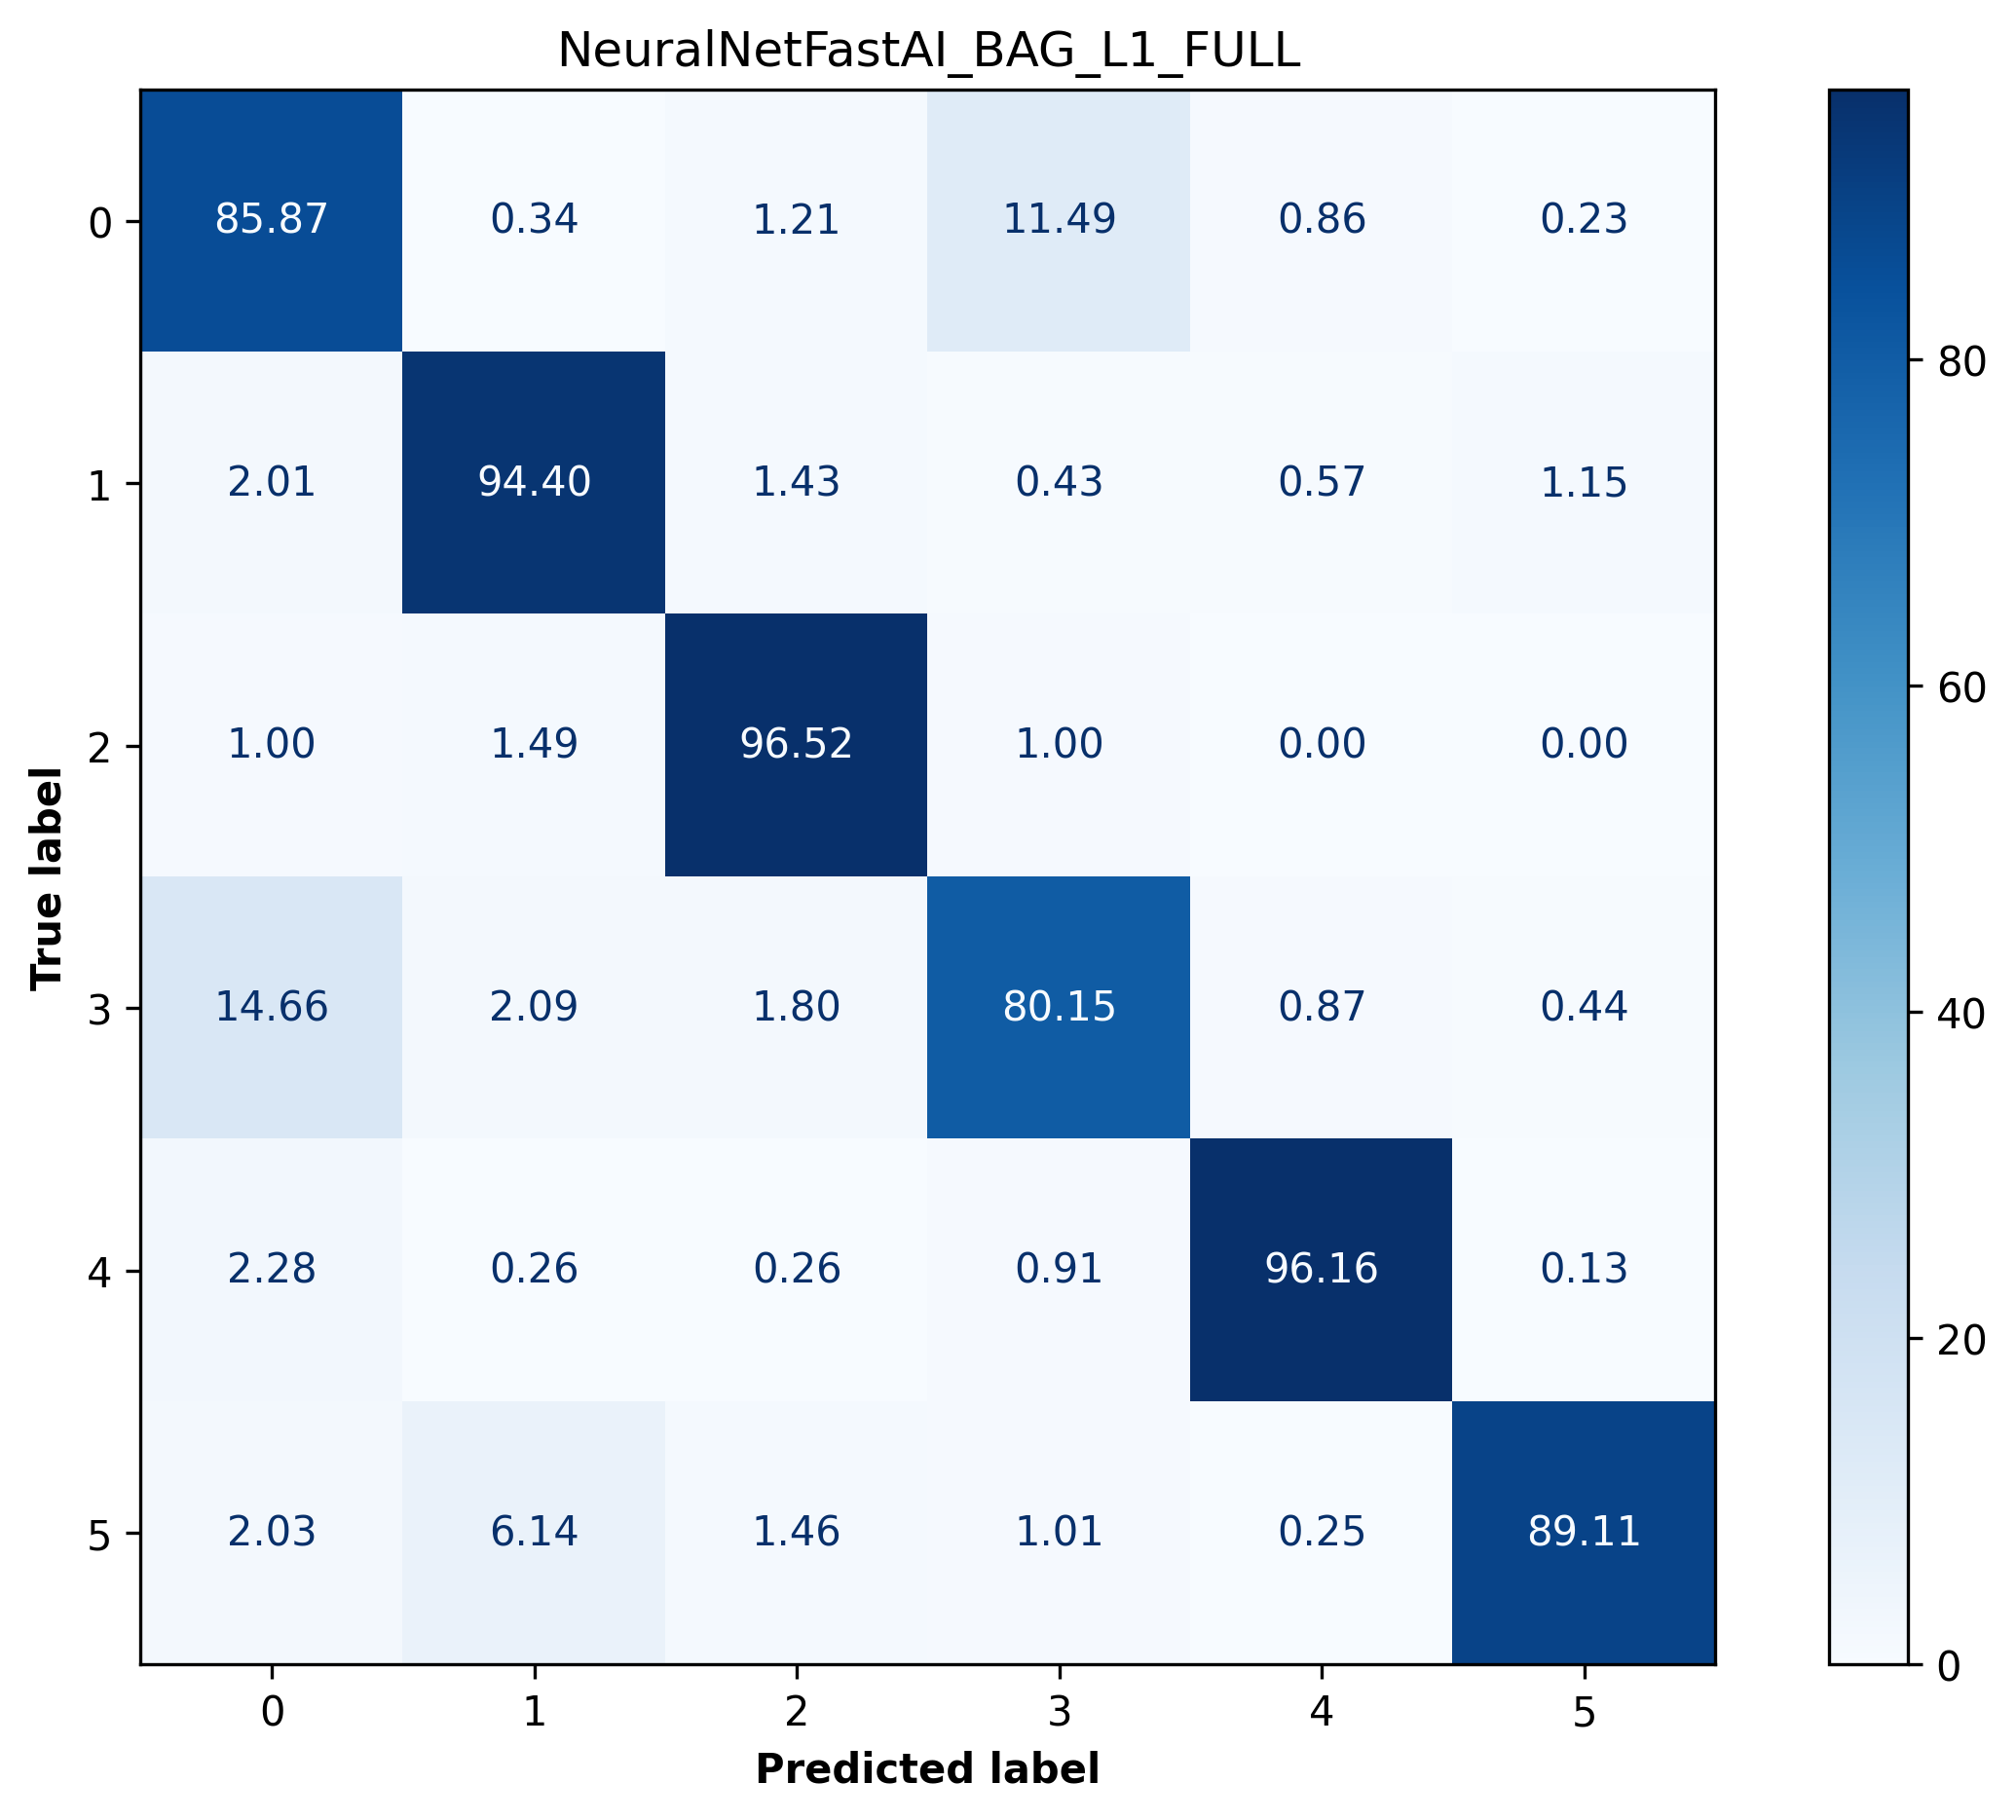

In [96]:
autogl_intersect_DINO = evaluate_models_and_display_summary(joined_DINO_filt.drop(["name_0", "Metadata_Well", "Metadata_cmpdName", "Metadata_cmpdConc", "epoch", "Metadata_Plate", "Nuclei_Location_Center_X", "Nuclei_Location_Center_Y", "Metadata_cmpdNameConc", "batch", "outliers", "filter", "umap_density_moa", "moa_right"]).to_pandas(), "moa", predictor= predictor_DINO, model_name = ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"])


Model: LightGBMXT_BAG_L2_FULL, Accuracy: 0.8814


,precision,recall,f1-score,support
0,0.732772,0.895229,0.805895,1069.00000
1,0.816291,0.949597,0.877912,496.00000
2,0.829517,0.867021,0.847854,376.00000
3,0.903661,0.748006,0.818499,1254.00000
4,0.971774,0.974722,0.973246,989.00000
5,0.989189,0.904023,0.944690,1417.00000
accuracy,0.881450,0.881450,0.881450,0.88145
macro avg,0.873867,0.889766,0.878016,5601.00000
weighted avg,0.891996,0.881450,0.882575,5601.00000


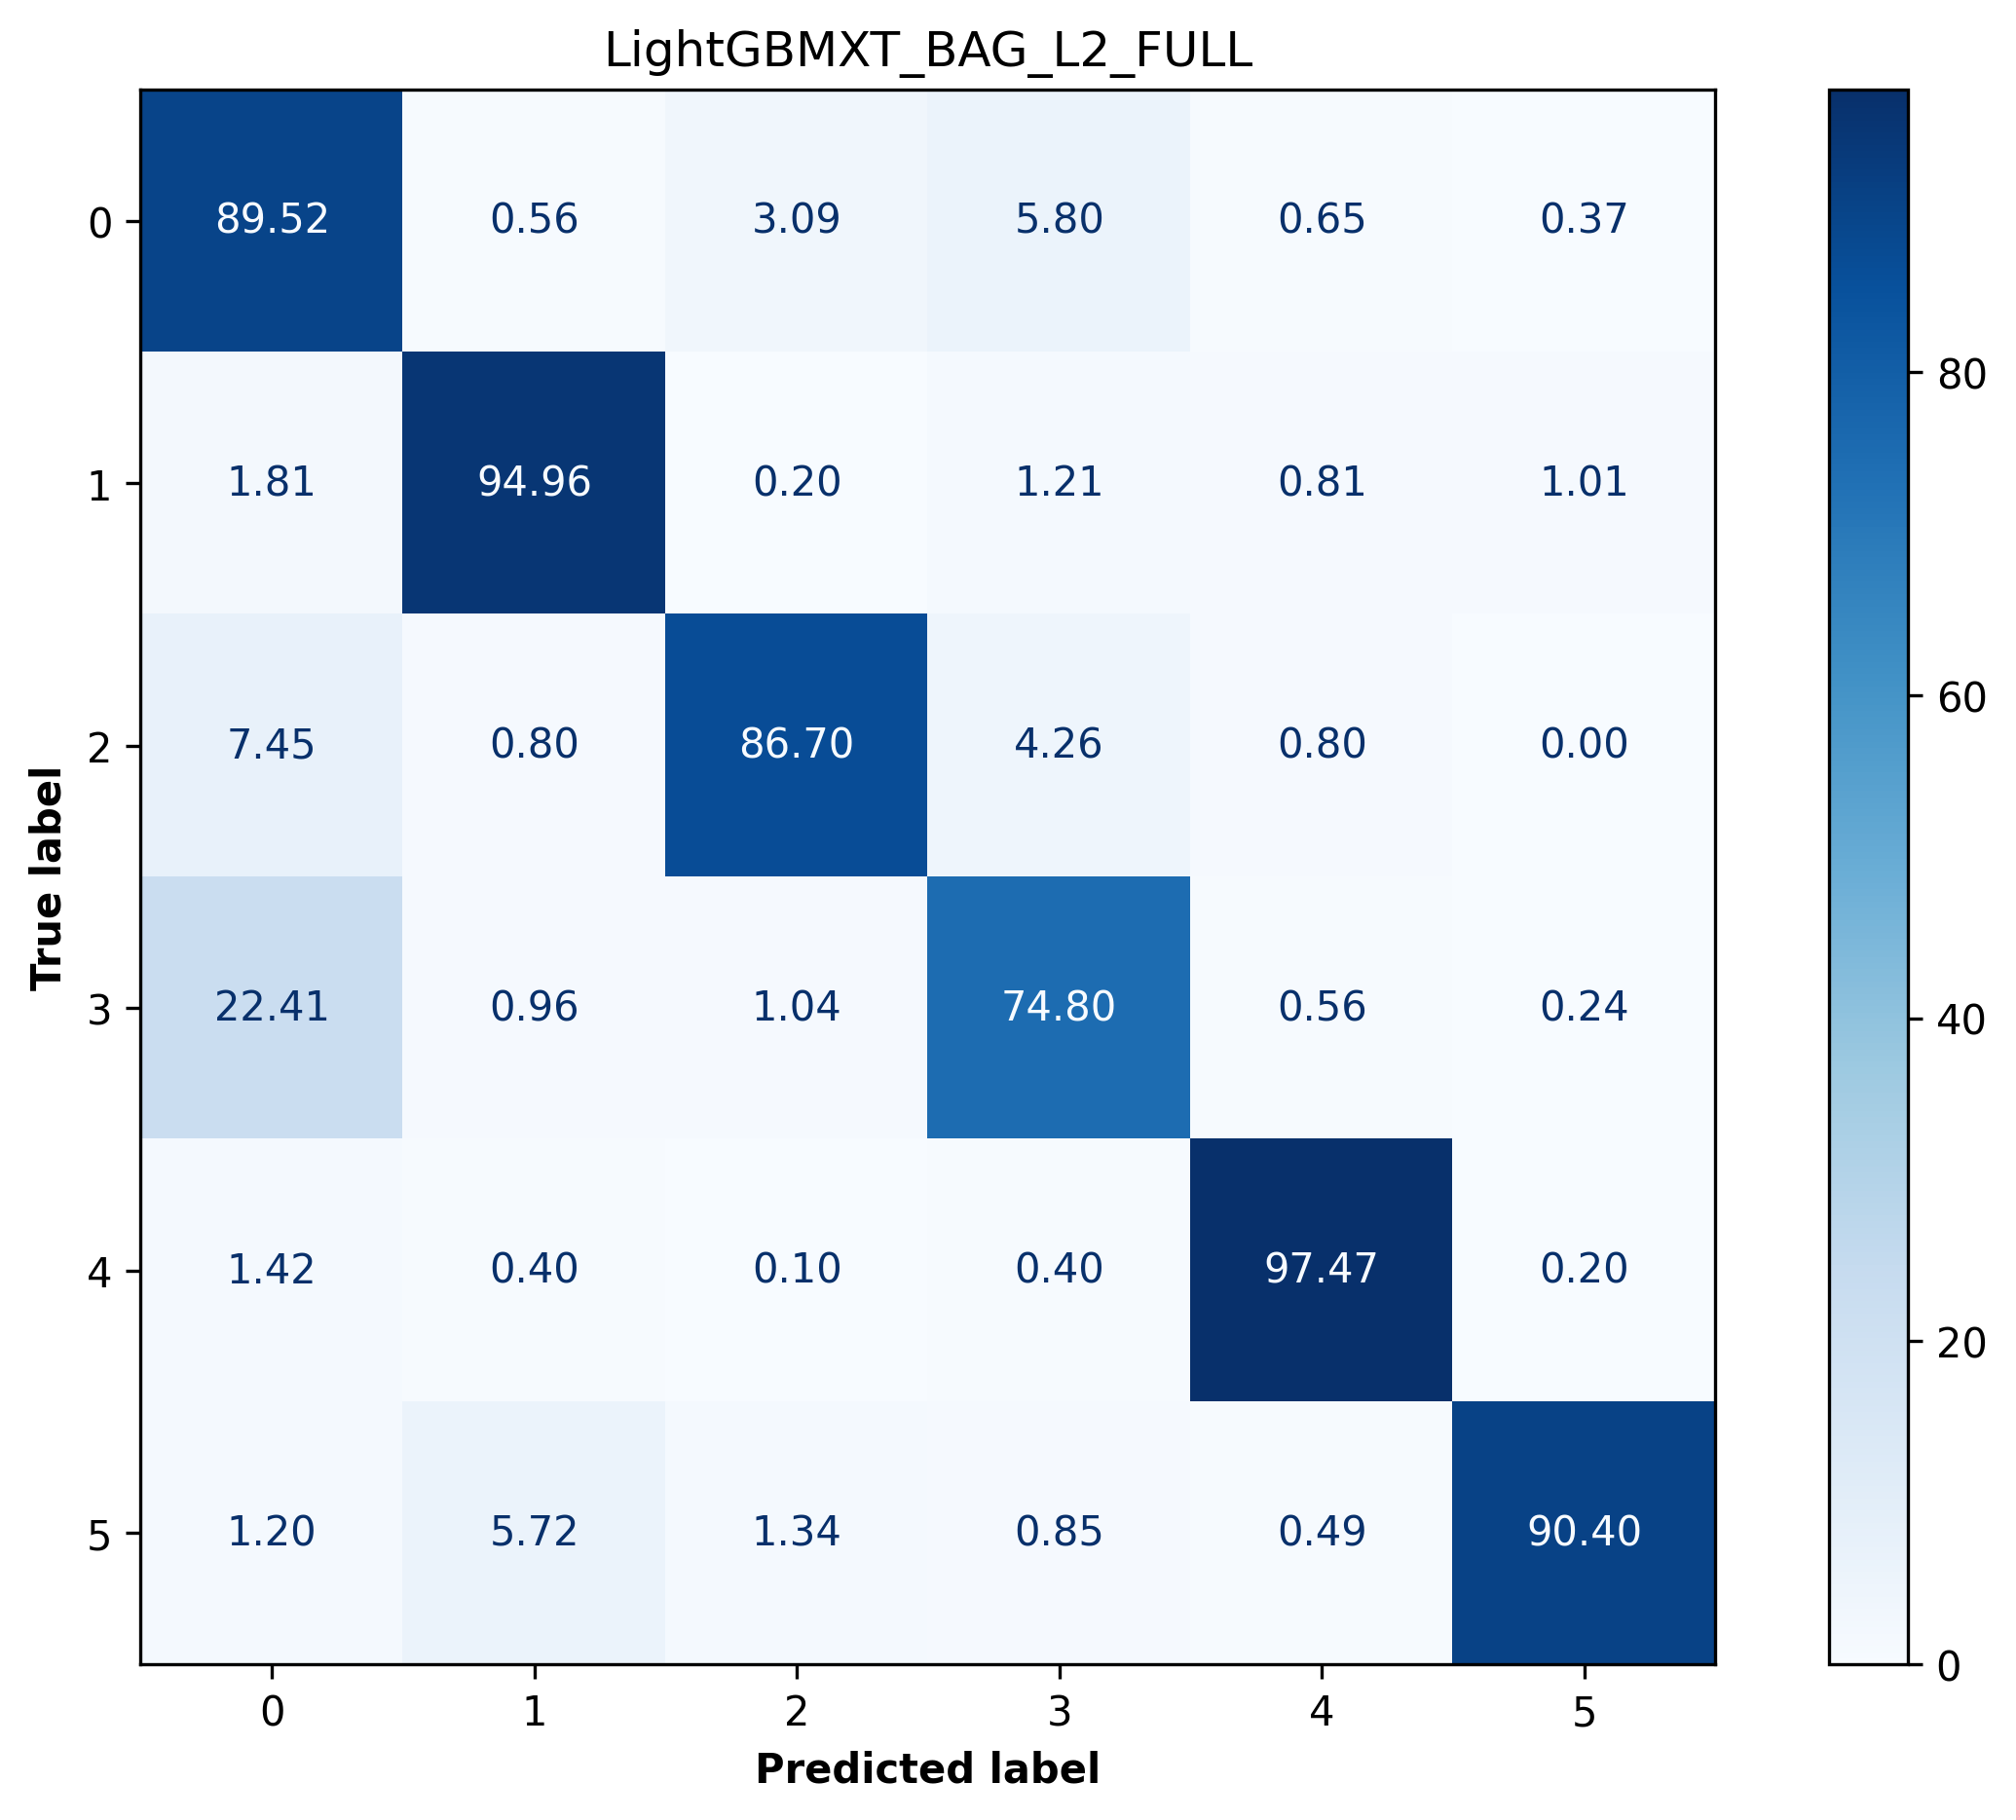

Model: NeuralNetFastAI_BAG_L1_FULL, Accuracy: 0.8022


,precision,recall,f1-score,support
0,0.606628,0.787652,0.685389,1069.000000
1,0.760073,0.836694,0.796545,496.000000
2,0.708061,0.864362,0.778443,376.000000
3,0.781548,0.587719,0.670915,1254.000000
4,0.952284,0.948433,0.950355,989.000000
5,0.965625,0.872265,0.916574,1417.000000
accuracy,0.802178,0.802178,0.802178,0.802178
macro avg,0.795703,0.816187,0.799703,5601.000000
weighted avg,0.818046,0.802178,0.803513,5601.000000


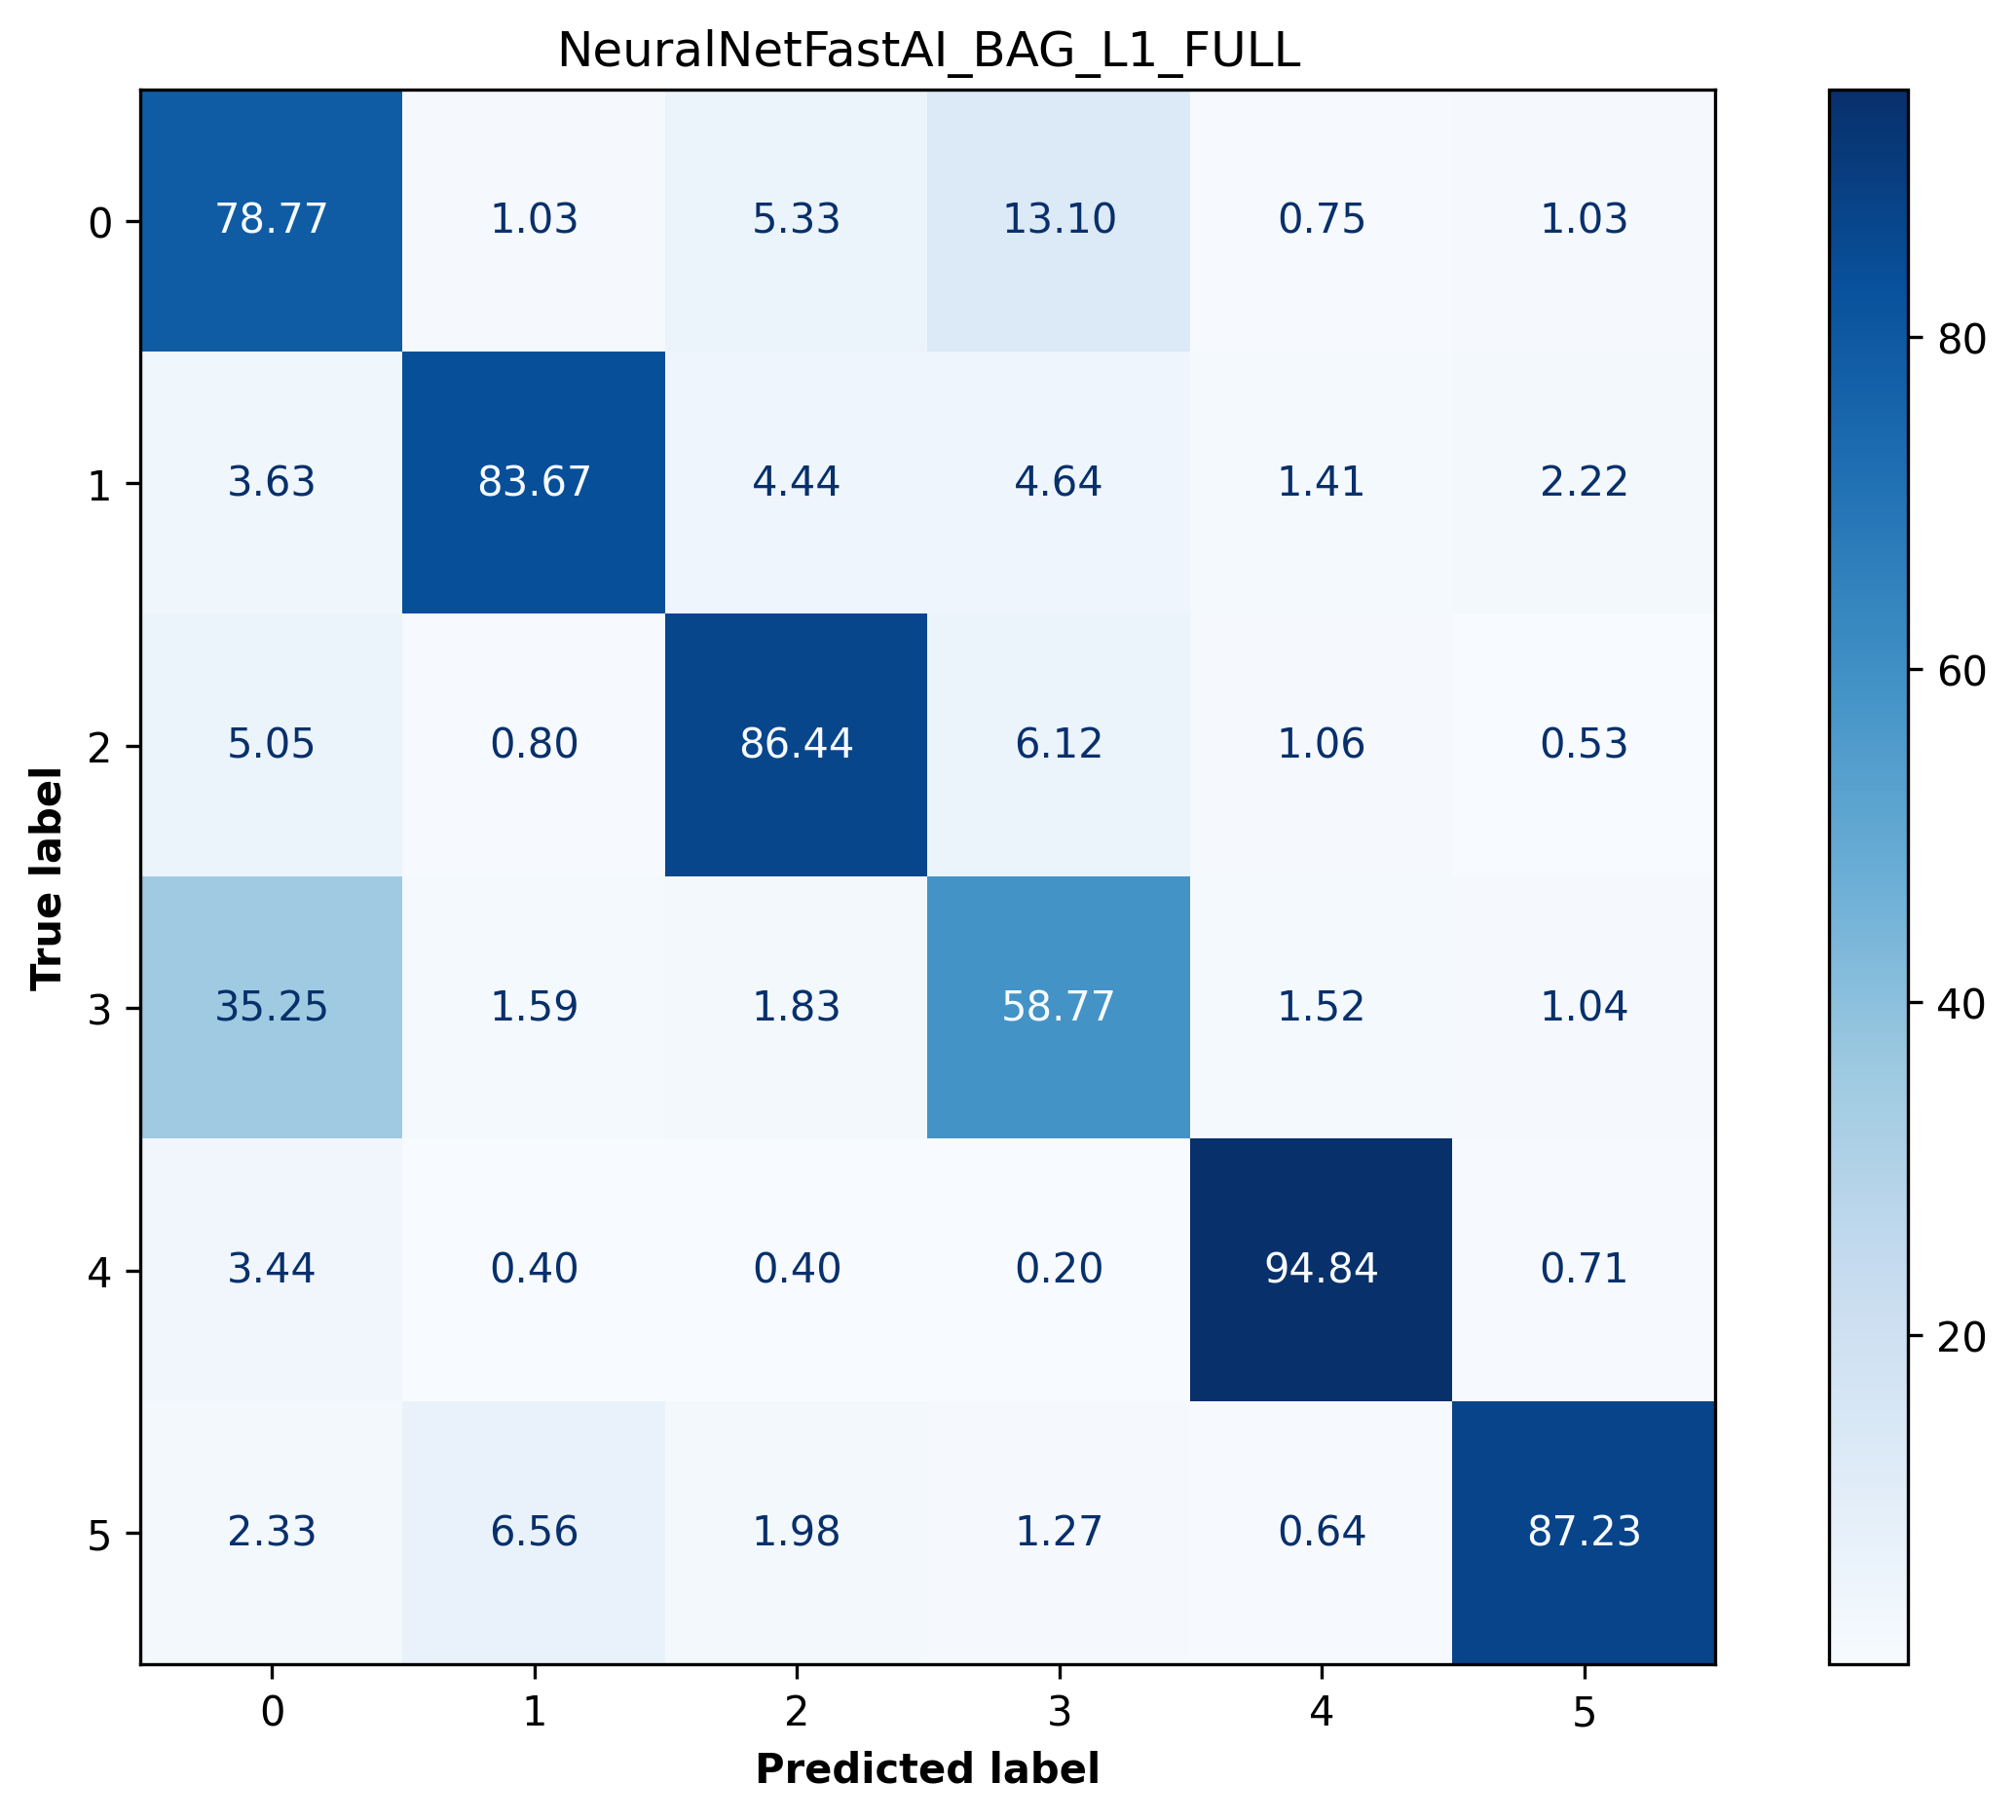

In [97]:
autogl_intersect_DP = evaluate_models_and_display_summary(joined_DP_filt.drop(['Metadata_Plate',
 'Metadata_Well',
 'Metadata_Site',
 'barcode',
 'layout_id',
 'batch_id',
 'compound_id',
 'Metadata_cmpdName',
 'Metadata_cmpdConc',
 'cell_line',
 'cells_per_well',
 'target',
 'Metadata_cmpdNameConc',
 'Nuclei_Location_Center_X',
 'Nuclei_Location_Center_Y',
 'Metadata_cmpdName_right',
 'compound_id_right',
 'Metadata_cmpdConc_right',
 'Intensity_MeanIntensity_illumCONC_nuclei',
 'Intensity_MeanIntensity_illumHOECHST_nuclei',
 'Intensity_IntegratedIntensity_illumHOECHST_nuclei',
 'Intensity_MeanIntensity_illumMITO_nuclei',
 'Intensity_MeanIntensity_illumPHAandWGA_nuclei',
 'Intensity_MeanIntensity_illumSYTO_nuclei',
 'Intensity_MeanIntensity_illumCONC_cells',
 'Intensity_MeanIntensity_illumHOECHST_cells',
 'Intensity_MeanIntensity_illumMITO_cells',
 'Intensity_MeanIntensity_illumPHAandWGA_cells',
 'Intensity_MeanIntensity_illumSYTO_cells',
 'AreaShape_Area_cells',
 'AreaShape_Area_nuclei',
 'label',
 'filter',
 'moa_right']).to_pandas(), "moa", predictor= predictor_DP, model_name = ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"])


Model: LightGBMXT_BAG_L2_FULL, Accuracy: 0.8714


,precision,recall,f1-score,support
0,0.746733,0.863309,0.800801,1390.000000
1,0.947489,0.866388,0.905125,958.000000
2,0.704750,0.946552,0.807947,580.000000
3,0.910806,0.689163,0.784632,1541.000000
4,0.897102,0.918281,0.907568,1652.000000
5,0.984405,0.985686,0.985046,1537.000000
accuracy,0.871376,0.871376,0.871376,0.871376
macro avg,0.865214,0.878230,0.865187,7658.000000
weighted avg,0.881823,0.871376,0.871150,7658.000000


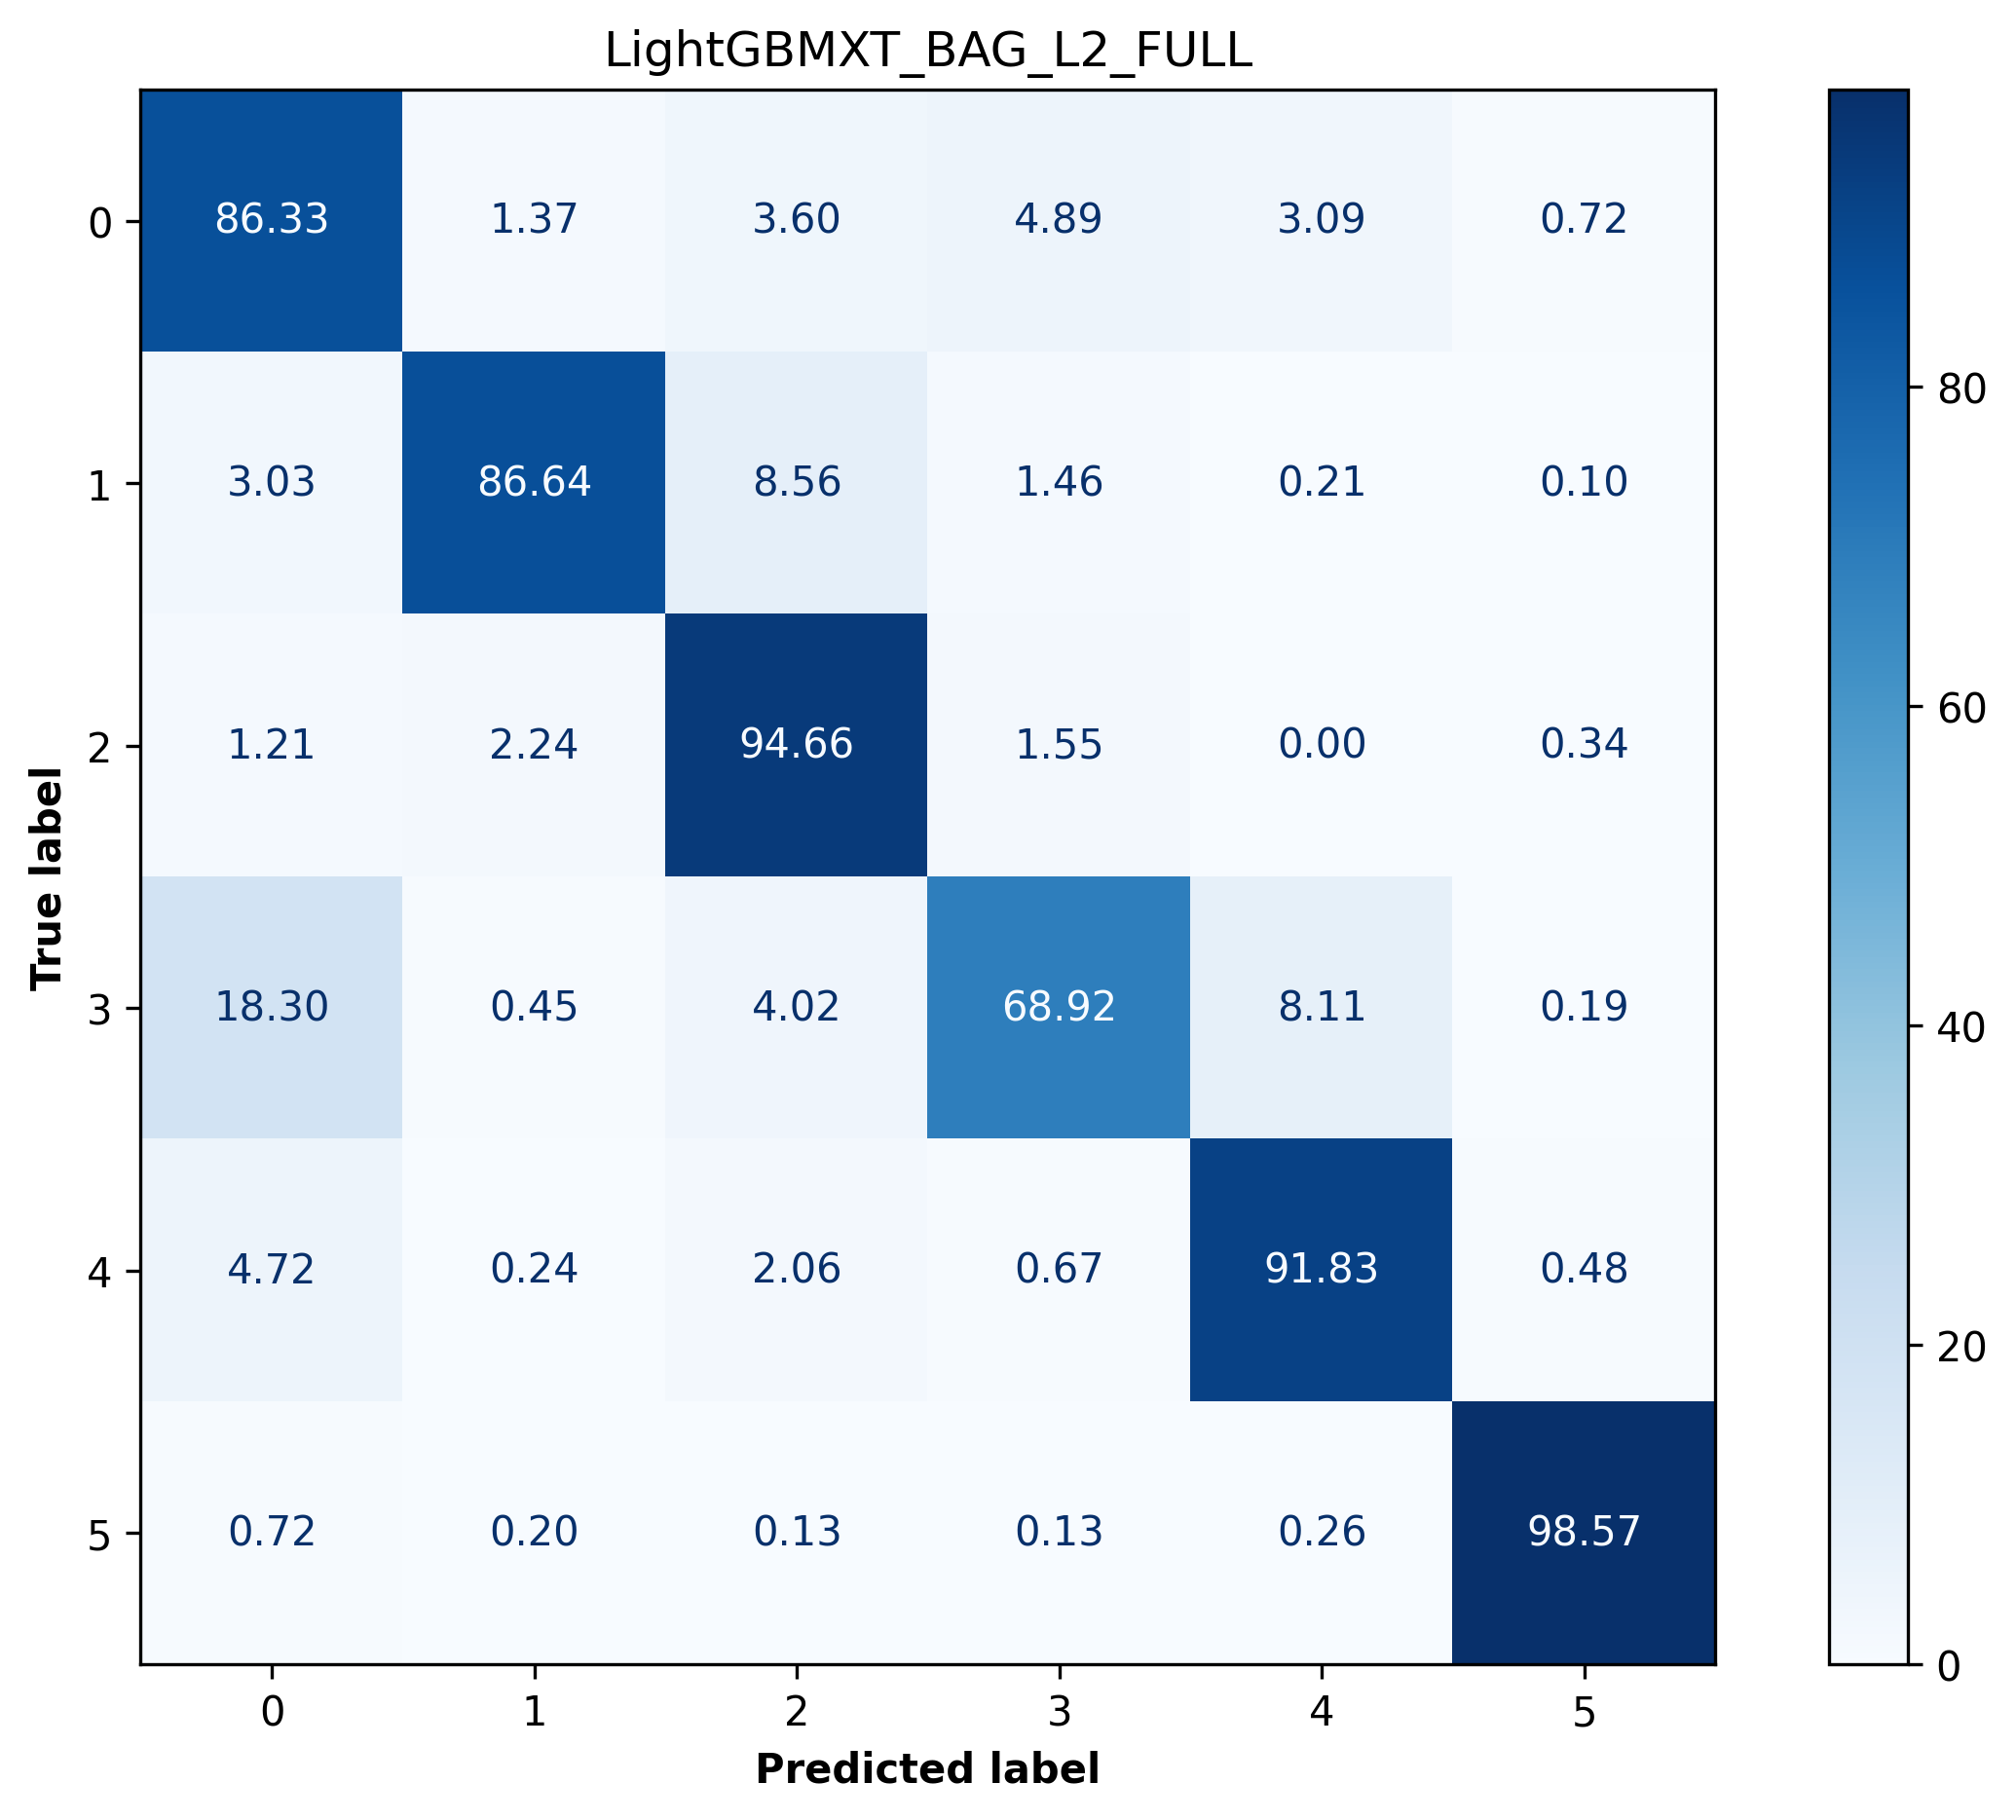

Model: NeuralNetFastAI_BAG_L1_FULL, Accuracy: 0.7920


,precision,recall,f1-score,support
0,0.602374,0.730216,0.660163,1390.000000
1,0.859948,0.685804,0.763066,958.000000
2,0.525826,0.877586,0.657623,580.000000
3,0.823431,0.638546,0.719298,1541.000000
4,0.944990,0.873487,0.907833,1652.000000
5,0.959184,0.947951,0.953534,1537.000000
accuracy,0.791982,0.791982,0.791982,0.791982
macro avg,0.785959,0.792265,0.776919,7658.000000
weighted avg,0.818805,0.791982,0.797052,7658.000000


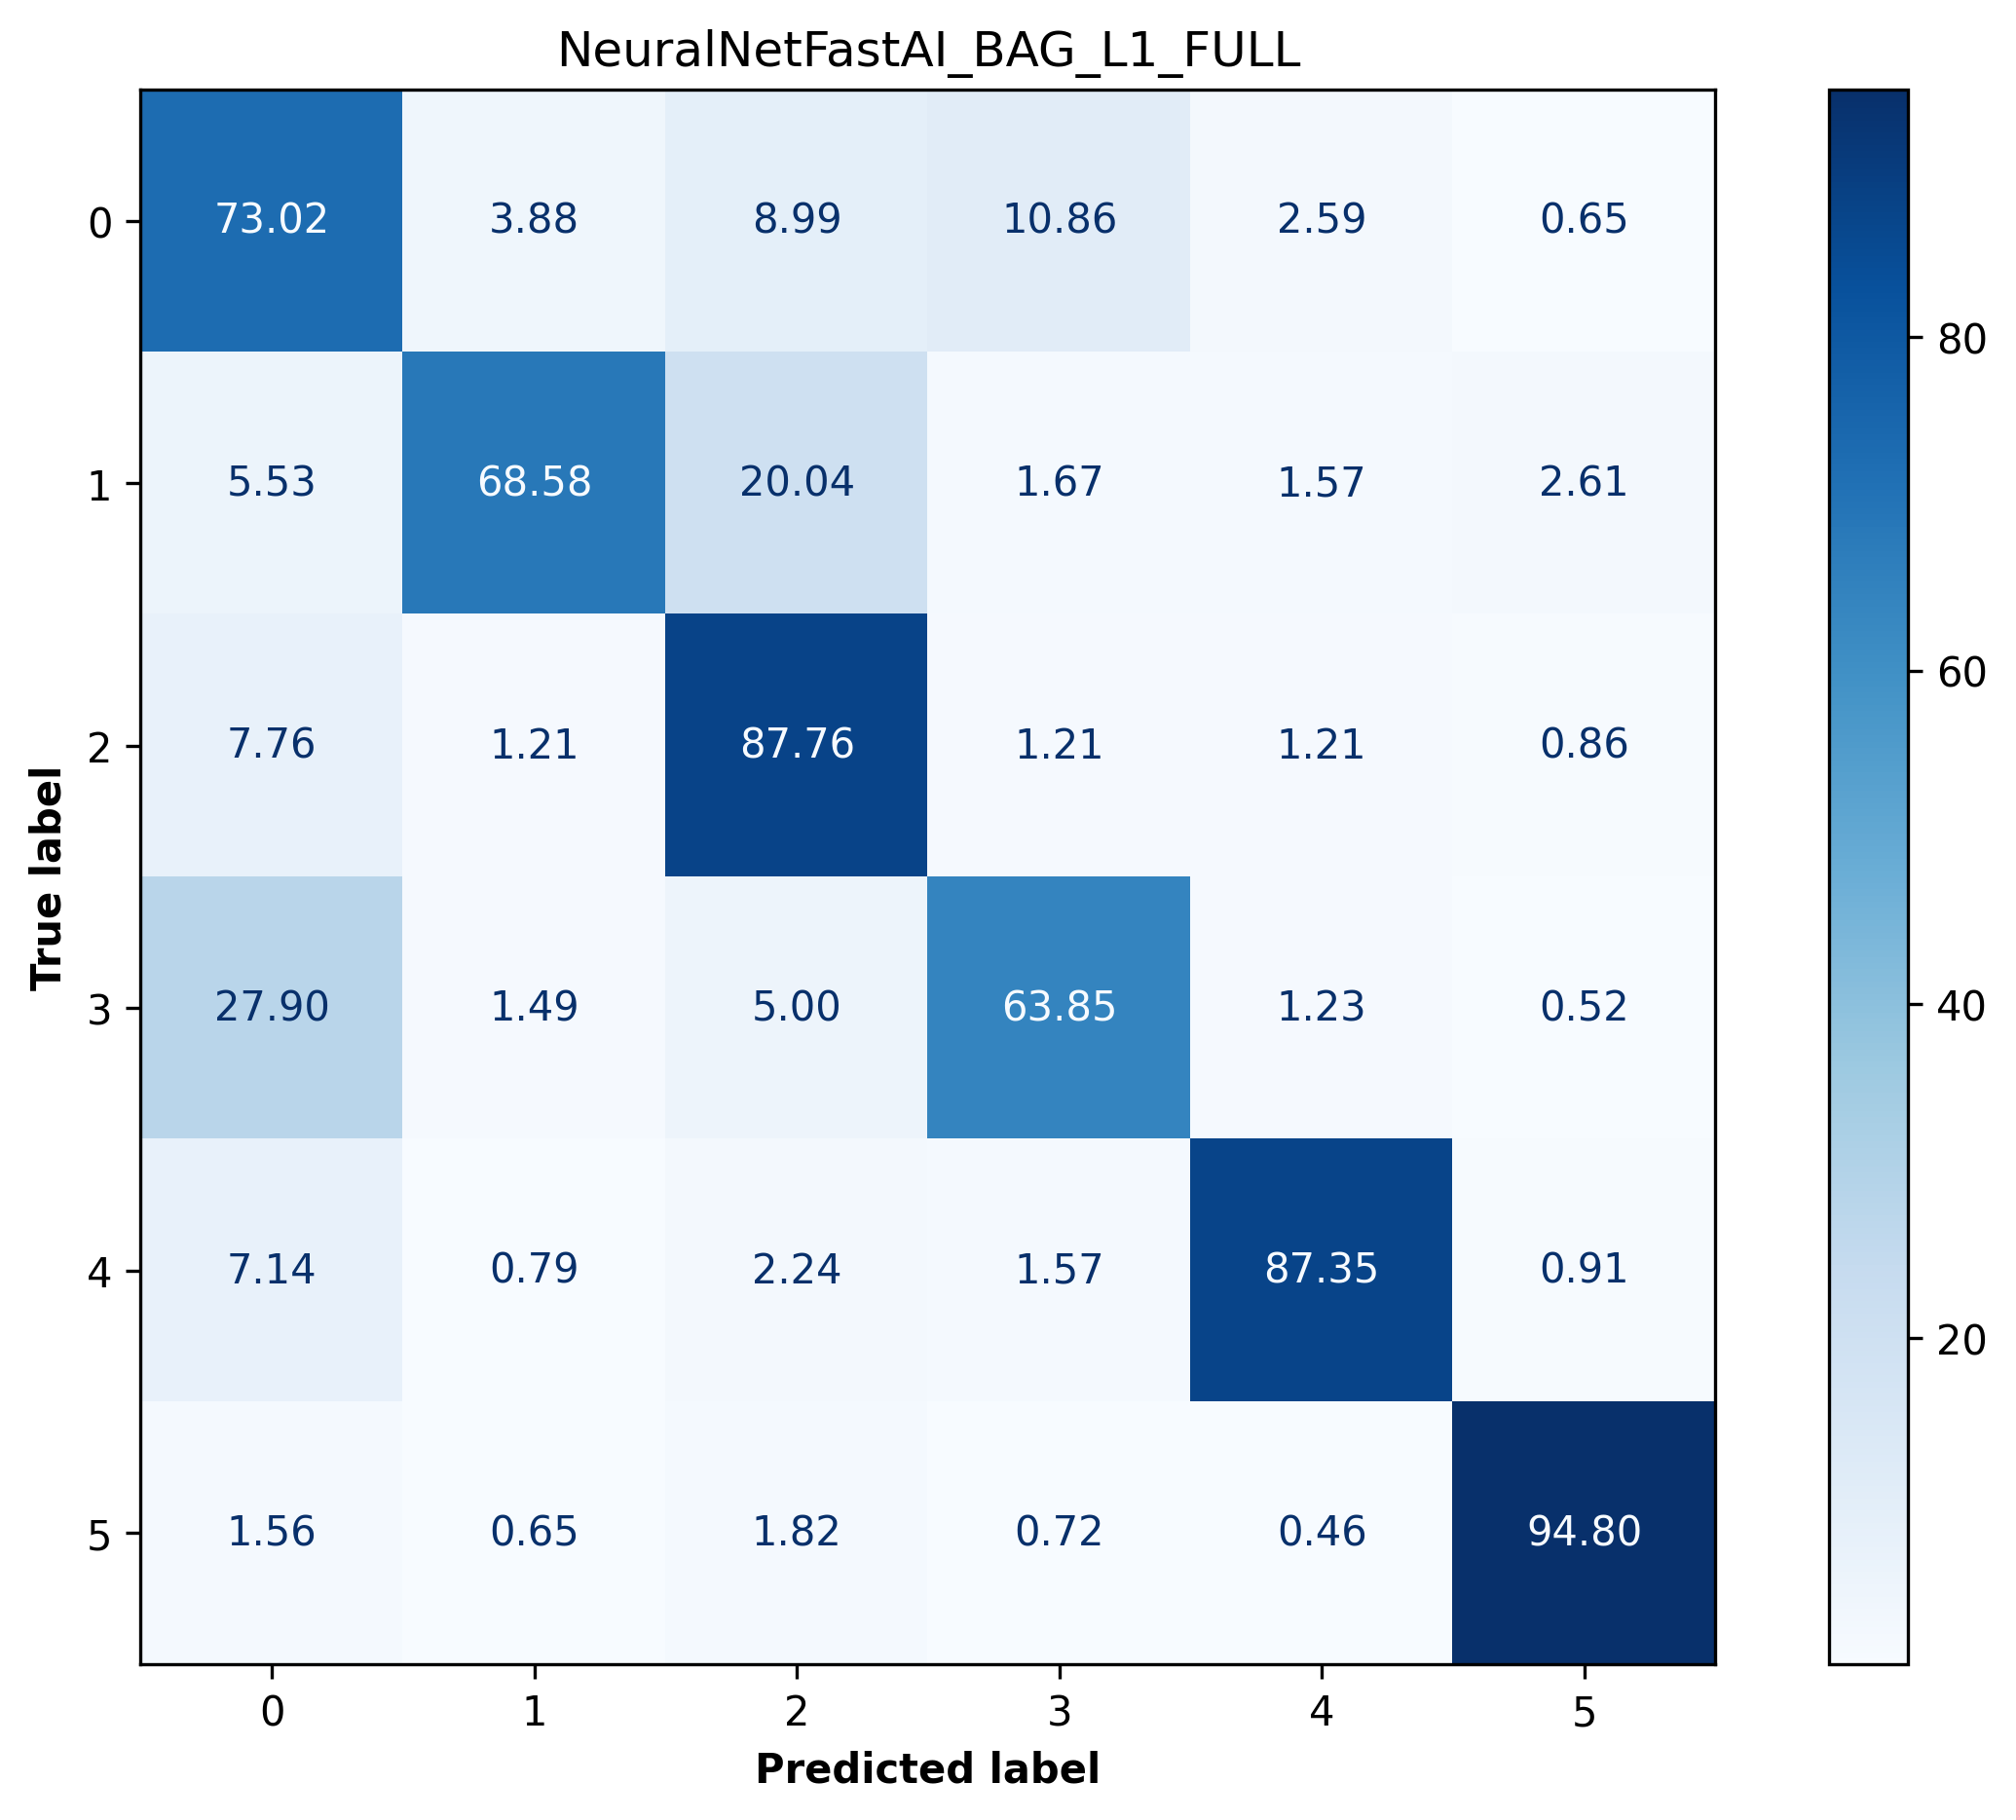

In [98]:
autogl_intersect_CP = evaluate_models_and_display_summary(joined_CP_filt.drop(['Metadata_cmpdNameConc',
 'Metadata_Plate',
 'Metadata_cmpdName',
 'Metadata_Well',
 'Metadata_Site',
 'Metadata_cmpdConc',
 'label',
 'moa_right']).to_pandas(), "moa", predictor= predictor_CP, model_name = ["LightGBMXT_BAG_L2_FULL", "NeuralNetFastAI_BAG_L1_FULL"])
